# 05 — Modelling dan Perkiraan Permintaan
## Ride-Hailing Demand & Operational Analytics

**Sumber:** `output/final/hourly_demand_2024_2026.parquet`
**Prasyarat:** notebook 04 Business Analytics selesai

---

### Apa yang dihasilkan notebook ini

1. **Perkiraan permintaan 1–7 Juni 2026**, untuk setiap zona × provider × jam, dengan tiga angka:

| Angka | Artinya |
|---|---|
| **Batas bawah** | Skenario sepi. Permintaan diperkirakan lebih rendah dari angka ini hanya 1 dari 10 kali |
| **Perkiraan** | Angka paling mungkin, dipakai sebagai dasar perencanaan |
| **Batas atas** | Skenario ramai. Permintaan diperkirakan lebih tinggi dari angka ini hanya 1 dari 10 kali |

   Jadi 8 dari 10 kali, permintaan nyata diperkirakan berada di antara batas bawah dan batas atas.

2. **Tabel perkiraan** untuk seluruh kota per hari, per zona per hari, dan per seri per jam.

3. **Bukti bahwa perkiraan itu dapat dipercaya**: enam kandidat model dibandingkan pada tiga periode validasi, lalu model terpilih dinilai pada data uji dengan cara yang sama seperti saat dipakai sungguhan — dilatih ulang setiap bulan.

### Alur

| Tahap | Isi |
|---|---|
| Step 1–4 | Data, seri, grid jam lengkap, fitur |
| Step 5 | Membagi periode |
| Step 5B | ACF dan PACF: membuktikan lag yang dipakai |
| Step 6 | Pembanding sederhana |
| Step 7 | Enam kandidat model, dinilai pada tiga periode validasi |
| Step 8 | Model terpilih dinilai pada periode uji, dilatih ulang setiap bulan |
| Step 8B | Apakah sisa kesalahan masih berpola |
| Step 9–9B | Batas bawah dan atas: dikalibrasi, diuji, dan dikalibrasi ulang |
| Step 10 | Perkiraan 1–7 Juni 2026 dan tabelnya |
| Step 11 | Menyimpan hasil |
| Pengembangan lanjutan | Model jarak 14 dan 28 hari, perkiraan 1–28 Juni 2026 |
| Step 12 | Ringkasan |

### Pembagian periode

| Periode | Rentang | Dipakai untuk |
|---|---|---|
| Latih | Februari 2024 – Maret 2025, lalu bertambah | Melatih kandidat model |
| Validasi | Tiga periode: April–Juni, Juli–September, Oktober–Desember 2025 | **Memilih** model dan jumlah iterasi; mengkalibrasi batas bawah dan atas |
| Uji | Januari – Mei 2026 | **Menilai** sekali, dengan model dilatih ulang setiap awal bulan |
| Perkiraan | 1 – 7 Juni 2026 | Hasil akhir, model dilatih ulang pada seluruh data |

### Keputusan jarak perkiraan

Perkiraan dibuat **hingga 7 hari ke depan**. Seluruh fitur hanya memakai data paling baru 168 jam sebelum jam yang diperkirakan, sehingga perkiraan 1–7 Juni hanya memakai data sampai 31 Mei.

### Ukuran keberhasilan

Model berhasil bila pada periode uji kesalahannya lebih kecil dari **pembanding sederhana terbaik**, di seluruh seri dan di setiap kelompok seri, dan batas bawah–atas benar-benar mengapit sekitar 80% kenyataan.

---

# SETUP

In [1]:
# ============================================================
# SETUP
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import gc
import time
import duckdb
import lightgbm as lgb
try:
    import xgboost as xgb
    ADA_XGB = True
except ImportError:
    ADA_XGB = False
    print("XGBoost belum terpasang. Jalankan: pip install xgboost — kandidat XGBoost dilewati.")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- Lokasi file ----------
PROJECT_ROOT = Path("/Users/auliaaorama/Project/Ride hailing")
SUMBER       = PROJECT_ROOT / "output" / "final" / "hourly_demand_2024_2026.parquet"
FOLDER_MODEL = PROJECT_ROOT / "output" / "model"
FOLDER_MODEL.mkdir(parents=True, exist_ok=True)
FITUR_PATH   = FOLDER_MODEL / "fitur.parquet"
SERI_PATH    = FOLDER_MODEL / "seri_info.parquet"

# ---------- Nama kolom di file sumber ----------
COL = {"jam": "request_hour", "provider": "provider", "zona": "pickup_location_id", "demand": "demand"}

# ---------- Periode ----------
AWAL_DATA       = "2024-01-01 00:00:00"
AKHIR_DATA      = "2026-05-31 23:00:00"
LATIH_MULAI     = "2024-02-01 00:00:00"
VAL_MULAI       = "2025-10-01 00:00:00"
TEST_MULAI      = "2026-01-01 00:00:00"
PERKIRAAN_MULAI = "2026-06-01 00:00:00"
PERKIRAAN_AKHIR = "2026-06-07 23:00:00"

# Tiga periode validasi. Untuk setiap periode, model dilatih pada semua data sebelumnya.
LIPATAN = [("Apr–Jun 2025", "2025-04-01", "2025-07-01"),
           ("Jul–Sep 2025", "2025-07-01", "2025-10-01"),
           ("Okt–Des 2025", "2025-10-01", "2026-01-01")]

TGL_SEMI = ["2024-03-10", "2025-03-09", "2026-03-08"]   # jam 02:00 dilompati, waktu lokal New York

# ---------- Keputusan ----------
CAKUPAN     = 0.95        # porsi permintaan yang dimodelkan
TOTAL_BA    = 589_055_372
BATAS_POIN  = 1.0         # selisih minimal per 100 perjalanan agar disebut berbeda (penilaian)
BATAS_SETARA = 0.1        # selisih WMAPE di bawah ini: kandidat dianggap setara (pemilihan model)
BATAS_BIAS   = 3.0        # kandidat dengan bias melebihi ±3% tidak boleh dipilih
Q_BAWAH, Q_ATAS = 0.10, 0.90   # batas bawah dan atas: 8 dari 10 kali kenyataan di antaranya

# ---------- DuckDB di memori, dengan batas memori ----------
FOLDER_TMP = FOLDER_MODEL / "tmp"
FOLDER_TMP.mkdir(exist_ok=True)
con = duckdb.connect(config={"memory_limit": "3GB", "temp_directory": str(FOLDER_TMP)})
con.execute("SET TimeZone = 'UTC'")            # nilai waktu dibaca apa adanya
con.execute("SET enable_progress_bar = false")

print("Sumber ada :", SUMBER.exists())
print("DuckDB", duckdb.__version__, "| LightGBM", lgb.__version__, "| XGBoost", xgb.__version__ if ADA_XGB else "tidak ada")

Sumber ada : True
DuckDB 1.5.5 | LightGBM 4.6.0 | XGBoost 3.1.3


In [2]:
# ============================================================
# STYLE GRAFIK
# ============================================================
%config InlineBackend.figure_format = "retina"

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

C = {"primary": "#1F4E79", "secondary": "#E07B39", "accent": "#2E8B74", "muted": "#9AA5B1",
     "alert": "#C0392B", "grid": "#E4E7EB", "text": "#2C3A47", "bg": "#FFFFFF", "band": "#AFC6DD"}

mpl.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["bg"], "axes.edgecolor": C["muted"],
    "axes.linewidth": 0.8, "axes.labelcolor": C["text"], "axes.titlesize": 13,
    "axes.titleweight": "semibold", "axes.titlecolor": C["text"], "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": C["grid"], "grid.linewidth": 0.8, "xtick.color": C["text"], "ytick.color": C["text"],
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.0, "font.size": 10, "figure.dpi": 110, "savefig.dpi": 200,
    "savefig.bbox": "tight",
})
RIBU = FuncFormatter(lambda v, p: f"{v / 1000:,.0f} rb" if abs(v) >= 1000 else f"{v:,.0f}")


def clean_axes(ax, x_grid=False):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", visible=True)
    ax.grid(axis="x", visible=x_grid)
    return ax


def titled(ax, title, sub=None):
    ax.set_title(title, loc="left", pad=30 if sub else 14)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=9.5, color=C["muted"], va="bottom")
    return ax


def label_ujung(ax, x, nilai_nama_warna, fmt="{:.1f}", jarak_rel=0.06):
    # Label di ujung garis, digeser bila berdekatan agar tidak bertumpuk
    lo, hi = ax.get_ylim()
    jarak = (hi - lo) * jarak_rel
    posisi = []
    for v, n, w in sorted(nilai_nama_warna):
        yt = v if not posisi else max(v, posisi[-1] + jarak)
        posisi.append(yt)
        ax.annotate(f" {n} {fmt.format(v)}", xy=(x, yt), va="center", fontsize=9.5,
                    color=w, fontweight="semibold", annotation_clip=False)

print("Style grafik siap.")

Style grafik siap.


In [3]:
# ============================================================
# UKURAN KESALAHAN
# ============================================================
JAM_SIBUK = []   # diisi di Step 6 dari data latih


def ukur(y, p, jam_hari=None):
    # Beberapa ukuran sekaligus. Kurang tebak + lebih tebak = WMAPE.
    y, p = np.asarray(y, dtype=float), np.asarray(p, dtype=float)
    e = p - y
    hasil = {
        "WMAPE": np.abs(e).sum() / y.sum() * 100,
        "WMAPE jam sibuk": np.nan,
        "Kurang tebak": np.clip(-e, 0, None).sum() / y.sum() * 100,
        "Lebih tebak": np.clip(e, 0, None).sum() / y.sum() * 100,
        "Bias %": (p.sum() / y.sum() - 1) * 100,
        "RMSE": np.sqrt((e ** 2).mean()),
        "MAE": np.abs(e).mean(),
    }
    if jam_hari is not None and len(JAM_SIBUK):
        m = np.isin(np.asarray(jam_hari), JAM_SIBUK)
        hasil["WMAPE jam sibuk"] = np.abs(e[m]).sum() / y[m].sum() * 100
    return hasil


def tabel_ukur(df, tebakan):
    # Satu baris per cara menebak, satu kolom per ukuran.
    return pd.DataFrame({nama: ukur(df["demand"], df[k], df["jam_hari"]) for k, nama in tebakan.items()}).T


def wmape_per(df, tebakan, by):
    return df.groupby(by, observed=True).apply(
        lambda g: pd.Series({nama: np.abs(g["demand"] - g[k]).sum() / g["demand"].sum() * 100
                             for k, nama in tebakan.items()}))


FORMAT_UKUR = {"WMAPE": "{:.2f}", "WMAPE jam sibuk": "{:.2f}", "Kurang tebak": "{:.2f}", "Lebih tebak": "{:.2f}",
               "Bias %": "{:+.1f}%", "RMSE": "{:.2f}", "MAE": "{:.2f}"}
print("Fungsi ukuran siap.")

Fungsi ukuran siap.


> **Arti setiap ukuran kesalahan**

| Ukuran | Artinya | Lebih baik bila |
|---|---|---|
| **WMAPE** | Berapa perjalanan yang meleset dari setiap 100 perjalanan | Lebih kecil |
| **WMAPE jam sibuk** | Sama, tetapi hanya pada 6 jam teramai dalam sehari — saat kekurangan armada paling mahal | Lebih kecil |
| **Kurang tebak** | Bagian WMAPE karena perkiraan terlalu rendah — penumpang berisiko tidak terlayani | Lebih kecil |
| **Lebih tebak** | Bagian WMAPE karena perkiraan terlalu tinggi — pengemudi berisiko menganggur | Lebih kecil |
| **Bias %** | Total perkiraan dibanding total kenyataan. Positif terlalu tinggi, negatif terlalu rendah | Mendekati 0 |
| **RMSE** | Kesalahan besar dihukum lebih berat — menunjukkan ada tidaknya meleset jauh | Lebih kecil |
| **MAE** | Rata-rata selisih per seri per jam, dalam jumlah perjalanan | Lebih kecil |

**Catatan penting:** pada data yang sama, WMAPE dan MAE selalu menghasilkan urutan model yang sama, karena keduanya jumlah selisih yang dibagi angka tetap. MAE tetap ditampilkan karena satuannya perjalanan, mudah dibayangkan. Ukuran yang benar-benar berbeda satu sama lain adalah WMAPE, WMAPE jam sibuk, RMSE, dan bias.

**Cara ukuran dipakai untuk memilih model:** WMAPE menjadi ukuran utama. Namun model hanya boleh dipilih bila juga lebih baik dari pembanding terbaik pada **RMSE** dan **WMAPE jam sibuk**, dan biasnya tidak lebih dari ±3%. Dengan begitu model tidak bisa menang di satu ukuran sambil buruk di ukuran lain.

Untuk batas bawah dan atas dipakai dua ukuran lagi:

| Ukuran | Artinya | Yang diharapkan |
|---|---|---|
| **Cakupan** | Berapa persen kenyataan jatuh di antara batas bawah dan batas atas | Sekitar 80% |
| **Lebar rata-rata** | Jarak batas atas dan bawah, dibanding perkiraan | Sesempit mungkin, asalkan cakupan tercapai |

---

# STEP 1 — Pemeriksaan File Sumber

**Tujuan:** memastikan file lokal berisi data yang sama dengan yang dianalisis di Business Analytics.

**Cara interpretasi:** total perjalanan harus sama persis dengan 589.055.372. Bila nama kolom berbeda, sesuaikan `COL` di cell setup.

In [4]:
display(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{SUMBER}')").df()[["column_name", "column_type"]])

cek = con.execute(f'''
    SELECT COUNT(*) AS baris, SUM({COL["demand"]}) AS total,
           MIN({COL["jam"]}) AS awal, MAX({COL["jam"]}) AS akhir,
           COUNT(DISTINCT {COL["zona"]}) AS n_zona, COUNT(DISTINCT {COL["provider"]}) AS n_provider
    FROM read_parquet('{SUMBER}')
''').df().iloc[0]
print(f"Baris            : {cek['baris']:,}")
print(f"Total perjalanan : {cek['total']:,.0f}")
print(f"Periode          : {cek['awal']} sampai {cek['akhir']}")
print(f"Zona / provider  : {cek['n_zona']} / {cek['n_provider']}")
print(f"\nSama dengan Business Analytics : {'YA' if int(cek['total']) == TOTAL_BA else 'TIDAK — periksa file sumber'}")

,column_name,column_type
0,request_hour,TIMESTAMP
1,provider_code,VARCHAR
2,provider,VARCHAR
3,pickup_location_id,INTEGER
4,demand,DOUBLE


Baris            : 10,446,585
Total perjalanan : 589,055,372
Periode          : 2024-01-01 00:00:00 sampai 2026-05-31 23:00:00
Zona / provider  : 263 / 2

Sama dengan Business Analytics : YA


---

# STEP 2 — Seri yang Dimodelkan

**Tujuan:** menentukan seri zona × provider yang dimodelkan dan kelompoknya.

**Kenapa diperlukan:** seri yang menampung 95% permintaan dimodelkan. Seri sisanya sangat sepi dan hampir semua jam kosong, sehingga diperkirakan dengan rata-rata 4 pekan.

**Mencegah kebocoran informasi:** cakupan, kelompok seri, dan kelompok jam zona dihitung hanya dari data sebelum periode uji.

In [5]:
con.execute(f'''
CREATE OR REPLACE TABLE demand AS
SELECT CAST({COL["jam"]} AS TIMESTAMP) AS jam, CAST({COL["provider"]} AS VARCHAR) AS provider,
       CAST({COL["zona"]} AS INTEGER) AS zona, SUM({COL["demand"]})::DOUBLE AS demand
FROM read_parquet('{SUMBER}')
GROUP BY 1, 2, 3
''')

con.execute(f'''
CREATE OR REPLACE TABLE seri AS
WITH t AS (
    SELECT provider, zona, SUM(demand) AS total
    FROM demand WHERE jam < TIMESTAMP '{TEST_MULAI}' GROUP BY 1, 2
),
r AS (
    SELECT *, SUM(total) OVER (ORDER BY total DESC ROWS UNBOUNDED PRECEDING) / SUM(total) OVER () AS kumulatif,
           total / SUM(total) OVER () AS porsi,
           NTILE(4) OVER (ORDER BY total DESC) AS kelompok_seri
    FROM t
)
SELECT provider, zona, total, porsi, kelompok_seri, (kumulatif - porsi) < {CAKUPAN} AS dimodelkan FROM r
''')

con.execute(f'''
CREATE OR REPLACE TABLE zona_info AS
WITH p AS (SELECT zona, hour(jam) AS jam_hari, SUM(demand) AS d
           FROM demand WHERE jam < TIMESTAMP '{TEST_MULAI}' GROUP BY 1, 2),
pk AS (SELECT zona, arg_max(jam_hari, d) AS jam_puncak FROM p GROUP BY zona)
SELECT zona, jam_puncak,
       CASE WHEN jam_puncak BETWEEN 6 AND 11 THEN 'pagi' WHEN jam_puncak BETWEEN 12 AND 16 THEN 'siang'
            WHEN jam_puncak BETWEEN 17 AND 19 THEN 'sore' ELSE 'malam' END AS kelompok_jam
FROM pk
''')

try:
    lookup = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv") \
               .rename(columns={"LocationID": "zona", "Borough": "borough", "Zone": "nama_zona"})
except Exception as e:
    print("Lookup zona tidak dapat diunduh:", type(e).__name__)
    lookup = pd.DataFrame({"zona": con.execute("SELECT DISTINCT zona FROM demand").df()["zona"],
                           "borough": "Unknown", "nama_zona": "—"})
con.register("lookup_df", lookup[["zona", "borough", "nama_zona"]])
con.execute("CREATE OR REPLACE TABLE lookup AS SELECT * FROM lookup_df")

seri_info = con.execute('''
    SELECT s.provider, s.zona, s.total, s.porsi, s.kelompok_seri, s.dimodelkan, z.kelompok_jam,
           COALESCE(k.borough, 'Unknown') AS borough, COALESCE(k.nama_zona, '—') AS nama_zona
    FROM seri s LEFT JOIN zona_info z USING (zona) LEFT JOIN lookup k USING (zona)
''').df()
seri_info.to_parquet(SERI_PATH, index=False)

display(seri_info.groupby("dimodelkan").agg(n_seri=("zona", "size"), porsi=("porsi", "sum"))
        .sort_index(ascending=False).style.format({"porsi": "{:.1%}"}))
display(seri_info.groupby("kelompok_seri").agg(n_seri=("zona", "size"), porsi=("porsi", "sum"),
                                                dimodelkan=("dimodelkan", "sum"))
        .style.format({"porsi": "{:.1%}"}))

,n_seri,porsi
dimodelkan,,
True,359,95.1%
False,165,4.9%


,n_seri,porsi,dimodelkan
kelompok_seri,,,
1,131,61.6%,131
2,131,24.4%,131
3,131,11.1%,97
4,131,2.9%,0


---

# STEP 3 — Grid Jam Lengkap

**Tujuan:** satu baris untuk setiap seri pada setiap jam, termasuk jam tanpa perjalanan dan 7 hari yang akan diperkirakan.

**Aturan waktu:**
- Jam dibuat dari 1 Januari 2024 sampai 7 Juni 2026
- Jam 02:00 pada tanggal pergantian musim semi tidak dibuat, karena tidak pernah terjadi
- Sampai 31 Mei 2026, jam tanpa perjalanan diisi 0
- 1–7 Juni 2026 dibiarkan kosong, karena itulah yang akan diperkirakan

**Cara interpretasi:** jam kosong seharusnya sekitar 5,8%, dan selisih total perjalanan hanya sebesar yang tercatat di jam 02:00 musim semi.

In [6]:
semi = ", ".join(f"DATE '{t}'" for t in TGL_SEMI)
con.execute(f'''
CREATE OR REPLACE TABLE jam_grid AS
SELECT jam FROM (SELECT UNNEST(generate_series(TIMESTAMP '{AWAL_DATA}', TIMESTAMP '{PERKIRAAN_AKHIR}',
                                               INTERVAL 1 HOUR)) AS jam)
WHERE NOT (hour(jam) = 2 AND CAST(jam AS DATE) IN ({semi}))
''')
con.execute(f'''
CREATE OR REPLACE TABLE grid AS
SELECT s.provider, s.zona, g.jam,
       CASE WHEN g.jam <= TIMESTAMP '{AKHIR_DATA}' THEN COALESCE(d.demand, 0) END AS demand
FROM seri s CROSS JOIN jam_grid g
LEFT JOIN demand d ON d.provider = s.provider AND d.zona = s.zona AND d.jam = g.jam
''')

g = con.execute(f'''
    SELECT COUNT(*) FILTER (WHERE jam <= TIMESTAMP '{AKHIR_DATA}') AS baris_data,
           COUNT(*) FILTER (WHERE jam >  TIMESTAMP '{AKHIR_DATA}') AS baris_perkiraan,
           SUM(demand) AS total, COUNT(*) FILTER (WHERE demand = 0) AS kosong
    FROM grid
''').df().iloc[0]
total_sumber = con.execute("SELECT SUM(demand) FROM demand").fetchone()[0]
lompat = con.execute(f"SELECT COALESCE(SUM(demand), 0) FROM demand WHERE hour(jam) = 2 AND CAST(jam AS DATE) IN ({semi})").fetchone()[0]

print(f"Baris data (sampai 31 Mei)    : {g['baris_data']:,.0f}")
print(f"Baris perkiraan (1–7 Juni)    : {g['baris_perkiraan']:,.0f}")
print(f"Jam tanpa perjalanan          : {g['kosong']:,.0f} ({g['kosong'] / g['baris_data'] * 100:.1f}%)")
print(f"Total perjalanan sumber / grid: {total_sumber:,.0f} / {g['total']:,.0f}")
print(f"Tercatat di jam 02:00 musim semi : {lompat:,.0f}")
print(f"Selisih dijelaskan seluruhnya : {'YA' if abs(total_sumber - g['total'] - lompat) < 0.5 else 'TIDAK — periksa grid'}")

Baris data (sampai 31 Mei)    : 11,090,460
Baris perkiraan (1–7 Juni)    : 88,032
Jam tanpa perjalanan          : 643,885 (5.8%)
Total perjalanan sumber / grid: 589,055,372 / 589,055,361
Tercatat di jam 02:00 musim semi : 11
Selisih dijelaskan seluruhnya : YA


---

# STEP 4 — Fitur

**Aturan utama:** fitur yang memakai permintaan masa lalu hanya boleh memakai data **paling baru 168 jam** sebelum jam yang diperkirakan.

| Kelompok | Fitur |
|---|---|
| Pekan sebelumnya | Permintaan jam yang sama 1, 2, 3, dan 4 pekan lalu |
| Perataan | Rata-rata dan **median** jam yang sama 4 pekan terakhir. Median tidak terpengaruh satu hari yang anjlok ekstrem, sehingga perkiraan sepekan sesudahnya tidak ikut tertarik ke bawah |
| Tingkat terbaru | Rata-rata 1 hari, 1 pekan, dan 4 pekan yang berakhir 168 jam lalu |
| Tahun lalu (fitur tren) | Jam yang sama 52 pekan lalu, rata-rata 4 pekan setahun lalu, dan rasio tingkat terbaru terhadap setahun lalu |
| Kalender | Jam, hari, bulan, libur nasional, malam Jumat–Sabtu |
| Libur di pekan lalu | Apakah hari yang sama 1 pekan lalu adalah libur nasional, dan berapa hari libur di antara 4 pekan lalu — agar angka hari libur tidak dianggap angka hari biasa |
| Zona | Zona, provider, borough, kelompok jam zona, kelompok seri |

**Fitur yang sengaja tidak dipakai: hitungan hari (`indeks_hari`).** Pada percobaan sebelumnya, fitur ini membuat model menebak 7,2% terlalu tinggi dan meleset 19,9 dari 100, lebih buruk dari rata-rata 4 pekan (18,5). Model pohon tidak dapat memperpanjang tren: untuk tanggal di luar data latih ia memakai tingkat periode terakhir yang dilihatnya, yaitu Oktober–Desember yang merupakan musim paling ramai, lalu menerapkannya ke Januari–Mei yang lebih sepi. Tingkat terbaru sudah ditangkap oleh fitur rata-rata 1 hari, 1 pekan, dan 4 pekan.

In [7]:
from pandas.tseries.holiday import USFederalHolidayCalendar
libur = USFederalHolidayCalendar().holidays(start="2024-01-01", end="2026-12-31")
con.register("libur_df", pd.DataFrame({"tanggal": libur.date}))
con.execute("CREATE OR REPLACE TABLE libur AS SELECT CAST(tanggal AS DATE) AS tanggal FROM libur_df")

t0 = time.time()
con.execute('''
CREATE OR REPLACE TABLE fitur AS
SELECT
    g.provider, g.zona, g.jam, g.demand,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 168 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS lag_1pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 336 HOUR PRECEDING AND INTERVAL 336 HOUR PRECEDING)   AS lag_2pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 504 HOUR PRECEDING AND INTERVAL 504 HOUR PRECEDING)   AS lag_3pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 672 HOUR PRECEDING AND INTERVAL 672 HOUR PRECEDING)   AS lag_4pekan,
    MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL 8736 HOUR PRECEDING AND INTERVAL 8736 HOUR PRECEDING) AS lag_52pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 191 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_1hari,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 335 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_1pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 839 HOUR PRECEDING AND INTERVAL 168 HOUR PRECEDING)   AS rata_4pekan,
    AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL 9575 HOUR PRECEDING AND INTERVAL 8904 HOUR PRECEDING) AS rata_4pekan_tahun_lalu,
    hour(g.jam) AS jam_hari, isodow(g.jam) AS hari, month(g.jam) AS bulan,
    CAST(l.tanggal IS NOT NULL AS INT) AS libur,
    CAST((isodow(g.jam) = 5 AND hour(g.jam) >= 17)
      OR (isodow(g.jam) = 6 AND (hour(g.jam) >= 17 OR hour(g.jam) < 5))
      OR (isodow(g.jam) = 7 AND hour(g.jam) < 5) AS INT) AS malam_akhir_pekan
FROM grid g
LEFT JOIN libur l ON l.tanggal = CAST(g.jam AS DATE)
WINDOW w AS (PARTITION BY g.provider, g.zona ORDER BY g.jam)
''')

# Angka disimpan sebagai FLOAT (4 byte) agar file dan memori separuhnya
ANGKA = ["demand", "lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan", "lag_52pekan",
         "rata_1hari", "rata_1pekan", "rata_4pekan", "rata_4pekan_tahun_lalu",
         "jam_hari", "hari", "bulan", "libur", "malam_akhir_pekan"]
angka = ", ".join(f"CAST(f.{k} AS FLOAT) AS {k}" for k in ANGKA)
con.register("seri_info_tbl", seri_info)
con.execute(f'''
COPY (
    SELECT f.provider, f.zona, f.jam, s.kelompok_seri, s.dimodelkan, s.kelompok_jam, s.borough, {angka}
    FROM fitur f JOIN seri_info_tbl s USING (provider, zona)
    WHERE f.jam >= TIMESTAMP '{LATIH_MULAI}'
) TO '{FITUR_PATH}' (FORMAT PARQUET)
''')
print(f"Fitur selesai dalam {time.time() - t0:,.0f} detik, {FITUR_PATH.stat().st_size / 1e6:,.0f} MB")

# Pemeriksaan: lag 1 pekan harus sama dengan permintaan 168 jam lalu
cek = con.execute(f'''
    SELECT AVG(CAST(a.lag_1pekan = b.demand AS INT)) * 100 AS cocok, COUNT(*) AS n
    FROM fitur a JOIN fitur b ON b.provider = a.provider AND b.zona = a.zona AND b.jam = a.jam - INTERVAL 168 HOUR
    WHERE a.jam >= TIMESTAMP '{TEST_MULAI}' AND a.jam <= TIMESTAMP '{AKHIR_DATA}'
''').df().iloc[0]
depan = con.execute(f'''
    SELECT COUNT(*) AS baris, AVG(CAST(lag_1pekan IS NOT NULL AS INT)) * 100 AS ada_lag
    FROM fitur WHERE jam >= TIMESTAMP '{PERKIRAAN_MULAI}'
''').df().iloc[0]
print(f"Lag 1 pekan = permintaan 168 jam lalu : {cek['cocok']:.0f}% dari {cek['n']:,.0f} baris uji")
print(f"Baris 1–7 Juni yang punya lag 1 pekan : {depan['ada_lag']:.0f}% dari {depan['baris']:,.0f}")

con.execute("DROP TABLE grid"); con.execute("DROP TABLE fitur"); gc.collect()

Fitur selesai dalam 15 detik, 217 MB
Lag 1 pekan = permintaan 168 jam lalu : 100% dari 1,897,928 baris uji
Baris 1–7 Juni yang punya lag 1 pekan : 100% dari 88,032


0

> **Hasil Step 1–4 — data, seri, grid, dan fitur**

| Pemeriksaan | Hasil | Status |
|---|---|---|
| Total perjalanan | 589.055.372, sama dengan Business Analytics | Lolos |
| Isi file | 10.446.585 baris, 263 zona, 2 provider, 1 Januari 2024 – 31 Mei 2026 | Lolos |
| Seri dimodelkan | 359 dari 524 seri, menampung 95,1% permintaan | Sesuai rencana |
| Seri di luar cakupan | 165 seri, hanya 4,9% permintaan, ditebak dengan rata-rata 4 pekan | Sesuai rencana |
| Grid jam | 11.090.460 baris, jam tanpa perjalanan 5,8% | Sesuai Business Analytics |
| Selisih total | 11 perjalanan, seluruhnya tercatat di jam 02:00 musim semi yang tidak pernah terjadi | Dijelaskan |
| Lag 1 pekan | 100% sama dengan permintaan 168 jam sebelumnya, pada 1.897.928 baris uji | Lolos |
| Fitur 1–7 Juni | 100% dari 88.032 baris punya lag 1 pekan | Siap diperkirakan |

Kelompok seri 1 dan 2 dimodelkan seluruhnya, kelompok 3 sebagian (97 dari 131 seri), dan kelompok 4 tidak sama sekali. Seluruh pemeriksaan data lolos, sehingga hasil model dapat dibandingkan langsung dengan Business Analytics.

---

# STEP 5 — Membagi Periode

**Tujuan:** membaca fitur dan membaginya menjadi latih, validasi, uji, dan perkiraan.

**Cara membaca data:** setiap periode dibaca langsung dari `fitur.parquet`, hanya baris yang diperlukan, agar memori tidak habis. Seri di luar cakupan dibaca terpisah.

**Cara interpretasi:** porsi jam kosong di setiap periode seharusnya mirip.

In [8]:
from pandas.tseries.holiday import USFederalHolidayCalendar

KAT = ["zona", "provider", "borough", "kelompok_jam", "kelompok_seri"]
KAT_NILAI = {"provider": sorted(seri_info["provider"].unique()), "borough": sorted(seri_info["borough"].unique()),
             "kelompok_jam": ["pagi", "siang", "sore", "malam"], "kelompok_seri": [1, 2, 3, 4],
             "zona": sorted(seri_info["zona"].unique())}
LAG4 = ["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan"]
LIBUR = set(USFederalHolidayCalendar().holidays(start="2023-12-01", end="2026-12-31"))


def baca(dimodelkan, dari=None, sampai=None, path=None, jarak_hari=7):
    # path dan jarak_hari dipakai oleh bagian Pengembangan Lanjutan (jarak 14 dan 28 hari)
    saring = [("dimodelkan", "==", dimodelkan)]
    if dari:
        saring.append(("jam", ">=", pd.Timestamp(dari)))
    if sampai:
        saring.append(("jam", "<", pd.Timestamp(sampai)))
    df = pd.read_parquet(path or FITUR_PATH, filters=saring)
    lag4 = df[LAG4]
    df["rata_jam_sama_4pekan"] = lag4.mean(axis=1).astype("float32")
    df["median_jam_sama_4pekan"] = lag4.median(axis=1).astype("float32")
    df["rasio_tren"] = (df["rata_4pekan"] / df["rata_4pekan_tahun_lalu"]) \
        .replace([np.inf, -np.inf], np.nan).astype("float32")
    tgl = df["jam"].dt.normalize()
    df["libur_1pekan"] = tgl.sub(pd.Timedelta(days=jarak_hari)).isin(LIBUR).astype("float32")
    df["libur_4pekan"] = sum(tgl.sub(pd.Timedelta(days=jarak_hari + 7 * k)).isin(LIBUR).astype("float32")
                             for k in range(4))
    for k in KAT:   # kategori sama di semua periode, agar model menerima data yang seragam
        df[k] = pd.Categorical(df[k], categories=KAT_NILAI[k])
    df["tebak_pekan_lalu"] = df["lag_1pekan"].fillna(0)
    df["tebak_rata_4pekan"] = df["rata_jam_sama_4pekan"].fillna(df["tebak_pekan_lalu"])
    return df.drop(columns=["dimodelkan"]).reset_index(drop=True)


t0 = time.time()
latih = baca(True, sampai=VAL_MULAI)
val   = baca(True, VAL_MULAI, TEST_MULAI)
uji   = baca(True, TEST_MULAI, PERKIRAAN_MULAI)
depan = baca(True, PERKIRAAN_MULAI)
luar_hist  = baca(False, LIPATAN[0][1], TEST_MULAI)     # untuk kalibrasi rentang seri di luar cakupan
luar_uji   = baca(False, TEST_MULAI, PERKIRAAN_MULAI)
luar_depan = baca(False, PERKIRAAN_MULAI)
KOLOM_DATA = list(latih.columns)
gc.collect()

ringkas = pd.DataFrame({
    "dari":   [d["jam"].min() for d in (latih, val, uji, depan)],
    "sampai": [d["jam"].max() for d in (latih, val, uji, depan)],
    "baris":  [len(d) for d in (latih, val, uji, depan)],
    "perjalanan": [d["demand"].sum() for d in (latih, val, uji)] + [np.nan],
    "jam_kosong": [(d["demand"] == 0).mean() * 100 for d in (latih, val, uji)] + [np.nan],
}, index=["Latih", "Validasi terakhir", "Uji", "Perkiraan 1–7 Juni"])
print(f"Dibaca dalam {time.time() - t0:.1f} detik | memori "
      f"{sum(d.memory_usage().sum() for d in (latih, val, uji, depan)) / 1e9:.2f} GB")
print(f"Seri dimodelkan: {latih.groupby(['provider', 'zona'], observed=True).ngroups} | "
      f"di luar cakupan: {luar_uji.groupby(['provider', 'zona'], observed=True).ngroups}")
print(f"Jam dengan 'pekan lalu libur' di periode perkiraan: {int(depan['libur_1pekan'].gt(0).sum() / max(depan.groupby(['provider','zona'], observed=True).ngroups, 1))} jam\n")
ringkas.style.format({"baris": "{:,.0f}", "perjalanan": "{:,.0f}", "jam_kosong": "{:.1f}%"}, na_rep="—")

Dibaca dalam 5.0 detik | memori 0.75 GB
Seri dimodelkan: 359 | di luar cakupan: 165
Jam dengan 'pekan lalu libur' di periode perkiraan: 24 jam



,dari,sampai,baris,perjalanan,jam_kosong
Latih,2024-02-01 00:00:00,2025-09-30 23:00:00,"5,237,810","379,588,384",0.1%
Validasi terakhir,2025-10-01 00:00:00,2025-12-31 23:00:00,"792,672","60,896,836",0.1%
Uji,2026-01-01 00:00:00,2026-05-31 23:00:00,"1,300,657","100,172,528",0.1%
Perkiraan 1–7 Juni,2026-06-01 00:00:00,2026-06-07 23:00:00,"60,312",—,—


---

# STEP 5B — Autokorelasi: Lag Mana yang Paling Berguna?

**Tujuan:** membuktikan dari data, bukan dari anggapan, jarak waktu mana yang paling mirip dengan jam yang diperkirakan.

**Dua ukuran:**

| Ukuran | Pertanyaan yang dijawab |
|---|---|
| **ACF** (autokorelasi) | Seberapa mirip permintaan sekarang dengan permintaan *k* jam sebelumnya? |
| **PACF** (autokorelasi parsial) | Seberapa mirip, **setelah** pengaruh jam-jam di antaranya disingkirkan? Menunjukkan lag yang membawa informasi baru |

Nilai 1 berarti sangat mirip, 0 berarti tidak berhubungan.

**Batasan dari jarak perkiraan:** karena perkiraan dibuat sampai 7 hari ke depan, lag di bawah 168 jam **tidak boleh dipakai**, sekuat apa pun hubungannya — datanya belum tersedia saat perkiraan dibuat. ACF di wilayah itu tetap ditampilkan agar terlihat informasi apa yang dilepas.

**Data:** hanya periode latih, agar tidak mengintip periode validasi dan uji. Diperiksa untuk seluruh kota dan tiga seri wakil, masing-masing seri terbesar dari kelompok zona pagi, sore, dan malam.

**Cara interpretasi:** lag yang ACF dan PACF-nya menonjol di atas 168 jam adalah lag yang layak menjadi fitur.

In [9]:
def acf(x, nlag):
    '''Autokorelasi untuk lag 0 sampai nlag.'''
    x = np.asarray(x, dtype=float); x = x - x.mean(); d = (x * x).sum()
    return np.array([1.0] + [(x[:-k] * x[k:]).sum() / d for k in range(1, nlag + 1)])


def pacf(r, nlag):
    '''Autokorelasi parsial dari ACF, dengan rekursi Durbin–Levinson.'''
    phi = np.zeros((nlag + 1, nlag + 1)); p = np.zeros(nlag + 1); p[0] = 1
    phi[1, 1] = p[1] = r[1]
    for k in range(2, nlag + 1):
        phi[k, k] = (r[k] - (phi[k - 1, 1:k] * r[k - 1:0:-1]).sum()) / \
                    (1 - (phi[k - 1, 1:k] * r[1:k]).sum())
        phi[k, 1:k] = phi[k - 1, 1:k] - phi[k, k] * phi[k - 1, k - 1:0:-1]
        p[k] = phi[k, k]
    return p


LAG_ACF, LAG_PACF = 700, 200
LAG_KUNCI = [1, 2, 24, 48, 72, 167, 168, 169, 336, 504, 672]

# Deret yang diperiksa: seluruh kota dan satu seri terbesar per kelompok jam zona
deret = {"Seluruh kota": latih.groupby("jam")["demand"].sum().sort_index()}
for kj in ["pagi", "sore", "malam"]:
    s = seri_info[seri_info["dimodelkan"] & (seri_info["kelompok_jam"] == kj)].sort_values("total", ascending=False)
    if len(s):
        r = s.iloc[0]
        d = latih[(latih["zona"] == r["zona"]) & (latih["provider"] == r["provider"])].sort_values("jam")
        deret[f"{r['nama_zona']} · {r['provider']} (zona {kj})"] = d["demand"].to_numpy()

ACF_HASIL = {n: acf(np.asarray(v), LAG_ACF) for n, v in deret.items()}
PACF_KOTA = pacf(ACF_HASIL["Seluruh kota"], LAG_PACF)
N_KOTA = len(deret["Seluruh kota"])
BATAS_ACAK = 1.96 / np.sqrt(N_KOTA)

tabel_acf = pd.DataFrame({n: r[LAG_KUNCI] for n, r in ACF_HASIL.items()}, index=LAG_KUNCI)
tabel_acf["PACF seluruh kota"] = PACF_KOTA[[k for k in LAG_KUNCI if k <= LAG_PACF] +
                                          [0] * sum(k > LAG_PACF for k in LAG_KUNCI)]
tabel_acf.loc[[k for k in LAG_KUNCI if k > LAG_PACF], "PACF seluruh kota"] = np.nan
tabel_acf.index = [f"{k} jam" + (f" ({k // 24} hari)" if k % 24 == 0 else "") for k in LAG_KUNCI]
tabel_acf.index.name = "Lag"

print(f"Panjang deret seluruh kota: {N_KOTA:,} jam. Batas tidak berbeda dari acak: ±{BATAS_ACAK:.3f}\n")
display(tabel_acf.style.format("{:.3f}", na_rep="—"))

sah = np.arange(168, LAG_ACF + 1)
top = sah[np.argsort(ACF_HASIL["Seluruh kota"][sah])[::-1][:5]]
print("Lag sah (≥ 168 jam) dengan ACF seluruh kota tertinggi:", ", ".join(f"{k} jam" for k in sorted(top)))
top_p = np.argsort(np.abs(PACF_KOTA[1:]))[::-1][:8] + 1
print("Lag dengan PACF seluruh kota terbesar (0–200 jam):", ", ".join(f"{k}" for k in sorted(top_p)))

Panjang deret seluruh kota: 14,590 jam. Batas tidak berbeda dari acak: ±0.016



,Seluruh kota,Central Harlem North · Uber (zona pagi),Crown Heights North · Uber (zona sore),LaGuardia Airport · Uber (zona malam),PACF seluruh kota
Lag,,,,,
1 jam,0.913,0.838,0.904,0.858,0.913
2 jam,0.710,0.563,0.732,0.706,-0.742
24 jam (1 hari),0.815,0.784,0.764,0.793,-0.274
48 jam (2 hari),0.623,0.603,0.536,0.742,-0.005
72 jam (3 hari),0.562,0.540,0.459,0.791,-0.056
167 jam,0.856,0.768,0.833,0.791,0.169
168 jam (7 hari),0.930,0.877,0.894,0.873,-0.084
169 jam,0.850,0.760,0.827,0.784,-0.269
336 jam (14 hari),0.906,0.849,0.871,0.851,—


Lag sah (≥ 168 jam) dengan ACF seluruh kota tertinggi: 168 jam, 169 jam, 336 jam, 504 jam, 672 jam
Lag dengan PACF seluruh kota terbesar (0–200 jam): 1, 2, 19, 20, 22, 24, 25, 169


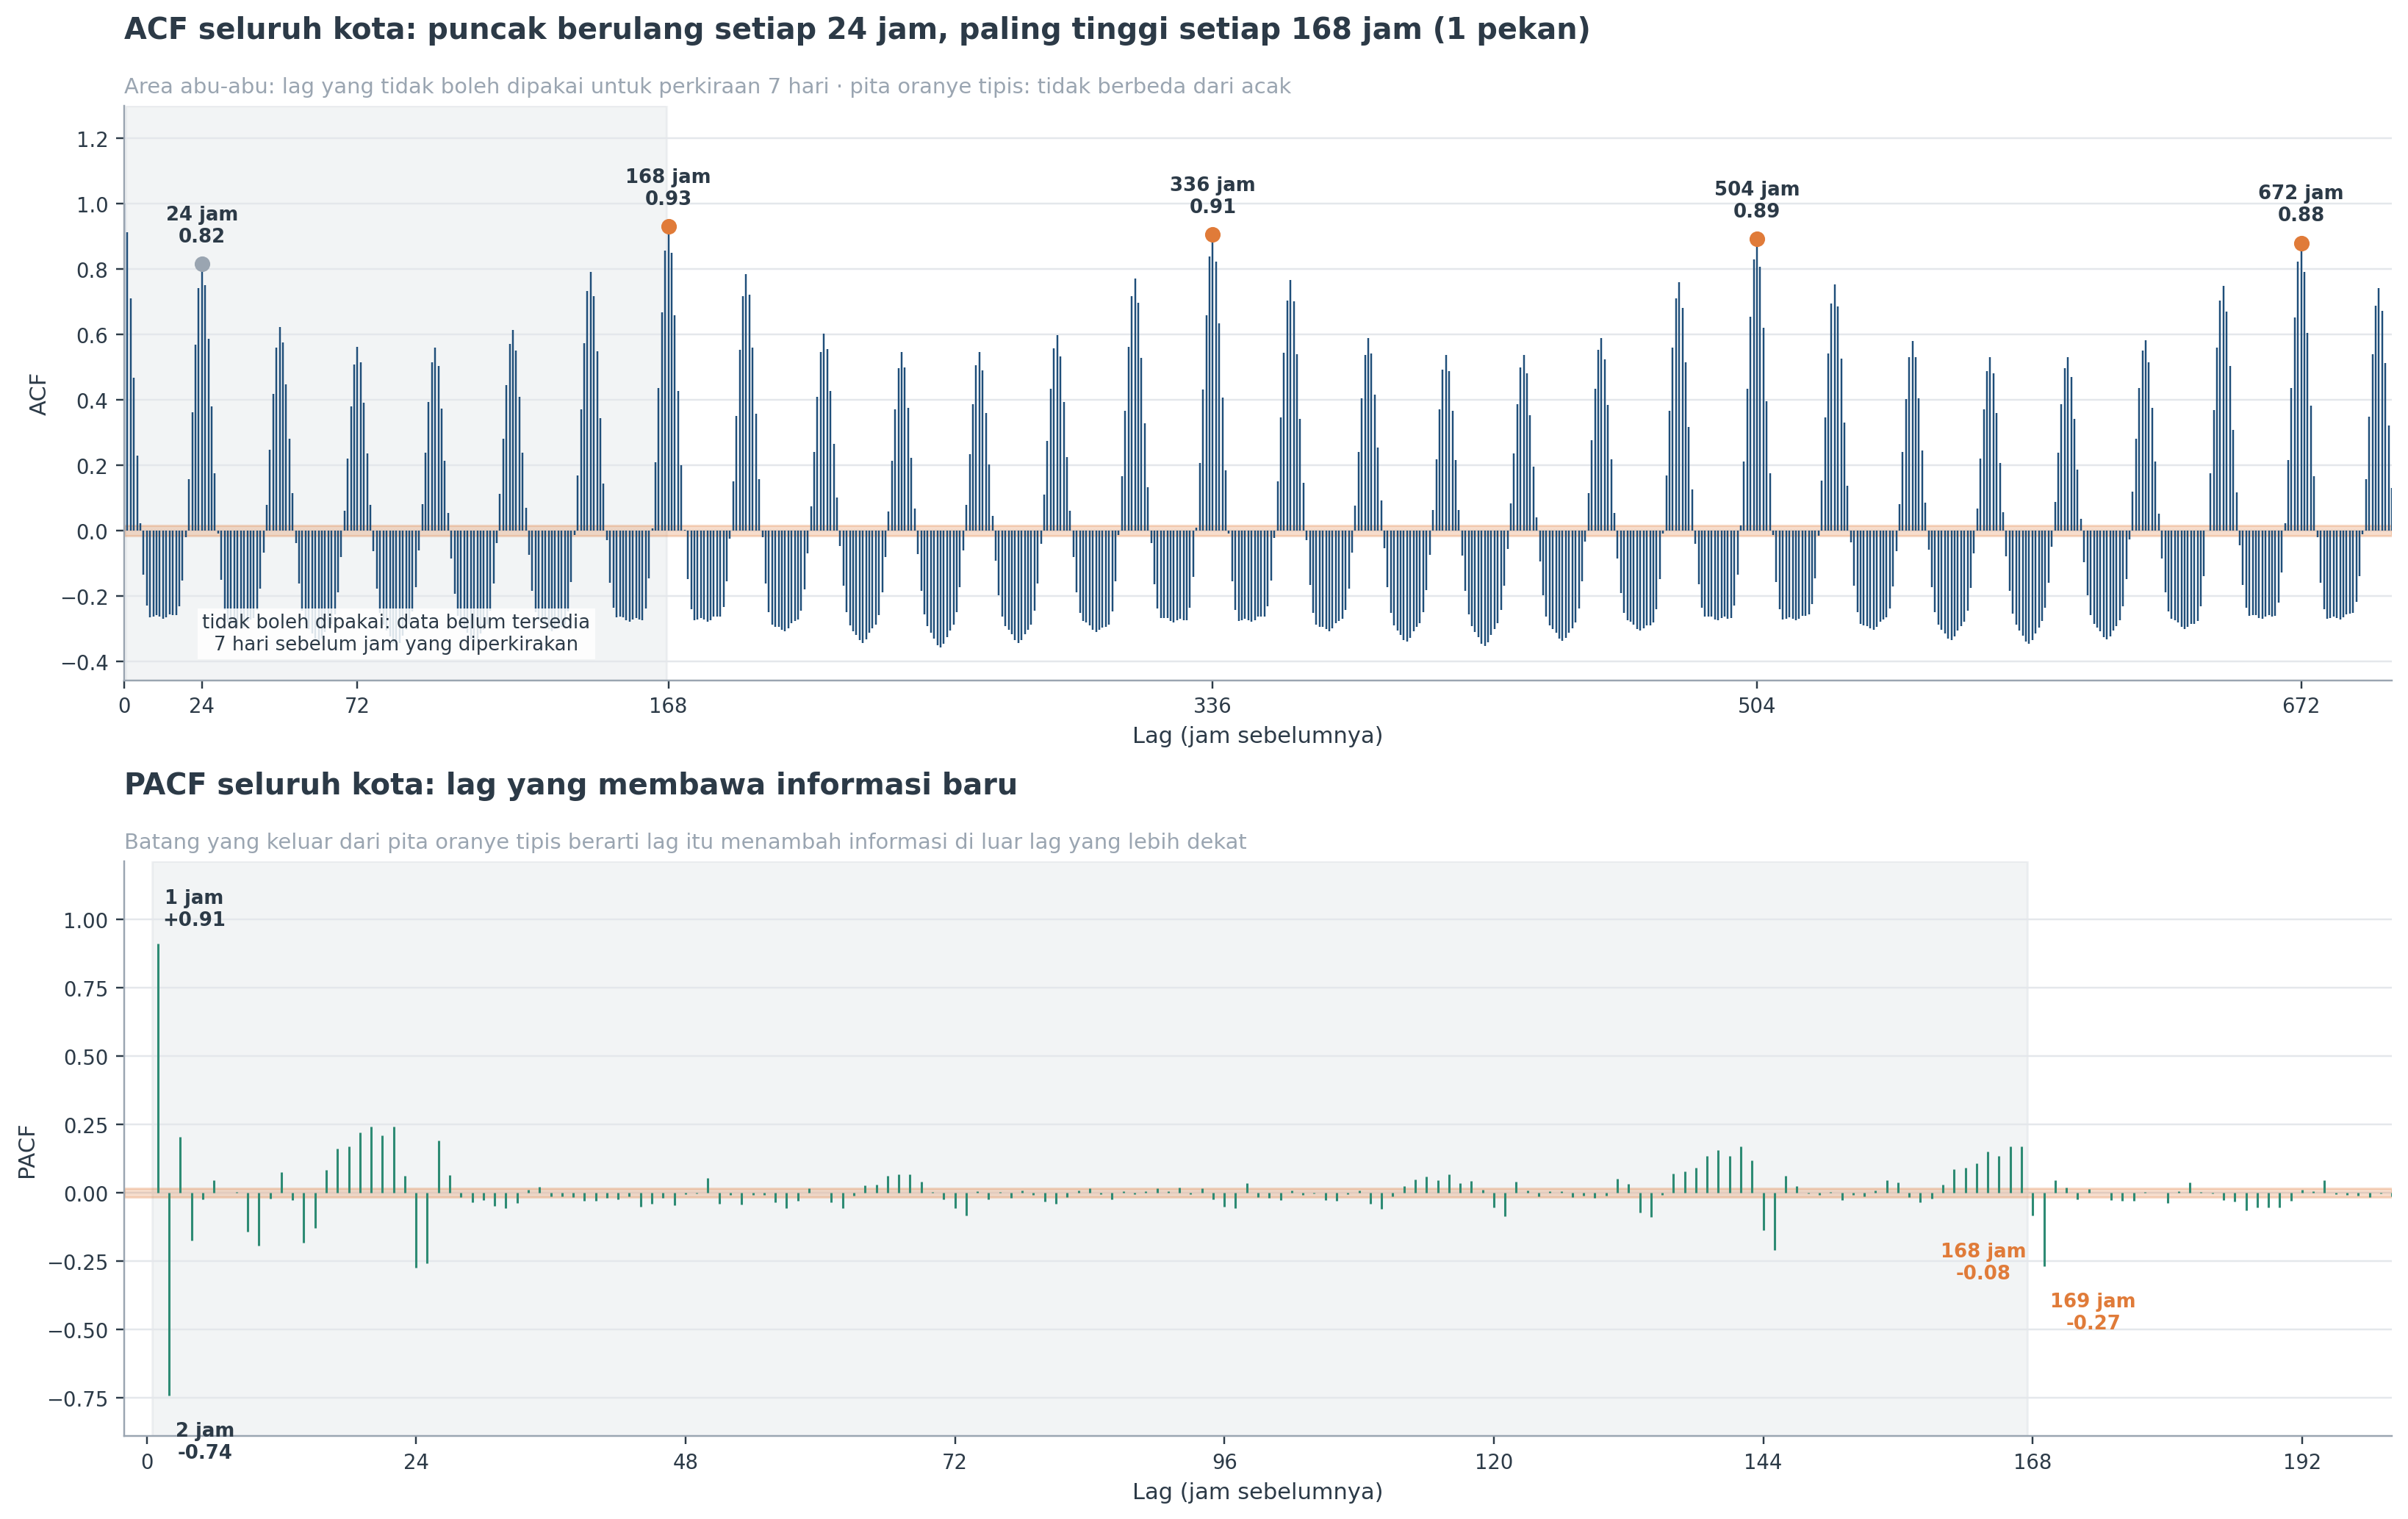

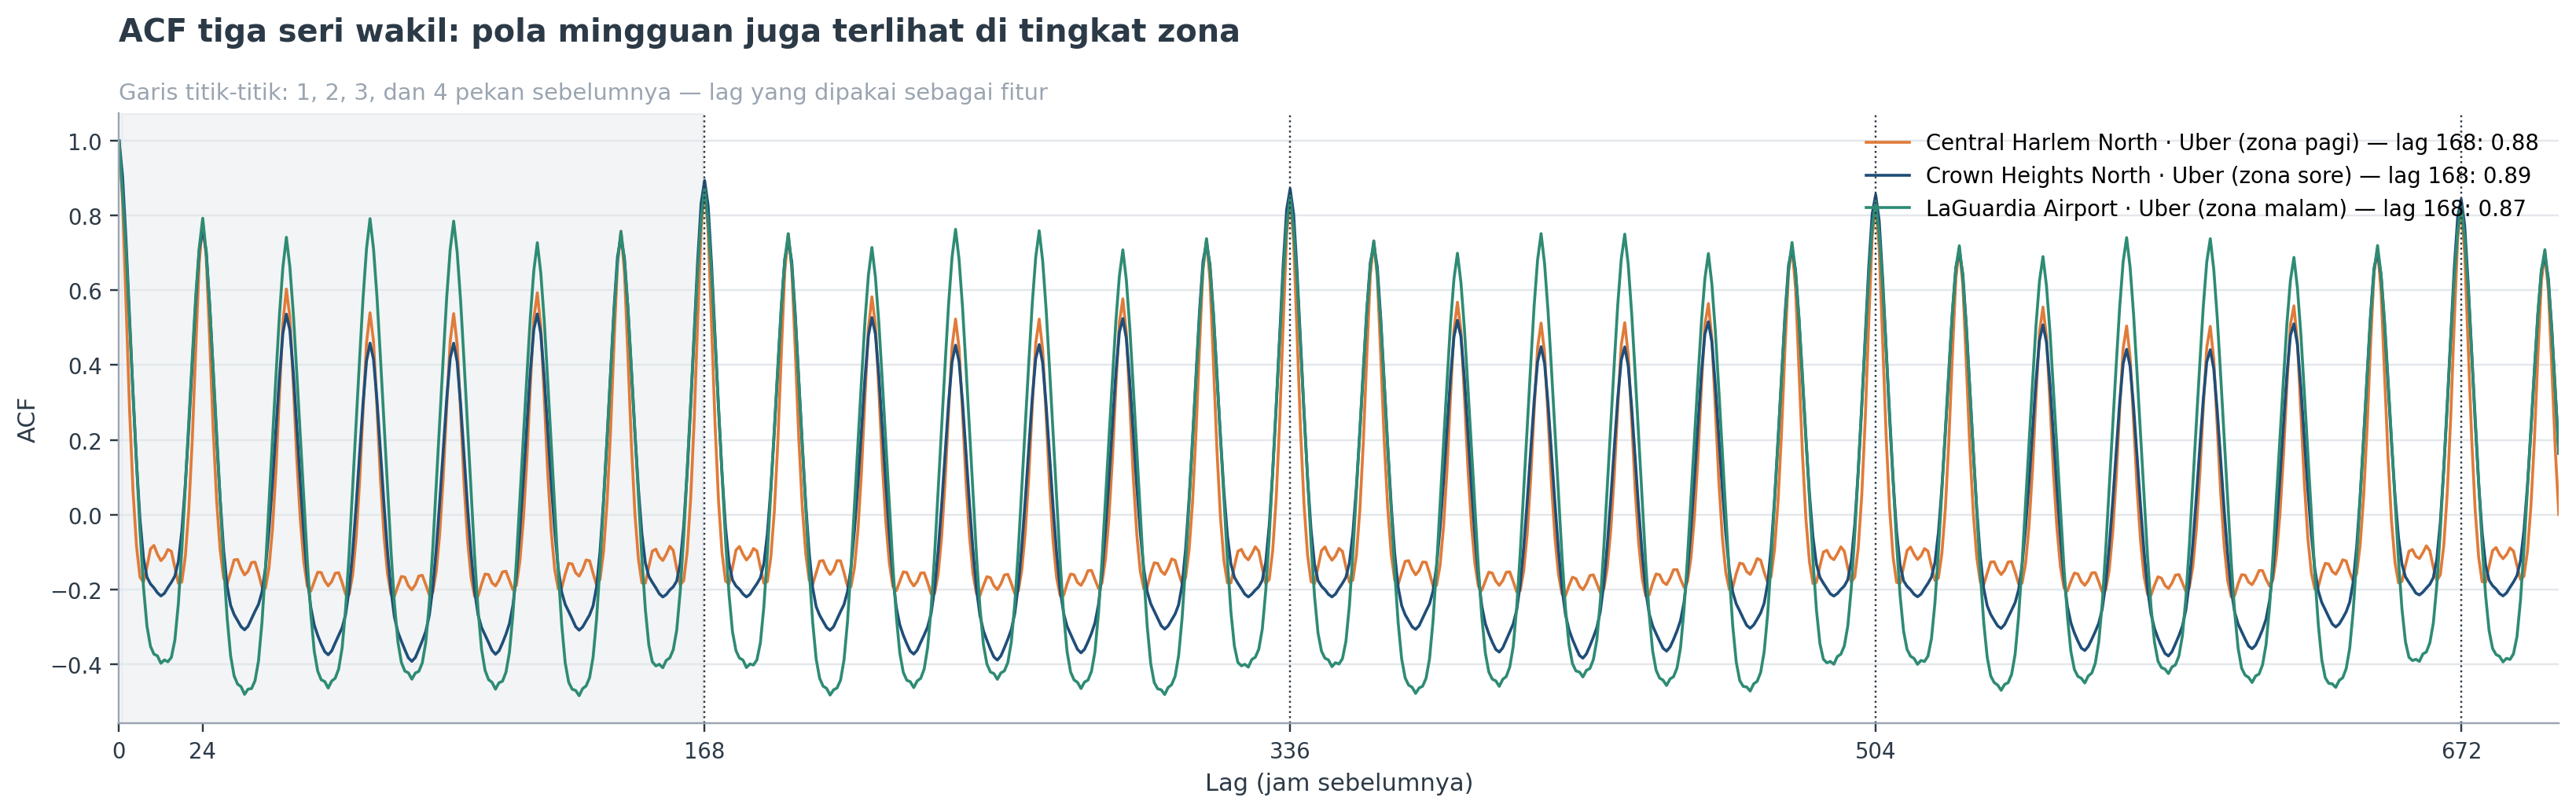

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9.5))

# ---------- ACF seluruh kota ----------
ax = axes[0]
r = ACF_HASIL["Seluruh kota"]
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
ax.text(84, min(r.min(), 0) - 0.02, "tidak boleh dipakai: data belum tersedia\n7 hari sebelum jam yang diperkirakan",
        ha="center", va="bottom", fontsize=8.5, color=C["text"],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))
ax.vlines(np.arange(LAG_ACF + 1), 0, r, color=C["primary"], linewidth=0.8)
ax.axhspan(-BATAS_ACAK, BATAS_ACAK, color=C["secondary"], alpha=0.25)
for k in [24, 168, 336, 504, 672]:
    ax.scatter([k], [r[k]], color=C["secondary"] if k >= 168 else C["muted"], s=35, zorder=5)
    ax.annotate(f"{k} jam\n{r[k]:.2f}", xy=(k, r[k]), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color=C["text"], fontweight="semibold")
ax.set_xlim(0, LAG_ACF)
ax.set_ylim(min(r.min(), 0) - 0.1, 1.3)
ax.set_xticks([0, 24, 72, 168, 336, 504, 672])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
titled(ax, "ACF seluruh kota: puncak berulang setiap 24 jam, paling tinggi setiap 168 jam (1 pekan)",
       "Area abu-abu: lag yang tidak boleh dipakai untuk perkiraan 7 hari · pita oranye tipis: tidak berbeda dari acak")
clean_axes(ax)

# ---------- PACF seluruh kota ----------
ax = axes[1]
ax.vlines(np.arange(1, LAG_PACF + 1), 0, PACF_KOTA[1:], color=C["accent"], linewidth=1)
ax.axhspan(-BATAS_ACAK, BATAS_ACAK, color=C["secondary"], alpha=0.25)
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
# Tandai lag sah (168 dan 169) dan lag terdekat terbesar sebagai pembanding
for k in [1, 2, 168, 169]:
    atas = PACF_KOTA[k] > 0
    geser = {1: 16, 2: 16, 168: -22, 169: 22}[k]
    ax.annotate(f"{k} jam\n{PACF_KOTA[k]:+.2f}", xy=(k, PACF_KOTA[k]), xytext=(geser, 8 if atas else -28),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=C["secondary"] if k >= 168 else C["text"], fontweight="semibold")
ax.set_xlim(-2, LAG_PACF)
ax.set_ylim(min(PACF_KOTA[1:].min(), 0) - 0.15, max(PACF_KOTA[1:].max(), 0) + 0.3)
ax.set_xticks([0, 24, 48, 72, 96, 120, 144, 168, 192])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("PACF")
titled(ax, "PACF seluruh kota: lag yang membawa informasi baru",
       "Batang yang keluar dari pita oranye tipis berarti lag itu menambah informasi di luar lag yang lebih dekat")
clean_axes(ax)
plt.tight_layout()
plt.show()

# ---------- ACF tiga seri wakil ----------
fig, ax = plt.subplots(figsize=(15, 4.8))
warna = [C["secondary"], C["primary"], C["accent"]]
for (n, r2), w in zip([(n, v) for n, v in ACF_HASIL.items() if n != "Seluruh kota"], warna):
    ax.plot(np.arange(LAG_ACF + 1), r2, color=w, linewidth=1.2, label=f"{n} — lag 168: {r2[168]:.2f}")
ax.axvspan(0.5, 167.5, color=C["muted"], alpha=0.12, zorder=0)
for k in [168, 336, 504, 672]:
    ax.axvline(k, color=C["text"], linestyle=":", linewidth=0.8)
ax.set_xlim(0, LAG_ACF)
ax.set_xticks([0, 24, 168, 336, 504, 672])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
ax.legend(loc="upper right", fontsize=9)
titled(ax, "ACF tiga seri wakil: pola mingguan juga terlihat di tingkat zona",
       "Garis titik-titik: 1, 2, 3, dan 4 pekan sebelumnya — lag yang dipakai sebagai fitur")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca grafik Step 5B**

**ACF seluruh kota** — setiap garis tegak adalah satu lag. Tinggi garis menunjukkan seberapa mirip permintaan sekarang dengan permintaan sekian jam sebelumnya. Area abu-abu di kiri (lag di bawah 168 jam) adalah informasi yang tidak boleh dipakai, karena perkiraan dibuat sampai 7 hari ke depan. Titik oranye menandai lag 1, 2, 3, dan 4 pekan — lag yang dipakai sebagai fitur. Pita oranye tipis di sekitar 0 adalah batas "tidak berbeda dari acak".

**PACF seluruh kota** — mirip ACF, tetapi hanya menunjukkan informasi *baru* dari setiap lag, setelah pengaruh lag-lag yang lebih dekat disingkirkan. Batang yang menonjol keluar dari pita oranye menandai lag yang layak dipakai.

**ACF tiga seri wakil** — ACF yang sama untuk satu seri dari masing-masing kelompok zona. Bila puncaknya juga berada di 168, 336, 504, dan 672 jam, pemilihan lag berlaku bukan hanya untuk kota, tetapi juga untuk tiap zona.

> **Hasil Step 5B — autokorelasi**

| Lag | ACF seluruh kota |
|---|---|
| 1 jam | 0,913 |
| 24 jam | 0,815 |
| **168 jam (7 hari)** | **0,930** |
| 336 jam (14 hari) | 0,906 |
| 504 jam (21 hari) | 0,892 |
| 672 jam (28 hari) | 0,879 |

**Temuan 1 — Lag 7 hari adalah lag paling mirip, bahkan lebih mirip dari 1 jam sebelumnya.** ACF di 168 jam (0,930) lebih tinggi dari ACF di 1 jam (0,913). Pola mingguan adalah pola terkuat dalam permintaan, sehingga batasan fitur minimal 168 jam tidak mengorbankan informasi terpenting.

**Temuan 2 — Hubungan dengan 2, 3, dan 4 pekan lalu turun sangat pelan.** Dari 0,930 ke 0,879 dalam 3 pekan. Itu membenarkan pemakaian keempat lag pekanan sebagai fitur, dan menjadi petunjuk bahwa perkiraan 14 dan 28 hari masih bermakna.

**Temuan 3 — Pola yang sama berlaku di tingkat zona.** Ketiga seri wakil — zona pagi (Central Harlem North), sore (Crown Heights North), dan malam (LaGuardia Airport) — semuanya memuncak di 168 jam (0,873–0,894). LaGuardia berbeda di lag 2–3 hari (0,742–0,791 dibanding 0,46–0,60 di zona lain): permintaan bandara lebih mirip dari hari ke hari.

**Temuan 4 — PACF menunjukkan informasi terbesar ada di 1–2 jam dan sekitar 24 jam sebelumnya,** yang tidak boleh dipakai untuk perkiraan 7 hari. Ini menjelaskan mengapa sisa kesalahan di lag 1 jam masih tinggi (Step 8B), dan menjadi dasar pengembangan model jarak pendek.

---

# STEP 6 — Pembanding Sederhana

**Tujuan:** menghitung kesalahan tiga cara sederhana, sebagai batas yang wajib dikalahkan model.

| Pembanding | Cara menebak |
|---|---|
| Angka pekan lalu | Permintaan jam yang sama 168 jam lalu |
| Rata-rata 4 pekan | Rata-rata jam yang sama 4 pekan terakhir |
| Rata-rata zona per jam | Rata-rata jam yang sama di seluruh periode sebelumnya |

**Pembanding terbaik dipilih pada tiga periode validasi di Step 7**, bukan pada periode uji, agar penilaian akhir tetap jujur. Step ini menetapkan jam sibuk dan menampilkan kesalahan pembanding.

**Cara interpretasi:** pada data uji, angka pekan lalu seharusnya mendekati 22,1 dari 100 seperti di Business Analytics (sedikit berbeda karena di sini jam kosong ikut dinilai).

In [11]:
# Jam sibuk: 6 jam dengan rata-rata permintaan kota tertinggi di periode latih
rata_per_jam = latih.groupby(latih["jam_hari"].astype(int))["demand"].mean()
JAM_SIBUK = sorted(rata_per_jam.nlargest(6).index.tolist())
print("Jam sibuk:", ", ".join(f"{h:02d}:00" for h in JAM_SIBUK), "\n")


def tambah_rata_zona_jam(df, sebelumnya):
    r = (pd.concat(sebelumnya).groupby(["provider", "zona", "jam_hari"], observed=True)["demand"]
         .mean().rename("tebak_rata_zona_jam").reset_index())
    df = df.drop(columns=["tebak_rata_zona_jam"], errors="ignore").merge(r, on=["provider", "zona", "jam_hari"], how="left")
    df["tebak_rata_zona_jam"] = df["tebak_rata_zona_jam"].fillna(0)
    return df


uji = tambah_rata_zona_jam(uji, [latih, val])
PEMBANDING = {"tebak_pekan_lalu": "Angka pekan lalu", "tebak_rata_4pekan": "Rata-rata 4 pekan",
              "tebak_rata_zona_jam": "Rata-rata zona per jam"}

pb_uji = tabel_ukur(uji, PEMBANDING)
print("Periode uji (hanya dilihat, tidak dipakai memilih):")
display(pb_uji.style.format(FORMAT_UKUR))
print(f"Angka pekan lalu pada uji, hanya jam berperjalanan : "
      f"{ukur(uji.loc[uji['demand'] > 0, 'demand'], uji.loc[uji['demand'] > 0, 'tebak_pekan_lalu'])['WMAPE']:.1f} dari 100")

Jam sibuk: 17:00, 18:00, 19:00, 20:00, 21:00, 22:00 

Periode uji (hanya dilihat, tidak dipakai memilih):


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE
Angka pekan lalu,21.34,20.94,10.99,10.36,-0.6%,30.75,16.44
Rata-rata 4 pekan,18.49,18.04,9.34,9.15,-0.2%,26.01,14.24
Rata-rata zona per jam,27.05,24.93,16.10,10.95,-5.2%,36.50,20.84


Angka pekan lalu pada uji, hanya jam berperjalanan : 21.3 dari 100


> **Hasil Step 6 — pembanding sederhana**

Jam sibuk dari data latih adalah **17:00–22:00**.

| Pembanding | WMAPE uji | WMAPE jam sibuk | Bias |
|---|---|---|---|
| Angka pekan lalu | 21,34 | 20,94 | −0,6% |
| Rata-rata 4 pekan | 18,49 | 18,04 | −0,2% |
| Rata-rata zona per jam | 27,05 | 24,93 | −5,2% |

Angka pekan lalu pada jam berperjalanan meleset 21,3 dari 100, mendekati 22,1 di Business Analytics — selisihnya karena di sini hanya 359 seri yang dinilai. Rata-rata 4 pekan jauh lebih kuat dari angka pekan lalu, sehingga menjadi pembanding yang lebih ketat daripada ukuran keberhasilan di rencana awal. Rata-rata zona per jam cenderung terlalu rendah (−5,2%), karena tidak menangkap pertumbuhan.

---

# STEP 7 — Enam Kandidat Model, Tiga Periode Validasi

**Tujuan:** membandingkan beberapa model dan memilih yang terbaik secara jujur dan stabil.

| Kandidat | Jenis | Pertanyaan yang dijawab |
|---|---|---|
| Regresi linear | Garis lurus dari fitur | Apakah hubungan sederhana sudah cukup? |
| LightGBM satu model | Pohon keputusan bertingkat, satu model untuk semua seri | Apakah pola rumit membantu? |
| XGBoost satu model | Pohon keputusan bertingkat, implementasi berbeda | Apakah pilihan implementasi boosting berpengaruh? |
| LightGBM satu model + tren | Ditambah fitur tahun lalu | Apakah informasi tahun lalu membantu? |
| LightGBM per kelompok seri | Satu model untuk tiap kelompok seri | Apakah seri ramai dan sepi perlu model sendiri? |
| LightGBM per provider | Satu model untuk Uber, satu untuk Lyft | Apakah Uber dan Lyft perlu model sendiri? |

**Model yang tidak dimasukkan dan alasannya:**

| Model | Alasan |
|---|---|
| SARIMA | Harus dibuat untuk 359 seri satu per satu dengan musim 168 jam; sangat berat, dan tiap seri tidak dapat belajar dari seri lain |
| Prophet | Juga satu model per seri; lambat untuk data per jam |
| Random Forest | Lambat dan boros memori pada 5 juta baris; umumnya kalah dari boosting |
| LSTM, N-BEATS, TFT | Membutuhkan GPU dan tuning yang besar, di luar cakupan project |

**Kenapa tiga periode validasi:** memilih dari satu periode saja berisiko kebetulan — misalnya Oktober–Desember adalah musim paling ramai. Setiap kandidat dilatih tiga kali: sekali untuk setiap periode validasi, masing-masing memakai semua data sebelum periode itu. Hasil ketiganya digabung.

**Aturan memilih:**

1. **Syarat:** bias tidak lebih dari ±3%, dan lebih baik dari pembanding terbaik pada RMSE dan pada WMAPE jam sibuk
2. Dari kandidat yang memenuhi syarat, dipilih WMAPE gabungan terkecil
3. Kandidat dengan selisih WMAPE kurang dari 0,1 poin dianggap setara; di antara yang setara dipilih yang paling sederhana (urutan tabel di atas)

**Waktu:** enam kandidat × tiga periode — umumnya 30–60 menit. Log `[200] validasi's wmape` muncul berkala.

In [12]:
FITUR_DASAR_NUM = ["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan",
                   "rata_jam_sama_4pekan", "median_jam_sama_4pekan",
                   "rata_1hari", "rata_1pekan", "rata_4pekan",
                   "jam_hari", "hari", "bulan", "libur", "libur_1pekan", "libur_4pekan", "malam_akhir_pekan"]
FITUR_TREN = ["lag_52pekan", "rata_4pekan_tahun_lalu", "rasio_tren"]
FITUR_DASAR = FITUR_DASAR_NUM + KAT

PARAM = {"objective": "tweedie", "tweedie_variance_power": 1.2, "metric": "None",
         "learning_rate": 0.05, "num_leaves": 255, "min_data_in_leaf": 200,
         "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
         "lambda_l2": 1.0, "max_cat_to_onehot": 8, "verbose": -1, "seed": 42}
PARAM_XGB = {"objective": "reg:tweedie", "tweedie_variance_power": 1.2, "eta": 0.05, "max_depth": 8,
             "min_child_weight": 50, "subsample": 0.8, "colsample_bytree": 0.8, "lambda": 1.0,
             "tree_method": "hist", "max_cat_to_onehot": 8, "disable_default_eval_metric": 1, "seed": 42}
PUTARAN = 3000


def _kat(fitur):
    return [f for f in fitur if f in KAT]


# ---------- LightGBM: satu model atau dipisah per kolom ----------
def _wmape_lgb(p, d):
    y = d.get_label()
    return "wmape", np.abs(y - p).sum() / y.sum(), False


def lgb_latih(df_l, df_v, fitur, pisah=None):
    grup = [None] if pisah is None else [g for g in df_l[pisah].cat.categories if (df_l[pisah] == g).any()]
    st = {"jenis": "lgb", "fitur": fitur, "pisah": pisah, "model": {}, "iter": {}}
    for g in grup:
        a = df_l if g is None else df_l[df_l[pisah] == g]
        b = df_v if g is None else df_v[df_v[pisah] == g]
        d_l = lgb.Dataset(a[fitur], a["demand"], categorical_feature=_kat(fitur))
        d_v = lgb.Dataset(b[fitur], b["demand"], categorical_feature=_kat(fitur), reference=d_l)
        m = lgb.train(PARAM, d_l, num_boost_round=PUTARAN, valid_sets=[d_v], valid_names=["validasi"],
                      feval=_wmape_lgb, callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)])
        st["model"][g], st["iter"][g] = m, m.best_iteration
        print(f"      {'semua seri' if g is None else f'{pisah} = {g}'} : iterasi terbaik {m.best_iteration}")
    return st


def lgb_latih_ulang(st, df):
    baru = dict(st, model={})
    for g, it in st["iter"].items():
        a = df if g is None else df[df[st["pisah"]] == g]
        baru["model"][g] = lgb.train(PARAM, lgb.Dataset(a[st["fitur"]], a["demand"],
                                     categorical_feature=_kat(st["fitur"])), num_boost_round=it)
    return baru


def lgb_tebak(st, df):
    hasil = np.zeros(len(df))
    for g, m in st["model"].items():
        idx = np.ones(len(df), bool) if g is None else (df[st["pisah"]] == g).to_numpy()
        if idx.any():
            hasil[idx] = m.predict(df.loc[idx, st["fitur"]], num_iteration=st["iter"][g])
    return np.clip(hasil, 0, None)


# ---------- XGBoost ----------
def _wmape_xgb(p, d):
    y = d.get_label()
    return "wmape", float(np.abs(y - p).sum() / y.sum())


def _dm(df, fitur, label=True):
    return xgb.DMatrix(df[fitur], label=df["demand"] if label else None, enable_categorical=True)


def xgb_latih(df_l, df_v, fitur):
    m = xgb.train(PARAM_XGB, _dm(df_l, fitur), num_boost_round=PUTARAN, evals=[(_dm(df_v, fitur), "validasi")],
                  custom_metric=_wmape_xgb, early_stopping_rounds=100, verbose_eval=200)
    print(f"      semua seri : iterasi terbaik {m.best_iteration + 1}")
    return {"jenis": "xgb", "fitur": fitur, "pisah": None, "model": {None: m}, "iter": {None: m.best_iteration + 1}}


def xgb_latih_ulang(st, df):
    return dict(st, model={None: xgb.train(PARAM_XGB, _dm(df, st["fitur"]), num_boost_round=st["iter"][None])})


def xgb_tebak(st, df):
    return np.clip(st["model"][None].predict(_dm(df, st["fitur"], label=False),
                                             iteration_range=(0, st["iter"][None])), 0, None)


# ---------- Regresi linear (ridge), dihitung bertahap agar hemat memori ----------
LIN_NUM = ["lag_1pekan", "lag_2pekan", "lag_3pekan", "lag_4pekan", "rata_jam_sama_4pekan", "median_jam_sama_4pekan",
           "rata_1hari", "rata_1pekan", "rata_4pekan", "libur", "libur_1pekan", "libur_4pekan", "malam_akhir_pekan"]


def _matriks(df):
    num = np.column_stack([df[k].to_numpy(np.float32) for k in LIN_NUM])
    isi = np.nan_to_num(df["rata_4pekan"].to_numpy(np.float32))
    num = np.nan_to_num(np.where(np.isnan(num), isi[:, None], num))
    jam = np.eye(24, dtype=np.float32)[df["jam_hari"].to_numpy().astype(int)][:, 1:]
    hari = np.eye(7, dtype=np.float32)[df["hari"].to_numpy().astype(int) - 1][:, 1:]
    prov = (df["provider"].astype(str).to_numpy() == KAT_NILAI["provider"][0]).astype(np.float32)[:, None]
    kj = np.column_stack([(df["kelompok_jam"].astype(str).to_numpy() == g)
                          for g in KAT_NILAI["kelompok_jam"][1:]]).astype(np.float32)
    return np.hstack([np.ones((len(df), 1), np.float32), num, jam, hari, prov, kj])


def lin_latih(df_l, df_v=None, lam=1.0, blok=500_000):
    xtx, xty = None, None
    for i in range(0, len(df_l), blok):
        X = _matriks(df_l.iloc[i:i + blok]).astype(np.float64)
        y = df_l["demand"].to_numpy(np.float64)[i:i + blok]
        xtx = X.T @ X if xtx is None else xtx + X.T @ X
        xty = X.T @ y if xty is None else xty + X.T @ y
    reg = lam * np.eye(xtx.shape[0]); reg[0, 0] = 0
    return {"jenis": "linear", "koef": np.linalg.solve(xtx + reg, xty), "iter": {}}


def lin_tebak(st, df, blok=500_000):
    return np.clip(np.concatenate([_matriks(df.iloc[i:i + blok]) @ st["koef"] for i in range(0, len(df), blok)]), 0, None)


def tebak(st, df):
    return {"linear": lin_tebak, "lgb": lgb_tebak, "xgb": xgb_tebak}[st["jenis"]](st, df)


def latih_ulang(st, df):
    if st["jenis"] == "linear":
        return lin_latih(df)
    return lgb_latih_ulang(st, df) if st["jenis"] == "lgb" else xgb_latih_ulang(st, df)


KANDIDAT = {
    "Regresi linear":             lambda l, v: lin_latih(l),
    "LightGBM satu model":        lambda l, v: lgb_latih(l, v, FITUR_DASAR),
    "XGBoost satu model":         lambda l, v: xgb_latih(l, v, FITUR_DASAR),
    "LightGBM satu model + tren": lambda l, v: lgb_latih(l, v, FITUR_DASAR + FITUR_TREN),
    "LightGBM per kelompok seri": lambda l, v: lgb_latih(l, v, FITUR_DASAR, pisah="kelompok_seri"),
    "LightGBM per provider":      lambda l, v: lgb_latih(l, v, FITUR_DASAR, pisah="provider"),
}
if not ADA_XGB:
    del KANDIDAT["XGBoost satu model"]

# ---------- Tiga periode validasi ----------
sejarah = pd.concat([latih[KOLOM_DATA], val[KOLOM_DATA]], ignore_index=True)
TEBAKAN_LIP = {n: [] for n in KANDIDAT}
TEBAKAN_LIP["Rata-rata zona per jam"] = []
ITER_LIP = {n: [] for n in KANDIDAT}
CONTOH_STATE, WAKTU = {}, {n: 0.0 for n in KANDIDAT}
idx_lip, label_lip = [], []

for nama_lip, mulai, akhir in LIPATAN:
    m_l = (sejarah["jam"] < pd.Timestamp(mulai)).to_numpy()
    m_v = ((sejarah["jam"] >= pd.Timestamp(mulai)) & (sejarah["jam"] < pd.Timestamp(akhir))).to_numpy()
    tr, va = sejarah[m_l], sejarah[m_v]
    print(f"\n==== Periode validasi {nama_lip}: latih {len(tr):,} baris, validasi {len(va):,} baris")
    TEBAKAN_LIP["Rata-rata zona per jam"].append(tambah_rata_zona_jam(va, [tr])["tebak_rata_zona_jam"].to_numpy())
    for n, fungsi in KANDIDAT.items():
        print(f"  >> {n}")
        t0 = time.time()
        st = fungsi(tr, va)
        TEBAKAN_LIP[n].append(tebak(st, va))
        ITER_LIP[n].append(dict(st["iter"]))
        CONTOH_STATE[n] = st
        WAKTU[n] += (time.time() - t0) / 60
        print(f"     meleset {ukur(va['demand'], TEBAKAN_LIP[n][-1])['WMAPE']:.2f} dari 100")
    idx_lip.append(np.flatnonzero(m_v)); label_lip += [nama_lip] * int(m_v.sum())
    del tr, va; gc.collect()

oof = sejarah.iloc[np.concatenate(idx_lip)].reset_index(drop=True)
oof["periode_validasi"] = label_lip
for n, daftar in TEBAKAN_LIP.items():
    oof[f"tebak_{n}"] = np.concatenate(daftar)
oof = oof.rename(columns={"tebak_Rata-rata zona per jam": "tebak_rata_zona_jam"})
print(f"\nSelesai. Tebakan validasi gabungan: {len(oof):,} baris")


==== Periode validasi Apr–Jun 2025: latih 3,661,082 baris, validasi 784,056 baris
  >> Regresi linear
     meleset 15.15 dari 100
  >> LightGBM satu model
[200]	validasi's wmape: 0.145038
[400]	validasi's wmape: 0.144206
[600]	validasi's wmape: 0.144157
      semua seri : iterasi terbaik 501
     meleset 14.41 dari 100
  >> XGBoost satu model
[0]	validasi-wmape:0.63648
[200]	validasi-wmape:0.14605
[400]	validasi-wmape:0.14533
[600]	validasi-wmape:0.14510
[680]	validasi-wmape:0.14511
      semua seri : iterasi terbaik 581
     meleset 14.51 dari 100
  >> LightGBM satu model + tren
      semua seri : iterasi terbaik 94
     meleset 14.57 dari 100
  >> LightGBM per kelompok seri
[200]	validasi's wmape: 0.133542
      kelompok_seri = 1 : iterasi terbaik 297
[200]	validasi's wmape: 0.154549
[400]	validasi's wmape: 0.154307
      kelompok_seri = 2 : iterasi terbaik 318
[200]	validasi's wmape: 0.195575
      kelompok_seri = 3 : iterasi terbaik 214
     meleset 14.51 dari 100
  >> LightGBM pe

In [13]:
# Jumlah iterasi akhir: median dari ketiga periode validasi
def iter_median(daftar):
    kunci = {k for d in daftar for k in d}
    return {k: int(np.median([d[k] for d in daftar if k in d])) for k in kunci}


STATE = {n: dict(CONTOH_STATE[n], iter=iter_median(ITER_LIP[n])) for n in KANDIDAT}

SEMUA_VAL = {f"tebak_{n}": n for n in KANDIDAT} | PEMBANDING
hasil_val = tabel_ukur(oof, SEMUA_VAL)
hasil_val["Waktu latih (menit)"] = pd.Series(WAKTU)
hasil_val["Jenis"] = ["Kandidat"] * len(KANDIDAT) + ["Pembanding"] * len(PEMBANDING)

per_periode = oof.groupby("periode_validasi", sort=False).apply(
    lambda g: pd.Series({n: ukur(g["demand"], g[k])["WMAPE"] for k, n in SEMUA_VAL.items()})).T

# Pembanding terbaik, dipilih pada validasi gabungan
PB_TERBAIK = hasil_val.loc[list(PEMBANDING.values()), "WMAPE"].idxmin()
KOLOM_PB = {v: k for k, v in PEMBANDING.items()}[PB_TERBAIK]
pb = hasil_val.loc[PB_TERBAIK]

# Aturan memilih
kand = hasil_val.loc[list(KANDIDAT)]
syarat = pd.DataFrame({
    "Bias ≤ ±3%": kand["Bias %"].abs() <= BATAS_BIAS,
    "RMSE < pembanding": kand["RMSE"] < pb["RMSE"],
    "Jam sibuk < pembanding": kand["WMAPE jam sibuk"] < pb["WMAPE jam sibuk"],
})
syarat["Layak"] = syarat.all(axis=1)
layak = kand[syarat["Layak"]] if syarat["Layak"].any() else kand
dekat = layak[layak["WMAPE"] - layak["WMAPE"].min() < BATAS_SETARA]
urutan = {n: i for i, n in enumerate(KANDIDAT)}
TERPILIH = min(dekat.index, key=urutan.get)
STATE_TERPILIH = STATE[TERPILIH]

print("Tiga periode validasi digabung (April–Desember 2025):")
display(hasil_val.sort_values("WMAPE").style.format({**FORMAT_UKUR, "Waktu latih (menit)": "{:.1f}"}, na_rep="—"))
print("WMAPE per periode validasi — apakah urutan model stabil?")
display(per_periode.loc[hasil_val.sort_values("WMAPE").index].style.format("{:.2f}"))
print(f"Syarat pemilihan (pembanding: {PB_TERBAIK}):")
display(syarat.replace({True: "ya", False: "TIDAK"}))
print(f"Kandidat setara dengan yang terbaik (selisih < {BATAS_SETARA} poin): {list(dekat.index)}")
print(f"\nMODEL TERPILIH : {TERPILIH}")
print(f"  meleset {hasil_val.loc[TERPILIH, 'WMAPE']:.2f} dari 100, bias {hasil_val.loc[TERPILIH, 'Bias %']:+.1f}%, "
      f"jam sibuk {hasil_val.loc[TERPILIH, 'WMAPE jam sibuk']:.2f}")
print(f"  pembanding terbaik ({PB_TERBAIK}) meleset {pb['WMAPE']:.2f} dari 100")
print(f"  jumlah iterasi akhir: {STATE_TERPILIH['iter'] or '—'}")

Tiga periode validasi digabung (April–Desember 2025):


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE,Waktu latih (menit),Jenis
LightGBM satu model + tren,14.86,14.51,8.25,6.61,-1.6%,19.70,10.89,2.3,Kandidat
LightGBM satu model,14.87,14.60,7.97,6.90,-1.1%,19.95,10.90,7.4,Kandidat
LightGBM per provider,14.99,14.74,7.95,7.04,-0.9%,20.11,10.99,5.8,Kandidat
XGBoost satu model,14.99,14.73,8.03,6.96,-1.1%,20.22,10.99,10.7,Kandidat
LightGBM per kelompok seri,15.06,14.79,8.15,6.91,-1.2%,20.17,11.04,4.8,Kandidat
Regresi linear,16.47,16.06,8.34,8.13,-0.2%,22.67,12.07,0.1,Kandidat
Rata-rata 4 pekan,16.64,16.23,8.47,8.17,-0.3%,23.09,12.19,—,Pembanding
Angka pekan lalu,20.01,19.43,9.92,10.10,+0.2%,27.53,14.67,—,Pembanding
Rata-rata zona per jam,25.59,23.99,13.14,12.45,-0.7%,33.67,18.76,—,Pembanding


WMAPE per periode validasi — apakah urutan model stabil?


periode_validasi,Apr–Jun 2025,Jul–Sep 2025,Okt–Des 2025
LightGBM satu model + tren,14.57,14.18,15.75
LightGBM satu model,14.41,14.04,16.05
LightGBM per provider,14.50,14.18,16.19
XGBoost satu model,14.51,14.12,16.24
LightGBM per kelompok seri,14.51,14.26,16.31
Regresi linear,15.15,15.94,18.21
Rata-rata 4 pekan,15.18,16.14,18.48
Angka pekan lalu,18.85,19.04,22.00
Rata-rata zona per jam,24.72,25.62,26.40


Syarat pemilihan (pembanding: Rata-rata 4 pekan):


,Bias ≤ ±3%,RMSE < pembanding,Jam sibuk < pembanding,Layak
Regresi linear,ya,ya,ya,ya
LightGBM satu model,ya,ya,ya,ya
XGBoost satu model,ya,ya,ya,ya
LightGBM satu model + tren,ya,ya,ya,ya
LightGBM per kelompok seri,ya,ya,ya,ya
LightGBM per provider,ya,ya,ya,ya


Kandidat setara dengan yang terbaik (selisih < 0.1 poin): ['LightGBM satu model', 'LightGBM satu model + tren']

MODEL TERPILIH : LightGBM satu model
  meleset 14.87 dari 100, bias -1.1%, jam sibuk 14.60
  pembanding terbaik (Rata-rata 4 pekan) meleset 16.64 dari 100
  jumlah iterasi akhir: {None: 1188}


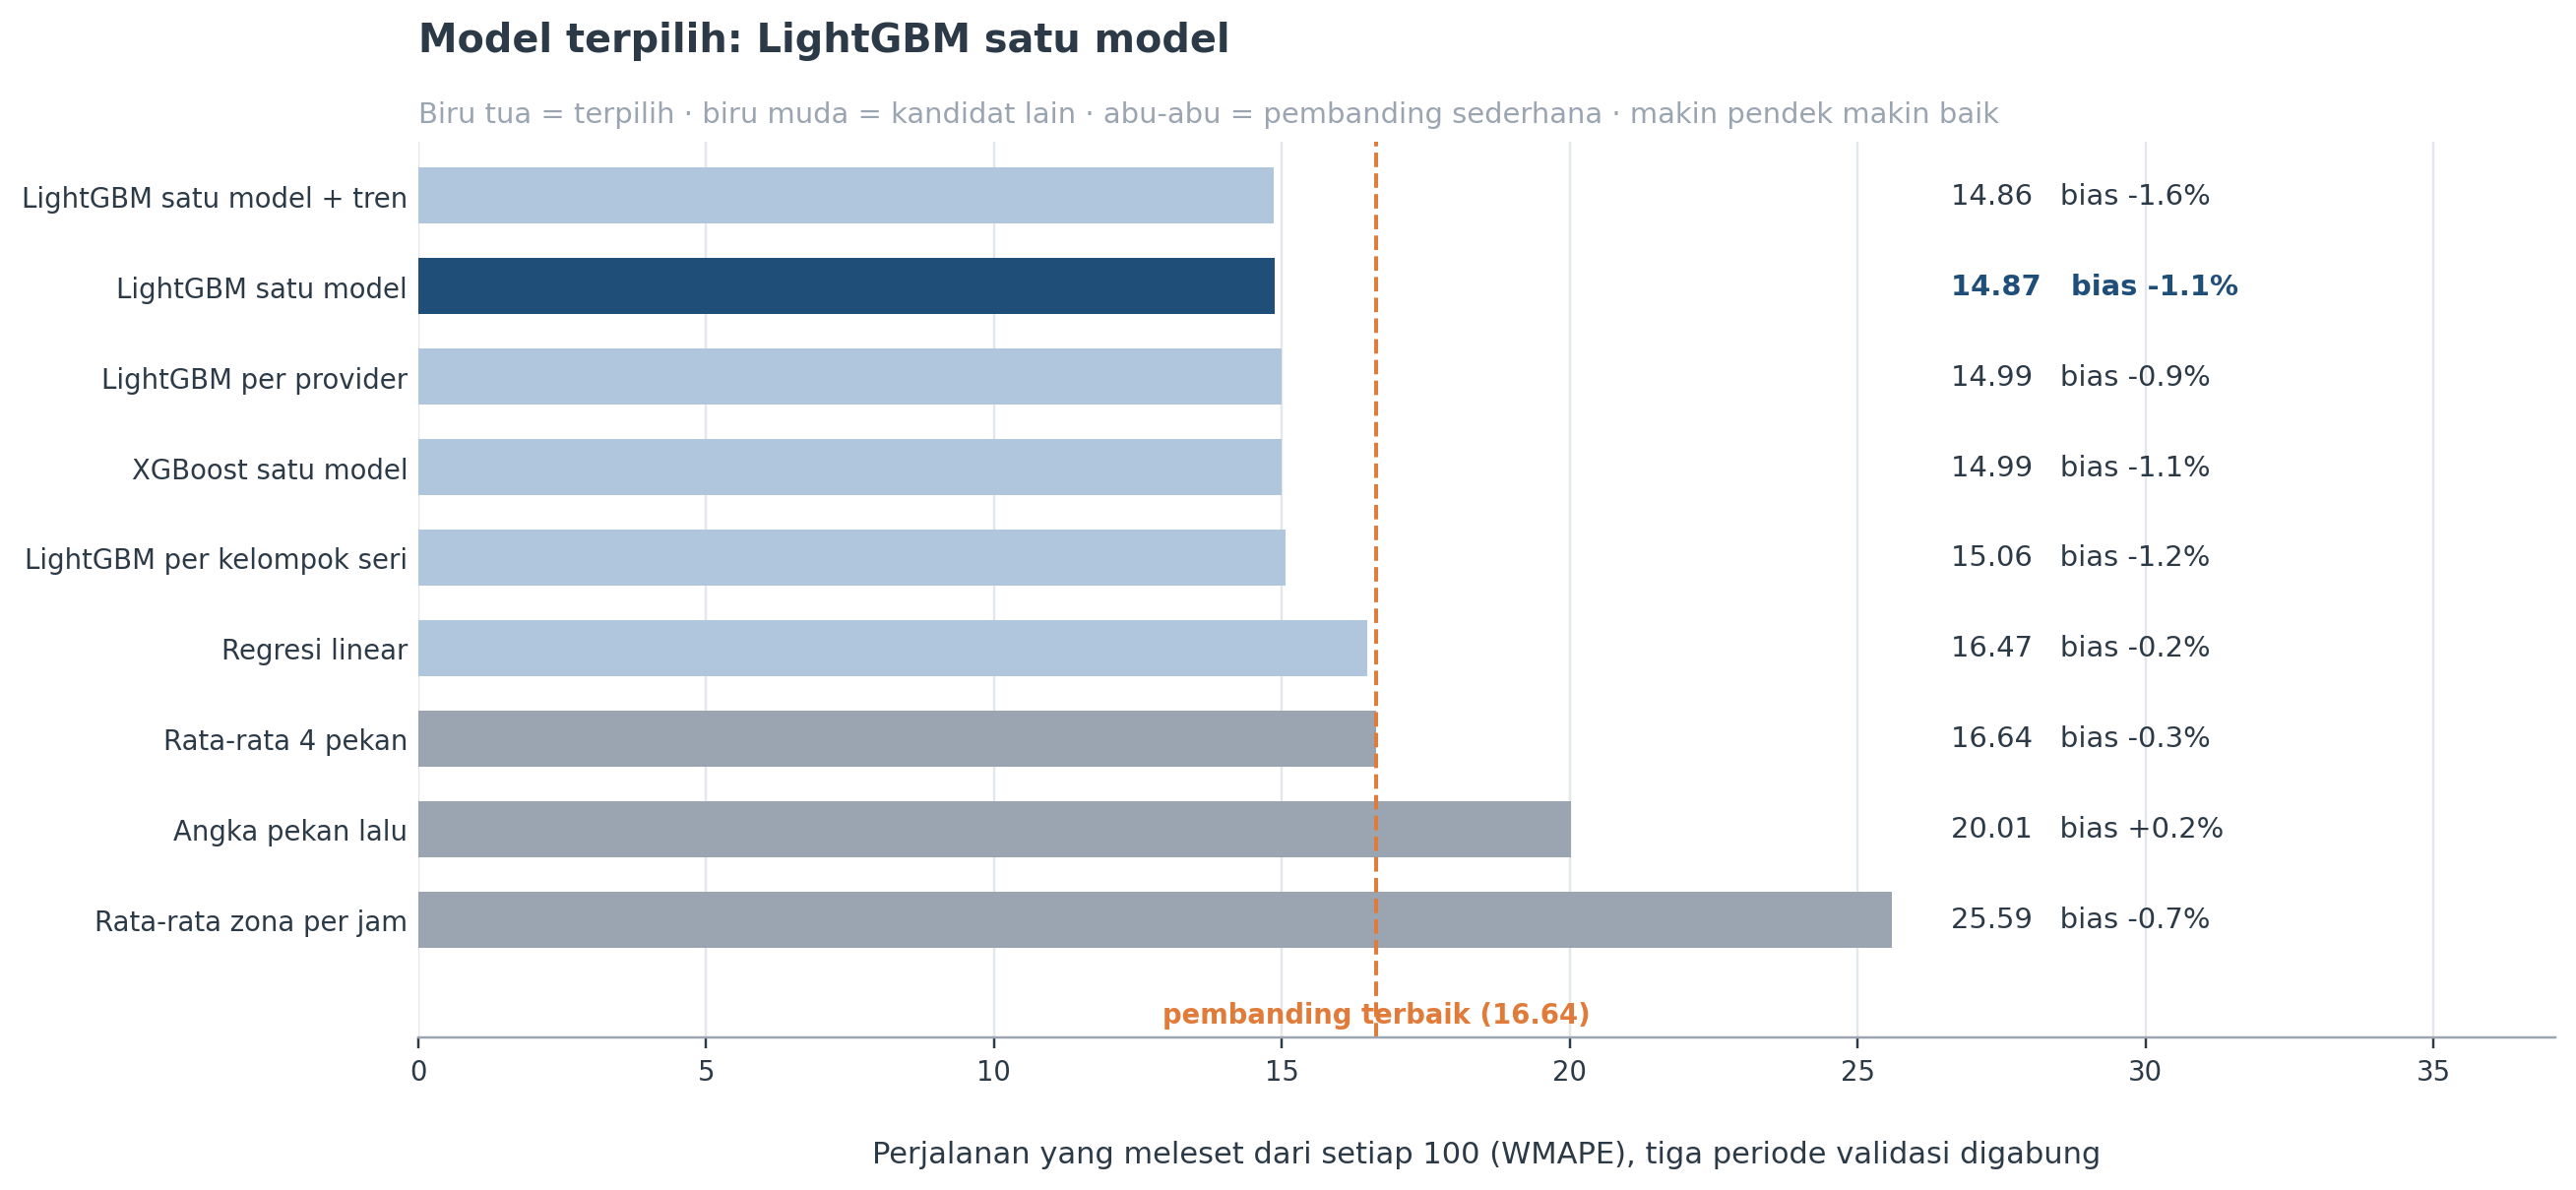

In [14]:
urut = hasil_val.sort_values("WMAPE", ascending=False)
warna = [C["primary"] if n == TERPILIH else (C["muted"] if j == "Pembanding" else C["band"])
         for n, j in zip(urut.index, urut["Jenis"])]

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.barh(urut.index, urut["WMAPE"], color=warna, height=0.62)
batas_x = urut["WMAPE"].max() * 1.45
for i, (v, b) in enumerate(zip(urut["WMAPE"], urut["Bias %"])):
    ax.text(urut["WMAPE"].max() * 1.04, i, f"{v:.2f}   bias {b:+.1f}%", va="center", fontsize=9.5,
            color=C["primary"] if urut.index[i] == TERPILIH else C["text"],
            fontweight="bold" if urut.index[i] == TERPILIH else "normal")
x_pb = hasil_val.loc[PB_TERBAIK, "WMAPE"]
ax.axvline(x_pb, color=C["secondary"], linestyle="--", linewidth=1.3)
ax.text(x_pb, -0.9, f"pembanding terbaik ({x_pb:.2f})", color=C["secondary"], fontsize=9,
        ha="center", va="top", fontweight="semibold")
ax.set_xlim(0, batas_x)
ax.set_ylim(-1.3, len(urut) - 0.4)
ax.set_xlabel("Perjalanan yang meleset dari setiap 100 (WMAPE), tiga periode validasi digabung", labelpad=18)
titled(ax, f"Model terpilih: {TERPILIH}",
       "Biru tua = terpilih · biru muda = kandidat lain · abu-abu = pembanding sederhana · makin pendek makin baik")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

> **Cara membaca grafik dan tabel Step 7**

**Grafik** — setiap batang adalah satu cara menebak, dinilai pada tiga periode validasi yang digabung (April–Desember 2025). Panjang batang adalah jumlah perjalanan yang meleset dari setiap 100 — makin pendek makin baik. Garis putus-putus oranye adalah pembanding sederhana terbaik.

**Tabel utama** — seluruh ukuran kesalahan untuk setiap cara.

**Tabel per periode** — WMAPE di masing-masing periode validasi. Bila urutan kandidat berubah-ubah antar periode, perbedaan di antara mereka tidak dapat dipegang.

**Tabel syarat** — apakah setiap kandidat memenuhi ketiga syarat. Hanya kandidat bertanda "ya" di semua kolom yang boleh dipilih.

> **Hasil Step 7 — pemilihan model**

| Kandidat | WMAPE validasi | Apr–Jun | Jul–Sep | Okt–Des |
|---|---|---|---|---|
| LightGBM satu model + tren | 14,84 | 14,54 | 14,14 | **15,75** |
| **LightGBM satu model** | **14,87** | **14,41** | **14,05** | 16,04 |
| LightGBM per provider | 14,99 | 14,52 | 14,17 | 16,18 |
| XGBoost satu model | 14,99 | 14,52 | 14,12 | 16,24 |
| LightGBM per kelompok seri | 15,06 | 14,50 | 14,28 | 16,30 |
| Regresi linear | 16,47 | 15,15 | 15,94 | 18,21 |
| Rata-rata 4 pekan (pembanding) | 16,64 | 15,18 | 16,14 | 18,48 |

**Temuan 1 — LightGBM satu model terpilih.** Selisihnya dengan "+ tren" hanya 0,03 poin, sehingga keduanya setara dan yang lebih sederhana dipilih. "+ tren" hanya menang di Oktober–Desember; di dua periode lain LightGBM satu model lebih baik. Memilih dari satu periode saja akan memilih model yang salah — seperti terjadi pada versi notebook sebelumnya.

**Temuan 2 — XGBoost tidak memberi keuntungan.** WMAPE-nya 14,99, sedikit lebih buruk dari LightGBM, dengan waktu latih hampir dua kali lipat (11,3 menit dibanding 6,9 menit untuk tiga periode).

**Temuan 3 — Memisah model tidak membantu.** Model per provider dan per kelompok seri sedikit lebih buruk dari satu model. Satu model untuk semua seri dapat meminjam pola dari seri ramai untuk seri yang lebih sepi.

**Temuan 4 — Regresi linear hampir sama dengan rata-rata 4 pekan.** Hubungan sederhana tidak cukup; keunggulan datang dari pola rumit yang ditangkap model pohon.

Seluruh kandidat memenuhi syarat bias, RMSE, dan jam sibuk. Jumlah iterasi akhir: 926, median dari ketiga periode.

---

# STEP 8 — Penilaian pada Periode Uji, Dilatih Ulang Setiap Bulan

**Tujuan:** menilai model terpilih pada Januari–Mei 2026 dengan cara yang sama seperti saat dipakai sungguhan.

**Cara:** sebelum setiap bulan, model dilatih ulang dengan semua data sampai awal bulan itu, lalu menebak bulan tersebut. Jadi perkiraan Maret dibuat oleh model yang sudah melihat Januari dan Februari. Ini sesuai rencana awal project: **pelatihan ulang bergulir**.

Sebagai pembanding, ditampilkan juga model yang **dilatih sekali** sampai Desember 2025. Selisih keduanya menunjukkan manfaat melatih ulang.

Hasil uji kandidat lain juga ditampilkan untuk keterbukaan, tetapi tidak dipakai untuk memilih.

**Cara interpretasi:** model berhasil bila kesalahannya lebih kecil dari pembanding terbaik di seluruh seri dan di setiap kelompok seri.

In [15]:
# ---------- Dilatih ulang setiap awal bulan ----------
batas_bulan = pd.date_range(TEST_MULAI, PERKIRAAN_MULAI, freq="MS")
uji["perkiraan"] = np.nan
t0 = time.time()
for m0, m1 in zip(batas_bulan[:-1], batas_bulan[1:]):
    data_latih = pd.concat([sejarah, uji.loc[uji["jam"] < m0, KOLOM_DATA]], ignore_index=True)
    st = latih_ulang(STATE_TERPILIH, data_latih)
    idx = (uji["jam"] >= m0) & (uji["jam"] < m1)
    uji.loc[idx, "perkiraan"] = tebak(st, uji.loc[idx])
    print(f"  {m0:%B %Y}: dilatih dengan {len(data_latih):,} baris")
    del data_latih, st; gc.collect()
print(f"Pelatihan ulang bulanan selesai dalam {(time.time() - t0) / 60:.1f} menit\n")

# ---------- Semua kandidat, dilatih sekali sampai Desember 2025 ----------
for n in KANDIDAT:
    uji[f"tebak_{n}"] = tebak(latih_ulang(STATE[n], sejarah), uji)
uji["perkiraan_sekali"] = uji[f"tebak_{TERPILIH}"]

UTAMA = {"perkiraan": f"{TERPILIH} — dilatih ulang tiap bulan",
         "perkiraan_sekali": f"{TERPILIH} — dilatih sekali", **PEMBANDING}
hasil_uji = tabel_ukur(uji, UTAMA)
print("Periode uji, Januari–Mei 2026:")
display(hasil_uji.style.format(FORMAT_UKUR))

m, b = hasil_uji.iloc[0]["WMAPE"], hasil_uji.loc[PB_TERBAIK, "WMAPE"]
print(f"Model meleset {m:.2f} dari 100, pembanding terbaik ({PB_TERBAIK}) {b:.2f} dari 100 "
      f"-> kesalahan {'berkurang' if m < b else 'bertambah'} {abs(1 - m / b) * 100:.0f}%")
print(f"Manfaat melatih ulang tiap bulan: {hasil_uji.iloc[1]['WMAPE'] - m:+.2f} poin dibanding dilatih sekali")

print("\nSemua kandidat pada periode uji, dilatih sekali (tidak dipakai memilih):")
display(tabel_ukur(uji, {f"tebak_{n}": n for n in KANDIDAT}).sort_values("WMAPE").style.format(FORMAT_UKUR))

  January 2026: dilatih dengan 6,030,482 baris
  February 2026: dilatih dengan 6,297,578 baris
  March 2026: dilatih dengan 6,538,826 baris
  April 2026: dilatih dengan 6,805,563 baris
  May 2026: dilatih dengan 7,064,043 baris
Pelatihan ulang bulanan selesai dalam 13.5 menit

Periode uji, Januari–Mei 2026:


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE
LightGBM satu model — dilatih ulang tiap bulan,15.97,15.81,8.77,7.21,-1.6%,22.17,12.30
LightGBM satu model — dilatih sekali,16.01,15.77,8.89,7.12,-1.8%,22.21,12.33
Angka pekan lalu,21.34,20.94,10.99,10.36,-0.6%,30.75,16.44
Rata-rata 4 pekan,18.49,18.04,9.34,9.15,-0.2%,26.01,14.24
Rata-rata zona per jam,27.05,24.93,16.10,10.95,-5.2%,36.50,20.84


Model meleset 15.97 dari 100, pembanding terbaik (Rata-rata 4 pekan) 18.49 dari 100 -> kesalahan berkurang 14%
Manfaat melatih ulang tiap bulan: +0.03 poin dibanding dilatih sekali

Semua kandidat pada periode uji, dilatih sekali (tidak dipakai memilih):


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE
LightGBM satu model,16.01,15.77,8.89,7.12,-1.8%,22.21,12.33
LightGBM per provider,16.13,15.87,8.90,7.23,-1.7%,22.31,12.42
XGBoost satu model,16.13,15.92,8.83,7.30,-1.5%,22.39,12.42
LightGBM per kelompok seri,16.21,15.95,8.98,7.23,-1.7%,22.42,12.49
LightGBM satu model + tren,16.31,16.05,8.69,7.62,-1.1%,22.74,12.56
Regresi linear,18.05,17.59,9.00,9.05,+0.0%,25.21,13.90


In [16]:
BANDING = {"perkiraan": "Model", "tebak_pekan_lalu": "Angka pekan lalu",
           "tebak_rata_4pekan": "Rata-rata 4 pekan", "tebak_rata_zona_jam": "Rata-rata zona per jam"}
NAMA_PB = {"Angka pekan lalu": "Angka pekan lalu", "Rata-rata 4 pekan": "Rata-rata 4 pekan",
           "Rata-rata zona per jam": "Rata-rata zona per jam"}[PB_TERBAIK]

per_kelompok = wmape_per(uji, BANDING, "kelompok_seri")
per_kelompok["Selisih model − pembanding"] = per_kelompok["Model"] - per_kelompok[NAMA_PB]
per_kelompok["Kesimpulan"] = np.select(
    [per_kelompok["Selisih model − pembanding"] <= -BATAS_POIN, per_kelompok["Selisih model − pembanding"] >= BATAS_POIN],
    ["Model lebih baik", "Model lebih buruk"], "Setara")
per_kelompok.index = [f"Kelompok {k}" for k in per_kelompok.index]
print(f"Meleset dari setiap 100, per kelompok seri (pembanding: {PB_TERBAIK}):")
display(per_kelompok.style.format({c: "{:.1f}" for c in BANDING.values()} | {"Selisih model − pembanding": "{:+.1f}"}))

for kol, judul in [("provider", "provider"), ("kelompok_jam", "kelompok jam zona")]:
    print(f"Per {judul}:")
    display(wmape_per(uji, BANDING, kol).style.format("{:.1f}"))

# Konsistensi per pekan
uji["pekan"] = uji["jam"].dt.to_period("W-SUN").dt.start_time
pp = uji.groupby(["kelompok_seri", "pekan"], observed=True).apply(
    lambda g: pd.Series({"model": ukur(g["demand"], g["perkiraan"])["WMAPE"],
                         "pb": ukur(g["demand"], g[KOLOM_PB])["WMAPE"]})).reset_index()
pp["selisih"] = pp["model"] - pp["pb"]
konsisten = pp.groupby("kelompok_seri", observed=True)["selisih"].agg(
    jumlah_pekan="count", rata_selisih="mean",
    model_menang=lambda s: int((s <= -BATAS_POIN).sum()), setara=lambda s: int((s.abs() < BATAS_POIN).sum()),
    model_kalah=lambda s: int((s >= BATAS_POIN).sum()))
konsisten.index = [f"Kelompok {k}" for k in konsisten.index]
print(f"Konsistensi per pekan, model dibanding {PB_TERBAIK}:")
display(konsisten.style.format({"rata_selisih": "{:+.1f}"}))

Meleset dari setiap 100, per kelompok seri (pembanding: Rata-rata 4 pekan):


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam,Selisih model − pembanding,Kesimpulan
Kelompok 1,14.8,20.0,17.4,26.4,-2.6,Model lebih baik
Kelompok 2,17.1,22.6,19.6,27.3,-2.4,Model lebih baik
Kelompok 3,20.3,26.0,22.3,30.5,-2.1,Model lebih baik


Per provider:


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam
provider,,,,
Lyft,19.4,24.9,21.8,31.3
Uber,14.8,20.1,17.4,25.6


Per kelompok jam zona:


,Model,Angka pekan lalu,Rata-rata 4 pekan,Rata-rata zona per jam
kelompok_jam,,,,
pagi,15.6,20.5,17.7,24.8
siang,17.6,22.6,20.0,27.5
sore,15.5,20.9,18.2,25.8
malam,17.1,23.1,20.0,32.0


Konsistensi per pekan, model dibanding Rata-rata 4 pekan:


,jumlah_pekan,rata_selisih,model_menang,setara,model_kalah
Kelompok 1,22,-3.1,13,9,0
Kelompok 2,22,-2.8,12,10,0
Kelompok 3,22,-2.5,13,7,2


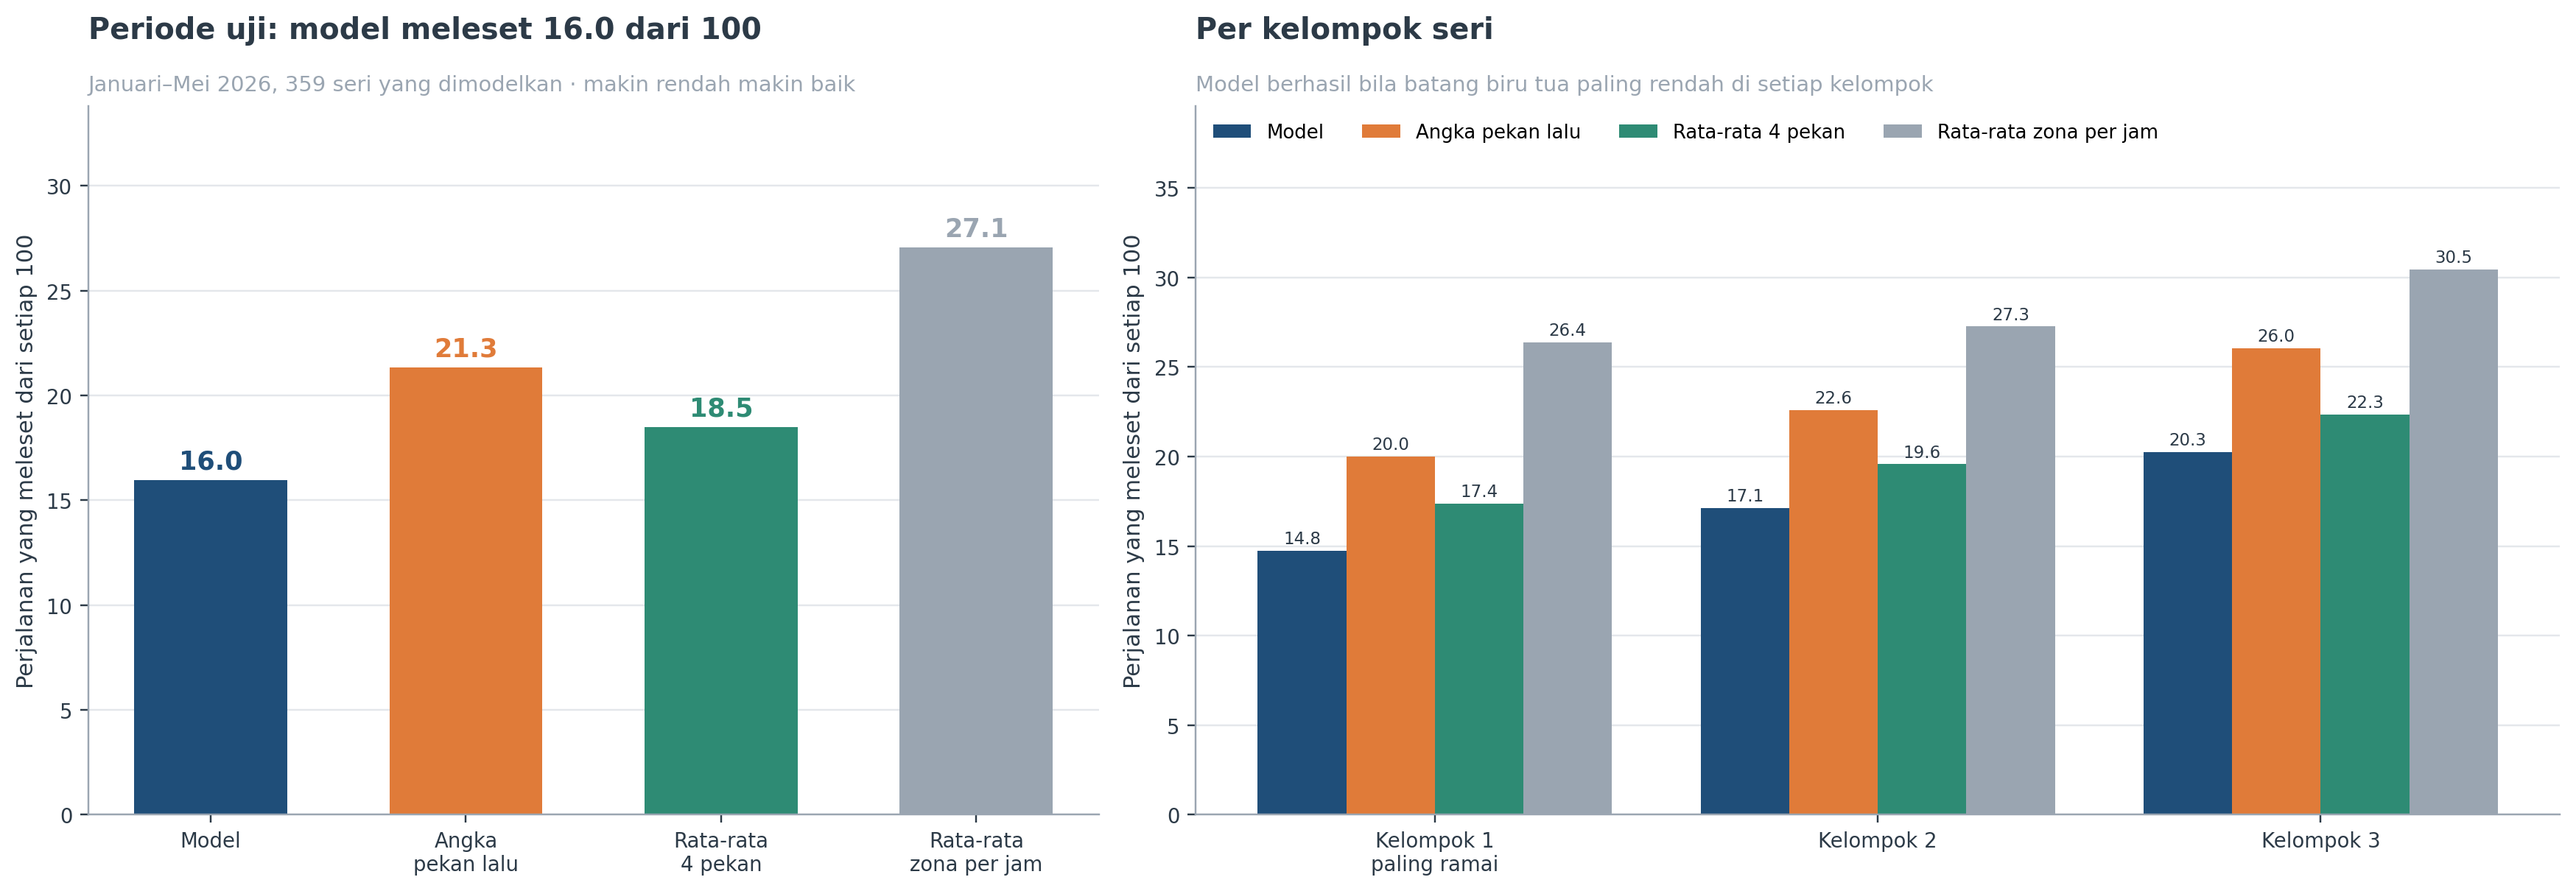

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1, 1.35]})
WARNA = {"Model": C["primary"], "Angka pekan lalu": C["secondary"],
         "Rata-rata 4 pekan": C["accent"], "Rata-rata zona per jam": C["muted"]}

ax = axes[0]
nilai = [ukur(uji["demand"], uji[k])["WMAPE"] for k in BANDING]
nama = list(BANDING.values())
ax.bar(range(len(nama)), nilai, color=[WARNA[n] for n in nama], width=0.6)
for i, v in enumerate(nilai):
    ax.text(i, v + max(nilai) * 0.02, f"{v:.1f}", ha="center", fontsize=11.5, fontweight="bold", color=WARNA[nama[i]])
ax.set_xticks(range(len(nama)))
ax.set_xticklabels(["Model", "Angka\npekan lalu", "Rata-rata\n4 pekan", "Rata-rata\nzona per jam"])
ax.set_ylim(0, max(nilai) * 1.25)
ax.set_ylabel("Perjalanan yang meleset dari setiap 100")
titled(ax, f"Periode uji: model meleset {nilai[0]:.1f} dari 100",
       "Januari–Mei 2026, 359 seri yang dimodelkan · makin rendah makin baik")
clean_axes(ax)

ax = axes[1]
lebar, xk = 0.2, np.arange(len(per_kelompok))
for j, n in enumerate(nama):
    v = per_kelompok[n].values
    ax.bar(xk + (j - 1.5) * lebar, v, width=lebar, color=WARNA[n], label=n)
    for xi, vi in zip(xk + (j - 1.5) * lebar, v):
        ax.text(xi, vi + 0.4, f"{vi:.1f}", ha="center", fontsize=7.5, color=C["text"])
ax.set_xticks(xk)
ax.set_xticklabels([f"{k}\n{'paling ramai' if i == 0 else ''}" for i, k in enumerate(per_kelompok.index)])
ax.set_ylim(0, per_kelompok[nama].values.max() * 1.3)
ax.set_ylabel("Perjalanan yang meleset dari setiap 100")
ax.legend(loc="upper left", ncol=4, fontsize=8.5)
titled(ax, "Per kelompok seri", "Model berhasil bila batang biru tua paling rendah di setiap kelompok")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca grafik Step 8**

**Kiri** — kesalahan model dan tiga pembanding pada Januari–Mei 2026. Tinggi batang adalah jumlah perjalanan yang meleset dari setiap 100.

**Kanan** — kesalahan yang sama, dipisah per kelompok seri. Kelompok 1 berisi seri paling ramai. Bila batang biru tua paling rendah di setiap kelompok, keunggulan model tidak hanya berasal dari seri ramai.

> **Hasil Step 8 — penilaian pada periode uji**

| Cara | WMAPE | Jam sibuk | Kurang tebak | Lebih tebak | Bias |
|---|---|---|---|---|---|
| **Model, dilatih ulang tiap bulan** | **15,98** | **15,83** | 8,69 | 7,30 | −1,4% |
| Model, dilatih sekali | 16,02 | 15,79 | 8,81 | 7,21 | −1,6% |
| Rata-rata 4 pekan | 18,49 | 18,04 | 9,34 | 9,15 | −0,2% |
| Angka pekan lalu | 21,34 | 20,94 | 10,99 | 10,36 | −0,6% |

**Temuan 1 — Kesalahan berkurang 14% dibanding pembanding terbaik.** Model meleset 15,98 dari 100, dibanding 18,49 untuk rata-rata 4 pekan, dan juga unggul di jam sibuk (15,83 vs 18,04). Ukuran keberhasilan rencana awal — mengalahkan Seasonal Naive (21,34) — terpenuhi dengan selisih 25%.

**Temuan 2 — Unggul di setiap kelompok dan hampir setiap pekan.**

| Kelompok seri | Model | Rata-rata 4 pekan | Pekan menang / setara / kalah |
|---|---|---|---|
| 1 | 14,8 | 17,4 | 12 / 10 / 0 |
| 2 | 17,1 | 19,6 | 13 / 9 / 0 |
| 3 | 20,2 | 22,3 | 13 / 7 / 2 |

Model juga lebih baik untuk kedua provider (Uber 14,8 vs 17,4; Lyft 19,3 vs 21,8) dan keempat kelompok jam zona.

**Temuan 3 — Model cenderung sedikit terlalu rendah.** Bias −1,4%, dan bagian kurang tebak (8,69) lebih besar dari lebih tebak (7,30). Arah ini sejalan dengan pertumbuhan permintaan yang terus berlangsung.

**Temuan 4 — Melatih ulang tiap bulan hampir tidak menambah akurasi.** Hanya 0,04 poin lebih baik. Dalam lima bulan, pola permintaan tidak berubah cukup besar untuk membutuhkan pelatihan ulang bulanan; melatih ulang tiap kuartal kemungkinan sudah cukup.

**Temuan 5 — Urutan kandidat pada periode uji sama dengan validasi.** LightGBM satu model tetap terbaik (16,02), disusul XGBoost (16,11), sedangkan "+ tren" turun ke urutan kelima (16,31). Pemilihan dari tiga periode validasi terbukti tepat.

---

# STEP 8B — Apakah Sisa Kesalahan Masih Berpola?

**Tujuan:** memeriksa apakah model sudah menangkap pola waktu, dengan menghitung ACF dari **sisa kesalahan** (kenyataan dikurangi perkiraan) pada periode uji.

**Cara interpretasi:**

| Lag | Bila ACF sisa kesalahan tinggi | Artinya |
|---|---|---|
| 1–24 jam | Wajar | Kesalahan jam ini mirip jam sebelumnya, karena model tidak boleh memakai data 7 hari terakhir |
| 168 jam (1 pekan) | Masalah | Pola mingguan belum tertangkap sepenuhnya |

Bila ACF sisa kesalahan pada lag 168 jauh lebih kecil daripada ACF permintaan pada lag 168, model sudah menangkap pola mingguan.

Periode uji, 359 seri dimodelkan:


,Kota: permintaan,Kota: sisa kesalahan,Rata-rata seri: permintaan,Rata-rata seri: sisa kesalahan
Lag,,,,
1 jam,0.918,0.917,0.853,0.618
2 jam,0.724,0.809,0.665,0.502
24 jam,0.772,0.215,0.704,0.246
168 jam,0.863,-0.093,0.789,-0.013
336 jam,0.805,-0.126,0.731,-0.034


Lag 168 jam, rata-rata seri: permintaan 0.79 -> sisa kesalahan -0.01


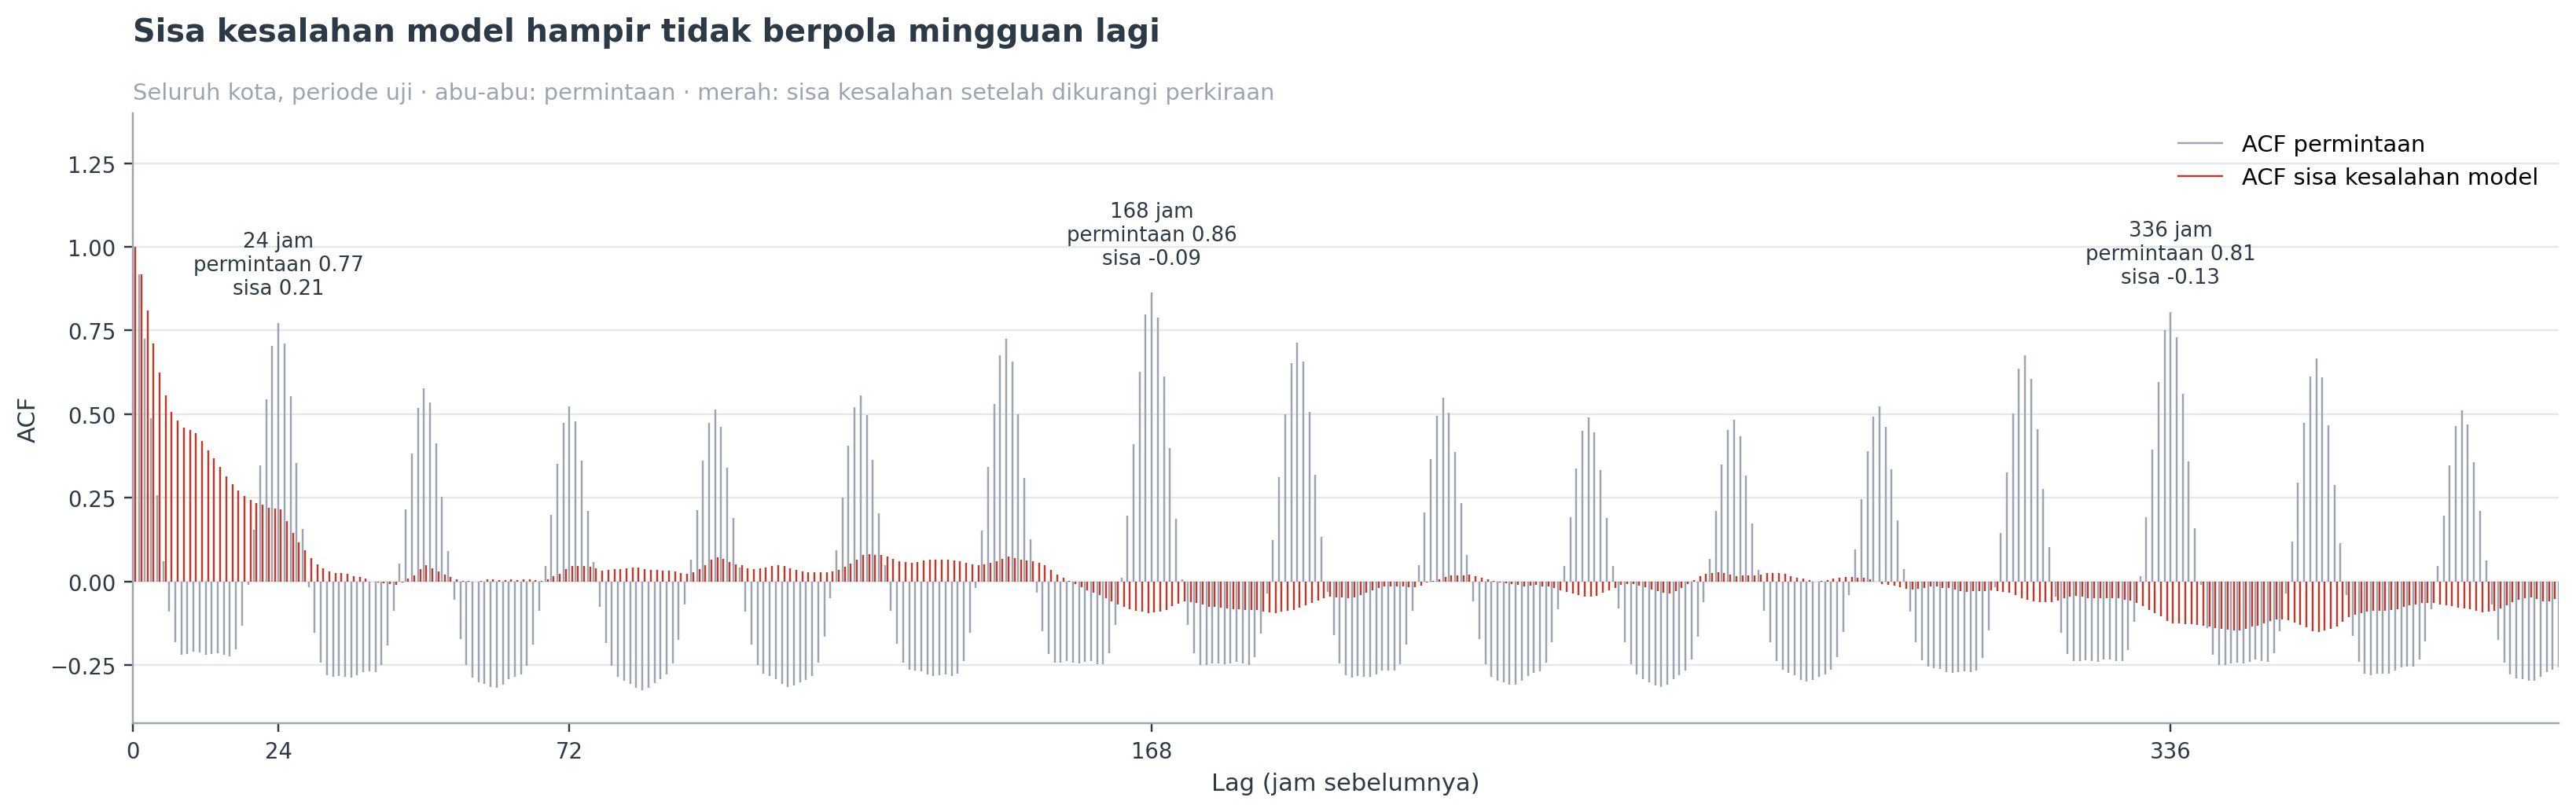

In [18]:
def acf_lag(x, lags):
    x = np.asarray(x, dtype=float); x = x - x.mean(); d = (x * x).sum()
    return np.array([(x[:-k] * x[k:]).sum() / d if d > 0 else np.nan for k in lags])


LAG_SISA = [1, 2, 24, 168, 336]
u = uji.sort_values(["provider", "zona", "jam"])

# Seluruh kota
kota_u = u.groupby("jam")[["demand", "perkiraan"]].sum()
acf_kota_dem = acf(kota_u["demand"], 400)
acf_kota_sisa = acf(kota_u["demand"] - kota_u["perkiraan"], 400)

# Rata-rata per seri, ditimbang jumlah perjalanan
per_seri = []
for (p, z), g in u.groupby(["provider", "zona"], observed=True):
    if g["demand"].sum() > 0:
        per_seri.append((g["demand"].sum(), acf_lag(g["demand"], LAG_SISA),
                         acf_lag(g["demand"] - g["perkiraan"], LAG_SISA)))
bobot = np.array([b for b, _, _ in per_seri])
rata_dem = np.nansum([b * a for b, a, _ in per_seri], axis=0) / bobot.sum()
rata_sisa = np.nansum([b * s for b, _, s in per_seri], axis=0) / bobot.sum()

tabel_sisa = pd.DataFrame({
    "Kota: permintaan": acf_kota_dem[LAG_SISA], "Kota: sisa kesalahan": acf_kota_sisa[LAG_SISA],
    "Rata-rata seri: permintaan": rata_dem, "Rata-rata seri: sisa kesalahan": rata_sisa,
}, index=[f"{k} jam" for k in LAG_SISA])
tabel_sisa.index.name = "Lag"
print(f"Periode uji, {len(per_seri)} seri dimodelkan:")
display(tabel_sisa.style.format("{:.3f}"))
print(f"Lag 168 jam, rata-rata seri: permintaan {rata_dem[3]:.2f} -> sisa kesalahan {rata_sisa[3]:.2f}")

fig, ax = plt.subplots(figsize=(15, 4.8))
lg = np.arange(401)
ax.vlines(lg, 0, acf_kota_dem, color=C["muted"], linewidth=0.8, label="ACF permintaan")
ax.vlines(lg + 0.4, 0, acf_kota_sisa, color=C["alert"], linewidth=0.8, label="ACF sisa kesalahan model")
for k in [24, 168, 336]:
    ax.annotate(f"{k} jam\npermintaan {acf_kota_dem[k]:.2f}\nsisa {acf_kota_sisa[k]:.2f}", xy=(k, acf_kota_dem[k]),
                xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8.5, color=C["text"])
ax.set_xlim(0, 400)
ax.set_ylim(min(acf_kota_dem.min(), acf_kota_sisa.min()) - 0.1, 1.4)
ax.set_xticks([0, 24, 72, 168, 336])
ax.set_xlabel("Lag (jam sebelumnya)")
ax.set_ylabel("ACF")
ax.legend(loc="upper right")
titled(ax, "Sisa kesalahan model hampir tidak berpola mingguan lagi",
       "Seluruh kota, periode uji · abu-abu: permintaan · merah: sisa kesalahan setelah dikurangi perkiraan")
clean_axes(ax)
plt.tight_layout()
plt.show()

> **Cara membaca Step 8B**

Garis abu-abu adalah ACF permintaan: tinggi di lag 24 dan 168 karena permintaan berpola harian dan mingguan. Garis merah adalah ACF sisa kesalahan model. Bila garis merah di lag 168 jauh lebih rendah dari abu-abu, pola mingguan sudah diambil oleh model. Garis merah yang masih tinggi di lag 1–24 wajar: model memang tidak boleh memakai data 7 hari terakhir.

> **Hasil Step 8B — sisa kesalahan**

| Lag | Kota: permintaan | Kota: sisa kesalahan | Rata-rata seri: permintaan | Rata-rata seri: sisa kesalahan |
|---|---|---|---|---|
| 1 jam | 0,918 | 0,917 | 0,853 | 0,616 |
| 24 jam | 0,772 | 0,217 | 0,704 | 0,245 |
| 168 jam | 0,863 | −0,090 | 0,789 | −0,017 |

**Temuan 1 — Pola mingguan sudah tertangkap sepenuhnya.** Di lag 168 jam, autokorelasi turun dari 0,79 menjadi −0,02 di tingkat seri. Tidak ada pola mingguan yang tertinggal di sisa kesalahan.

**Temuan 2 — Pola harian sebagian besar tertangkap.** Di lag 24 jam turun dari 0,70 menjadi 0,25.

**Temuan 3 — Kesalahan pada jam berurutan saling mirip.** Di lag 1 jam, sisa kesalahan masih 0,62 di tingkat seri: bila model meleset jam ini, kemungkinan besar meleset ke arah yang sama jam berikutnya. Ini tidak dapat diperbaiki tanpa memakai data jam-jam terakhir, yang tidak boleh untuk perkiraan 7 hari.

---

# STEP 9 — Batas Bawah dan Batas Atas

**Tujuan:** membuat batas bawah dan batas atas di sekitar perkiraan, lalu memeriksa apakah batas itu benar-benar mengapit sekitar 80% kenyataan.

**Cara membuatnya:** dari tiga periode validasi (April–Desember 2025), dihitung seberapa jauh kenyataan biasanya menyimpang dari perkiraan. Batas bawah adalah penyimpangan yang hanya dilampaui ke bawah 1 dari 10 kali, batas atas yang hanya dilampaui ke atas 1 dari 10 kali. Penyimpangan ini lalu diterapkan pada perkiraan baru.

| Tingkat | Cara | Alasan |
|---|---|---|
| Seri per jam | Penyimpangan dibagi akar perkiraan, dihitung per kelompok seri **dan per waktu hari** (dini hari, pagi, siang, sore–malam) | Penyimpangan jam sepi dan jam ramai berbeda skala, dan penyimpangan dini hari berbeda dari jam sibuk |
| Kota per jam, kota per hari, zona per hari | Rasio kenyataan terhadap perkiraan, dihitung pada tingkat itu sendiri | Menjumlahkan batas seri akan menghasilkan rentang yang terlalu lebar |

Seri di luar cakupan memakai rata-rata 4 pekan sebagai perkiraan, dengan batas yang dikalibrasi terpisah.

**Cara interpretasi:** cakupan pada periode uji seharusnya sekitar 80%. Jauh di bawah 80% berarti batas terlalu sempit; jauh di atas berarti terlalu lebar.

In [19]:
def waktu_hari(jam):
    h = jam.dt.hour
    return pd.Series(np.select([h < 6, h < 12, h < 17], ["dini hari", "pagi", "siang"], "sore–malam"), index=jam.index)


def gabung(df_model, df_luar, kolom_luar="tebak_rata_4pekan"):
    '''Perkiraan seluruh 524 seri: model untuk seri dimodelkan, rata-rata 4 pekan untuk sisanya.'''
    a = df_model[["provider", "zona", "jam", "demand", "perkiraan", "kelompok_seri"]].copy()
    a["kelompok_interval"] = "Kelompok " + a["kelompok_seri"].astype(str) + " · " + waktu_hari(a["jam"])
    b = df_luar[["provider", "zona", "jam", "demand", kolom_luar, "kelompok_seri"]].rename(columns={kolom_luar: "perkiraan"})
    b["kelompok_interval"] = "Di luar cakupan · " + waktu_hari(b["jam"])
    g = pd.concat([a, b], ignore_index=True)
    for k in ["provider", "kelompok_seri"]:
        g[k] = g[k].astype(str)
    g["tanggal"] = g["jam"].dt.normalize()
    return g


oof["perkiraan"] = oof[f"tebak_{TERPILIH}"]
gab_val, gab_uji = gabung(oof, luar_hist), gabung(uji, luar_uji)

# ---------- Tingkat seri per jam ----------
def kalibrasi_seri(g):
    r = (g["demand"] - g["perkiraan"]) / np.sqrt(g["perkiraan"] + 1)
    return r.groupby(g["kelompok_interval"]).quantile([Q_BAWAH, Q_ATAS]).unstack()


def batas_seri(g, q):
    s = np.sqrt(g["perkiraan"] + 1)
    g["batas_bawah"] = np.clip(g["perkiraan"] + g["kelompok_interval"].map(q[Q_BAWAH]) * s, 0, None)
    g["batas_atas"] = g["perkiraan"] + g["kelompok_interval"].map(q[Q_ATAS]) * s
    return g


# ---------- Tingkat agregat ----------
TINGKAT = {"Kota per jam": ["jam"], "Kota per hari": ["tanggal"], "Zona per hari": ["zona", "tanggal"]}


def agregat(g, kunci):
    return g.groupby(kunci, observed=True)[["demand", "perkiraan"]].sum()


def kalibrasi_agregat(g, kunci):
    a = agregat(g, kunci)
    a = a[a["perkiraan"] >= 1]
    return (a["demand"] / a["perkiraan"]).quantile([Q_BAWAH, Q_ATAS])


def batas_agregat(a, q):
    a["batas_bawah"], a["batas_atas"] = a["perkiraan"] * q[Q_BAWAH], a["perkiraan"] * q[Q_ATAS]
    return a


def nilai_batas(y, lo, hi, p):
    return {"Cakupan": ((y >= lo) & (y <= hi)).mean() * 100,
            "Di bawah batas bawah": (y < lo).mean() * 100,
            "Di atas batas atas": (y > hi).mean() * 100,
            "Lebar rata-rata (% perkiraan)": ((hi - lo).sum() / p.sum()) * 100}


Q_SERI = kalibrasi_seri(gab_val)
Q_AGR = {n: kalibrasi_agregat(gab_val, k) for n, k in TINGKAT.items()}

gab_uji = batas_seri(gab_uji, Q_SERI)
cek = {"Seri per jam": nilai_batas(gab_uji["demand"], gab_uji["batas_bawah"], gab_uji["batas_atas"], gab_uji["perkiraan"])}
AGR_UJI = {}
for n, k in TINGKAT.items():
    a = batas_agregat(agregat(gab_uji, k), Q_AGR[n])
    AGR_UJI[n] = a
    cek[n] = nilai_batas(a["demand"], a["batas_bawah"], a["batas_atas"], a["perkiraan"])

print("Penyimpangan dari validasi, tingkat seri per jam (per akar perkiraan), 5 kelompok pertama:")
display(Q_SERI.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).head().style.format("{:+.2f}"))
print("Rasio kenyataan / perkiraan dari validasi, tingkat agregat:")
display(pd.DataFrame(Q_AGR).T.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).style.format("{:.3f}"))
print("Periode uji: apakah batas mengapit sekitar 80% kenyataan?")
display(pd.DataFrame(cek).T.style.format("{:.1f}"))

per_waktu = gab_uji.assign(waktu=waktu_hari(gab_uji["jam"])).groupby("waktu").apply(
    lambda g: pd.Series(nilai_batas(g["demand"], g["batas_bawah"], g["batas_atas"], g["perkiraan"])))
print("Periode uji, seri per jam, per waktu hari:")
display(per_waktu.loc[["dini hari", "pagi", "siang", "sore–malam"]].style.format("{:.1f}"))

Penyimpangan dari validasi, tingkat seri per jam (per akar perkiraan), 5 kelompok pertama:


,bawah,atas
kelompok_interval,,
Di luar cakupan · dini hari,-1.06,+1.28
Di luar cakupan · pagi,-1.21,+1.39
Di luar cakupan · siang,-1.30,+1.52
Di luar cakupan · sore–malam,-1.33,+1.60
Kelompok 1 · dini hari,-2.06,+2.01


Rasio kenyataan / perkiraan dari validasi, tingkat agregat:


,bawah,atas
Kota per jam,0.926,1.091
Kota per hari,0.954,1.069
Zona per hari,0.897,1.130


Periode uji: apakah batas mengapit sekitar 80% kenyataan?


,Cakupan,Di bawah batas bawah,Di atas batas atas,Lebar rata-rata (% perkiraan)
Seri per jam,76.7,11.3,12.0,44.6
Kota per jam,71.0,11.1,17.9,16.5
Kota per hari,66.9,12.6,20.5,11.5
Zona per hari,72.4,12.3,15.3,23.3


Periode uji, seri per jam, per waktu hari:


,Cakupan,Di bawah batas bawah,Di atas batas atas,Lebar rata-rata (% perkiraan)
waktu,,,,
dini hari,79.0,9.8,11.2,55.3
pagi,75.3,11.7,13.0,42.5
siang,75.6,12.2,12.2,42.0
sore–malam,76.6,11.6,11.8,44.3


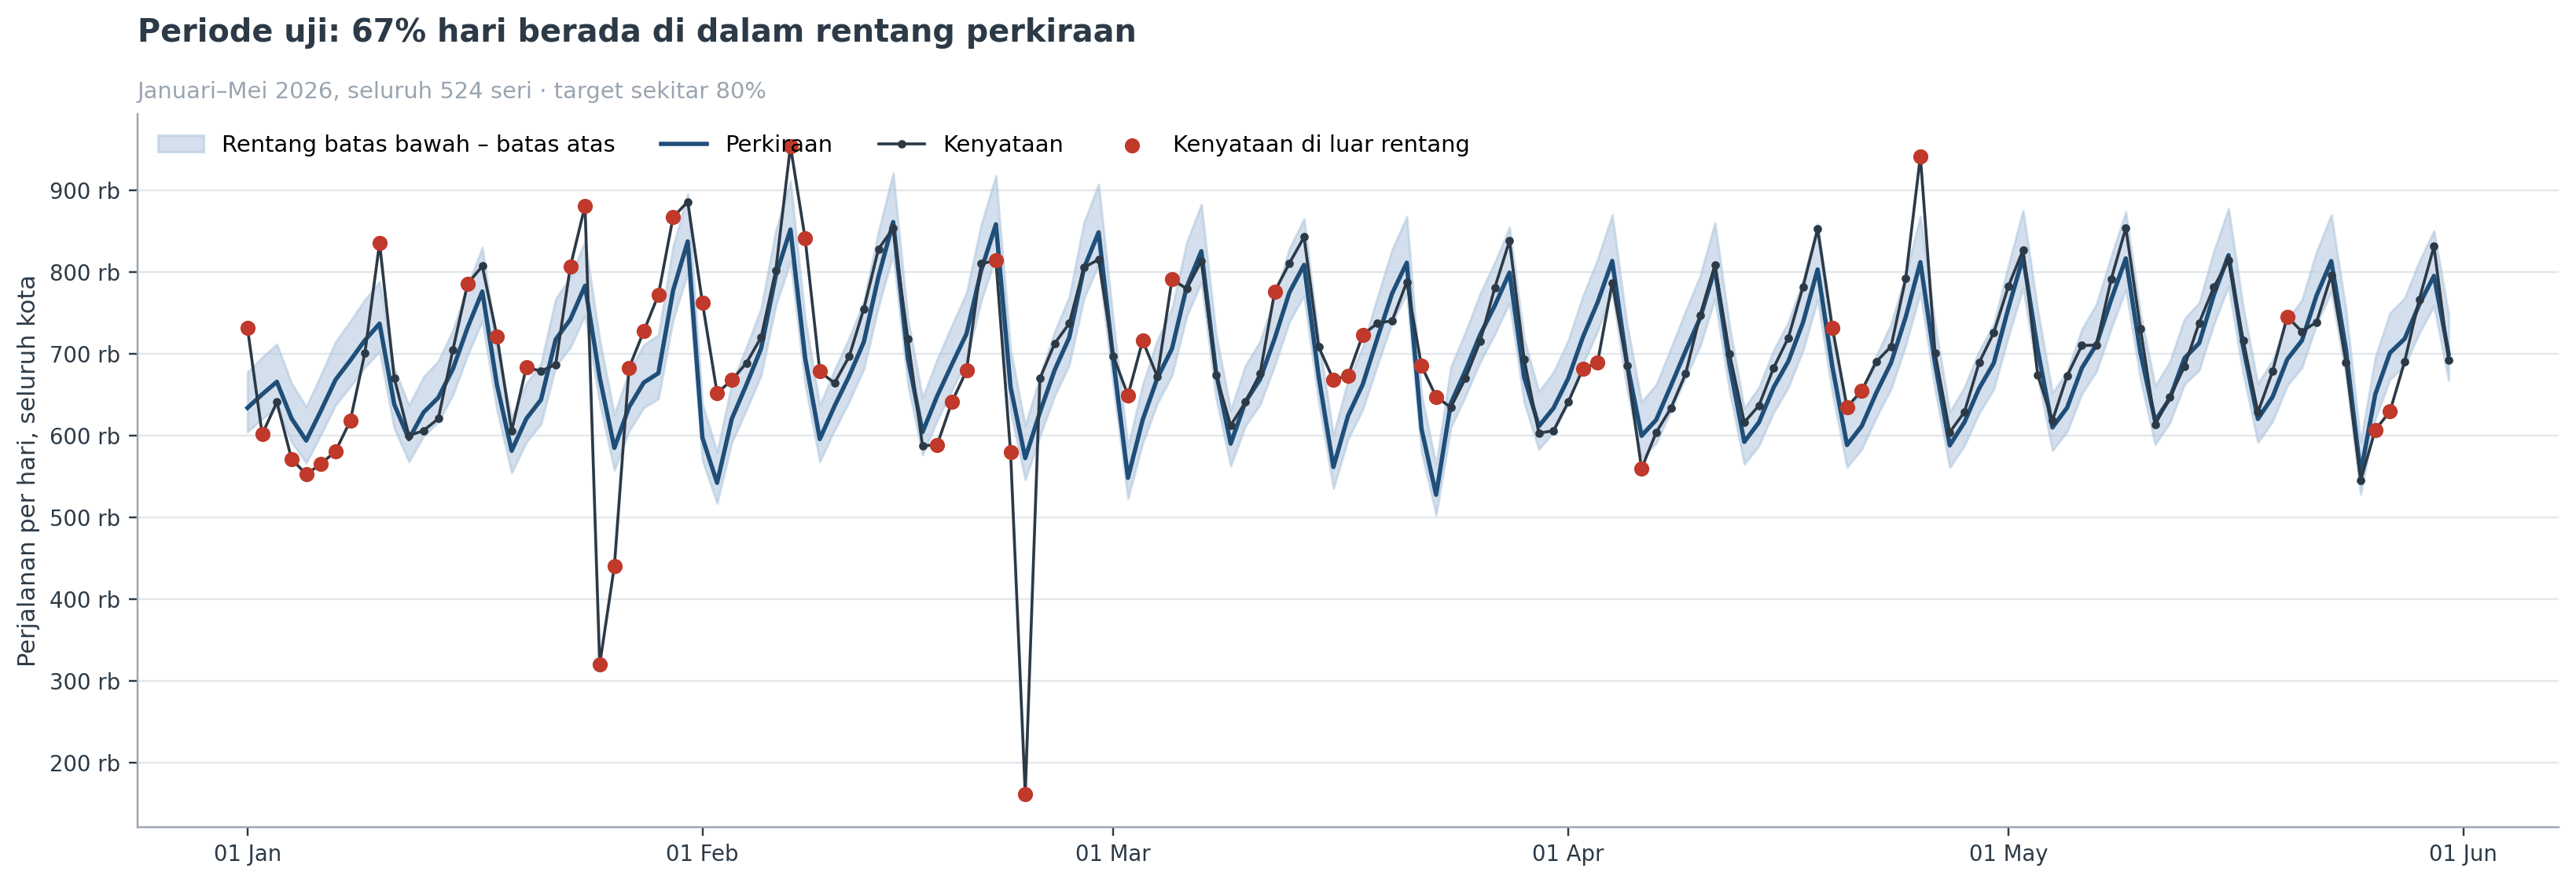

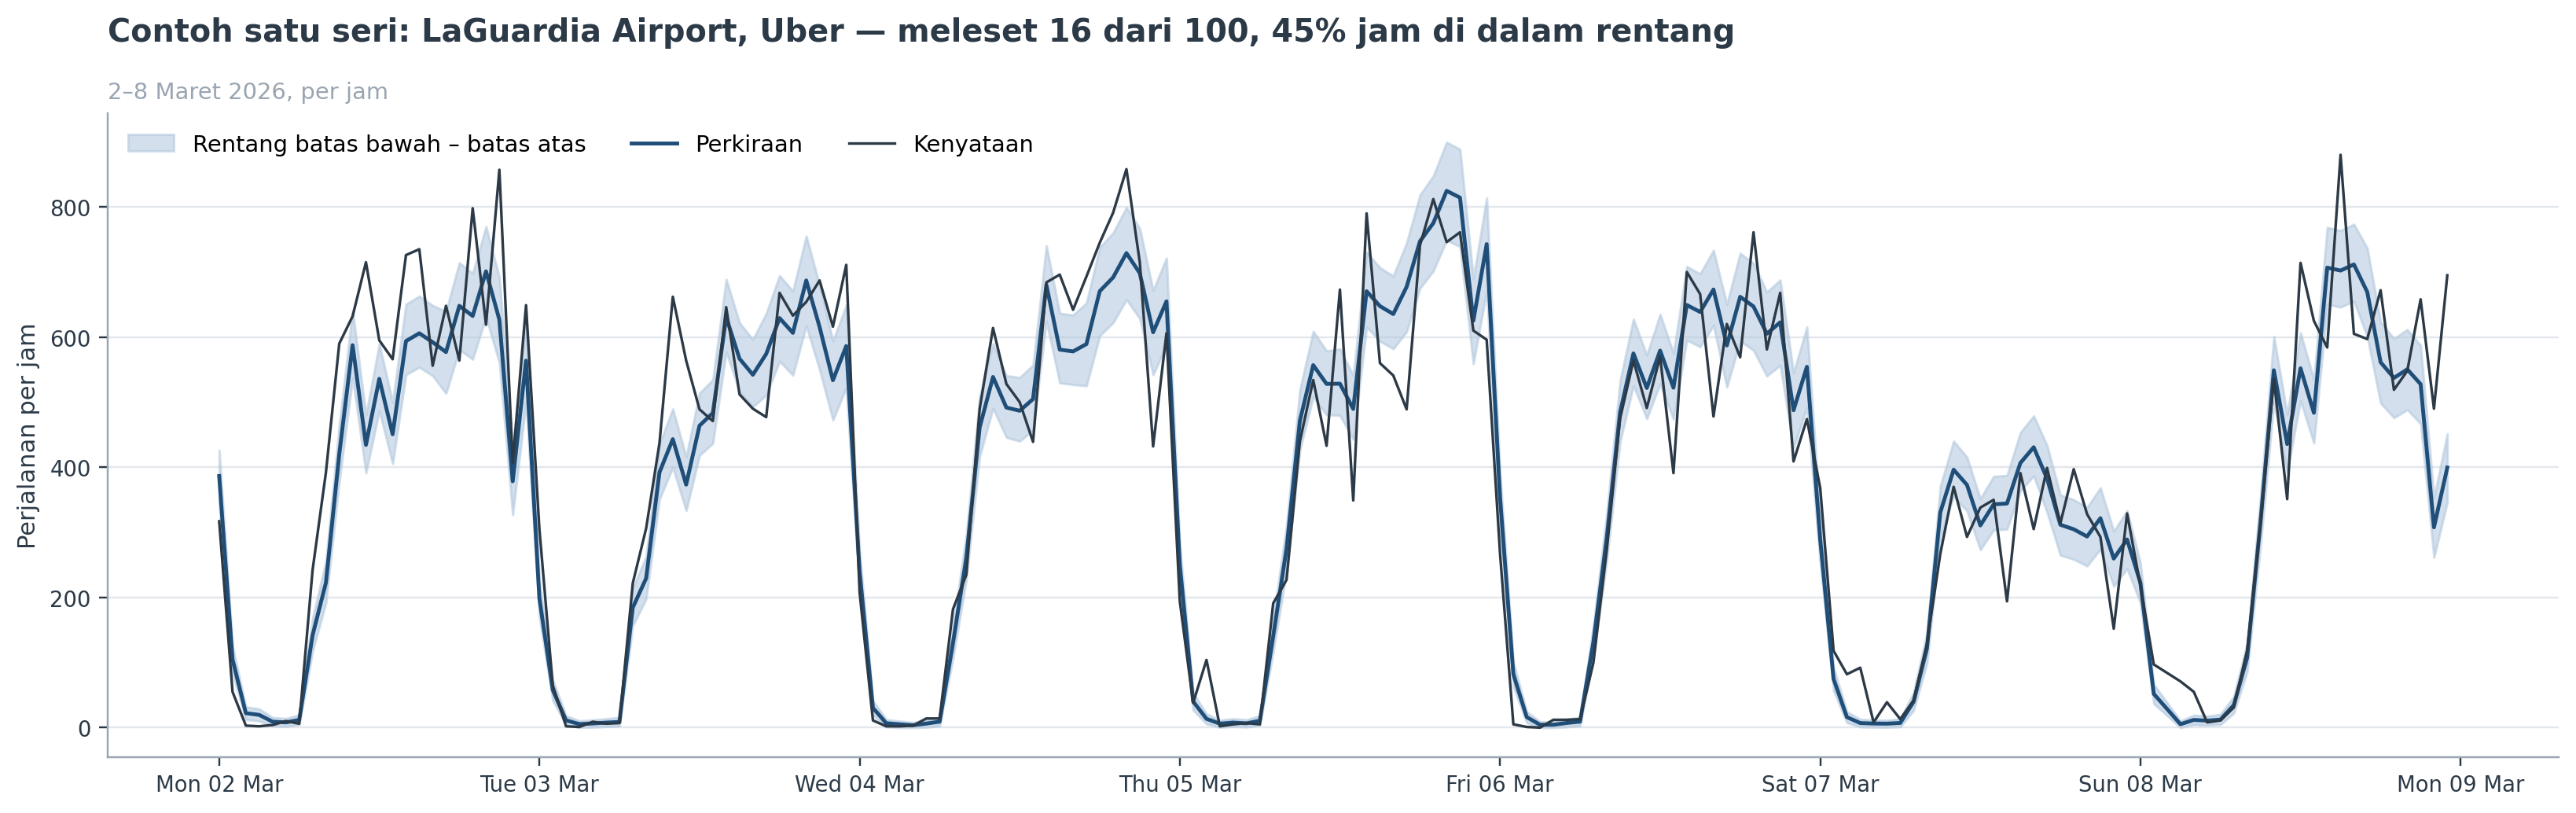

In [20]:
kh = AGR_UJI["Kota per hari"]
fig, ax = plt.subplots(figsize=(15, 5.2))
ax.fill_between(kh.index, kh["batas_bawah"], kh["batas_atas"], color=C["band"], alpha=0.55,
                label="Rentang batas bawah – batas atas")
ax.plot(kh.index, kh["perkiraan"], color=C["primary"], linewidth=1.8, label="Perkiraan")
ax.plot(kh.index, kh["demand"], color=C["text"], linewidth=1.2, marker="o", markersize=2.5, label="Kenyataan")
luar_rentang = kh[(kh["demand"] < kh["batas_bawah"]) | (kh["demand"] > kh["batas_atas"])]
ax.scatter(luar_rentang.index, luar_rentang["demand"], color=C["alert"], s=28, zorder=5,
           label="Kenyataan di luar rentang")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per hari, seluruh kota")
ax.legend(loc="upper left", ncol=4)
titled(ax, f"Periode uji: {cek['Kota per hari']['Cakupan']:.0f}% hari berada di dalam rentang perkiraan",
       "Januari–Mei 2026, seluruh 524 seri · target sekitar 80%")
clean_axes(ax)
plt.tight_layout()
plt.show()

# Contoh satu seri: LaGuardia Airport, Uber, pekan 2–8 Maret 2026
ct = gab_uji[(gab_uji["zona"] == 138) & (gab_uji["provider"] == "Uber")
             & (gab_uji["jam"] >= "2026-03-02") & (gab_uji["jam"] < "2026-03-09")].sort_values("jam")
if len(ct):
    fig, ax = plt.subplots(figsize=(15, 4.8))
    ax.fill_between(ct["jam"], ct["batas_bawah"], ct["batas_atas"], color=C["band"], alpha=0.55,
                    label="Rentang batas bawah – batas atas")
    ax.plot(ct["jam"], ct["perkiraan"], color=C["primary"], linewidth=1.6, label="Perkiraan")
    ax.plot(ct["jam"], ct["demand"], color=C["text"], linewidth=1.1, label="Kenyataan")
    ax.set_ylabel("Perjalanan per jam")
    ax.legend(loc="upper left", ncol=3)
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
    wm = ukur(ct["demand"], ct["perkiraan"])["WMAPE"]
    cak = ((ct["demand"] >= ct["batas_bawah"]) & (ct["demand"] <= ct["batas_atas"])).mean() * 100
    titled(ax, f"Contoh satu seri: LaGuardia Airport, Uber — meleset {wm:.0f} dari 100, {cak:.0f}% jam di dalam rentang",
           "2–8 Maret 2026, per jam")
    clean_axes(ax)
    plt.tight_layout()
    plt.show()

> **Cara membaca grafik Step 9**

Step 9 adalah **ujian** untuk rentang perkiraan: model berpura-pura tidak tahu Januari–Mei 2026, lalu perkiraannya dibandingkan dengan kenyataan.

**Grafik atas** — setiap titik adalah satu hari, seluruh kota dijumlah. Garis biru adalah perkiraan, area biru muda adalah rentang dari batas bawah sampai batas atas, garis gelap adalah kenyataan. Titik merah adalah hari ketika kenyataan keluar dari rentang. Bila rentang dibuat dengan benar, sekitar 8 dari 10 hari berada di dalam area biru muda.

Hari yang anjlok sangat dalam — misalnya tinggal seperempat dari hari biasa — tidak dapat diperkirakan tanpa data cuaca atau kejadian. Karena model memakai angka pekan lalu, hari seperti itu juga menarik perkiraan **sepekan sesudahnya** ke bawah.

**Grafik bawah** — satu seri contoh, LaGuardia Airport untuk Uber, jam per jam selama satu pekan, dengan cara baca yang sama.

**Tabel cakupan** — untuk setiap tingkat (seri per jam, kota per jam, kota per hari, zona per hari): persen kenyataan di dalam rentang, di bawah batas bawah, di atas batas atas, dan lebar rentang dibanding perkiraan.

> **Hasil Step 9 — rentang dari periode validasi**

| Tingkat | Cakupan pada Januari–Mei | Lebar rentang |
|---|---|---|
| Seri per jam | 76,6% | 44,5% dari perkiraan |
| Kota per jam | 70,9% | 16,5% |
| Kota per hari | 68,2% | 11,7% |
| Zona per hari | 72,5% | 23,3% |

**Temuan 1 — Rentang dari periode validasi saja terlalu sempit.** Semua tingkat di bawah 80%, paling jauh di tingkat kota per hari. Periode uji berisi hari-hari anjlok ekstrem di Januari–Februari yang tidak ada di periode validasi.

**Temuan 2 — Kalibrasi per waktu hari membuat cakupan merata.** Di tingkat seri per jam, cakupan dini hari, pagi, siang, dan sore–malam berada di kisaran yang sama (75–79%). Tanpa pemisahan per waktu, jam sibuk dan dini hari bisa punya cakupan sangat berbeda.

Kalibrasi yang dipakai untuk perkiraan Juni diperbaiki di Step 9B.

---

# STEP 9B — Kalibrasi Akhir dan Uji Bergulir Rentang

**Tujuan:** menentukan rentang untuk perkiraan Juni, dan membuktikan seberapa dapat dipercaya rentang itu.

**Masalah pada cara sebelumnya:** rentang hanya diuji pada April–Mei, yaitu sekitar 61 hari untuk tingkat kota per hari. Dengan sampel sekecil itu, satu hari yang meleset langsung menggeser cakupan hampir 2 poin, sehingga hasilnya berayun: 68% pada seluruh periode uji, tetapi 90% pada April–Mei saja.

**Cara sekarang — uji bergulir per bulan:** untuk setiap bulan Januari sampai Mei 2026, rentang dikalibrasi dari semua kesalahan sebelum bulan itu, lalu diperiksa pada bulan tersebut. Hasil kelima bulan digabung, sehingga cakupan dinilai pada sekitar 150 hari, bukan 61. Cara ini juga meniru pemakaian sebenarnya: setiap bulan rentang diperbarui dengan data terbaru.

**Batas kewajaran:** karena sampelnya terbatas, cakupan tidak akan tepat 80%. Untuk kota per hari, dengan sekitar 150 hari, cakupan antara kira-kira 74% dan 86% masih wajar secara statistik. Untuk tingkat lain dipakai toleransi praktis 78–82%, karena jam-jam dan seri-seri saling berkaitan sehingga rumus statistik biasa akan memberi batas yang terlalu sempit.

**Rentang akhir untuk Juni** dikalibrasi dari seluruh 14 bulan (April 2025 – Mei 2026): tebakan validasi dari model yang belum melihat periode itu, dan tebakan uji dari model yang dilatih ulang tiap bulan.

In [21]:
def hitung_masuk(g, q_s, q_a):
    # Jumlah kenyataan yang berada di dalam rentang, dan jumlah seluruhnya, per tingkat
    g = batas_seri(g.copy(), q_s)
    m = (g["demand"] >= g["batas_bawah"]) & (g["demand"] <= g["batas_atas"])
    hasil = {"Seri per jam": (int(m.sum()), int(m.size))}
    for n, k in TINGKAT.items():
        a = batas_agregat(agregat(g, k), q_a[n])
        m = (a["demand"] >= a["batas_bawah"]) & (a["demand"] <= a["batas_atas"])
        hasil[n] = (int(m.sum()), int(m.size))
    return hasil


def cek_bulanan(gab_hist, gab_u):
    # Uji bergulir: setiap bulan uji, kalibrasi dari semua kesalahan sebelum bulan itu
    batas = pd.date_range(TEST_MULAI, PERKIRAAN_MULAI, freq="MS")
    baris, total = [], {}
    for m0, m1 in zip(batas[:-1], batas[1:]):
        kal = pd.concat([gab_hist, gab_u[gab_u["jam"] < m0]], ignore_index=True)
        tes = gab_u[(gab_u["jam"] >= m0) & (gab_u["jam"] < m1)]
        h = hitung_masuk(tes, kalibrasi_seri(kal), {n: kalibrasi_agregat(kal, k) for n, k in TINGKAT.items()})
        baris.append({"Bulan": f"{m0:%b %Y}", **{n: s / z * 100 for n, (s, z) in h.items()}})
        for n, (s, z) in h.items():
            total[n] = (total.get(n, (0, 0))[0] + s, total.get(n, (0, 0))[1] + z)
        del kal
    tabel = pd.DataFrame(baris).set_index("Bulan")
    gabungan = {n: s / z * 100 for n, (s, z) in total.items()}
    tabel.loc["Gabungan Jan–Mei"] = gabungan
    # Batas wajar statistik hanya untuk kota per hari: hari-hari cukup saling lepas.
    # Jam dan seri saling berkaitan, sehingga rumus ini akan memberi batas yang terlalu sempit.
    z_hari = total["Kota per hari"][1]
    tabel.loc["Batas wajar ±"] = {n: (1.96 * np.sqrt(0.8 * 0.2 / z_hari) * 100 if n == "Kota per hari" else np.nan)
                                  for n in total}
    return tabel, gabungan, {n: z for n, (s, z) in total.items()}


banding, CAKUPAN_7, N_CEK = cek_bulanan(gab_val, gab_uji)
print("Uji bergulir per bulan: cakupan rentang (target 80%)")
display(banding.style.format("{:.1f}", na_rep="—"))
lo = 80 - banding.loc["Batas wajar ±", "Kota per hari"]
hi = 80 + banding.loc["Batas wajar ±", "Kota per hari"]
print(f"Kota per hari : gabungan {CAKUPAN_7['Kota per hari']:.1f}% dari {N_CEK['Kota per hari']} hari — "
      f"{'dalam' if lo <= CAKUPAN_7['Kota per hari'] <= hi else 'DI LUAR'} batas wajar {lo:.1f}–{hi:.1f}%")
for n in ["Seri per jam", "Kota per jam", "Zona per hari"]:
    print(f"{n:14}: gabungan {CAKUPAN_7[n]:.1f}% — {'dalam' if abs(CAKUPAN_7[n] - 80) <= 2 else 'DI LUAR'} "
          f"toleransi praktis 78–82%")

# Kalibrasi akhir untuk perkiraan Juni: April 2025 – Mei 2026
kal_akhir = pd.concat([gab_val, gab_uji], ignore_index=True)
Q_SERI_AKHIR = kalibrasi_seri(kal_akhir)
Q_AGR_AKHIR = {n: kalibrasi_agregat(kal_akhir, k) for n, k in TINGKAT.items()}
del kal_akhir; gc.collect()
print("\nRasio kenyataan / perkiraan, kalibrasi akhir (dipakai untuk Juni):")
display(pd.DataFrame(Q_AGR_AKHIR).T.rename(columns={Q_BAWAH: "bawah", Q_ATAS: "atas"}).style.format("{:.3f}"))

Uji bergulir per bulan: cakupan rentang (target 80%)


,Seri per jam,Kota per jam,Kota per hari,Zona per hari
Bulan,,,,
Jan 2026,72.1,55.6,38.7,60.4
Feb 2026,74.6,68.3,64.3,64.5
Mar 2026,80.1,76.9,77.4,79.1
Apr 2026,80.2,82.6,86.7,84.0
May 2026,80.6,83.6,93.5,85.3
Gabungan Jan–Mei,77.6,73.4,72.2,74.8
Batas wajar ±,—,—,6.4,—


Kota per hari : gabungan 72.2% dari 151 hari — DI LUAR batas wajar 73.6–86.4%
Seri per jam  : gabungan 77.6% — DI LUAR toleransi praktis 78–82%
Kota per jam  : gabungan 73.4% — DI LUAR toleransi praktis 78–82%
Zona per hari : gabungan 74.8% — DI LUAR toleransi praktis 78–82%

Rasio kenyataan / perkiraan, kalibrasi akhir (dipakai untuk Juni):


,bawah,atas
Kota per jam,0.924,1.107
Kota per hari,0.950,1.084
Zona per hari,0.891,1.145


> **Cara membaca Step 9B**

**Tabel uji bergulir** — setiap baris adalah satu bulan uji; setiap kolom adalah persen kenyataan yang berada di dalam rentang pada tingkat itu. Baris "Gabungan Jan–Mei" adalah hasil kelima bulan digabung. Baris "Batas wajar ±" untuk kota per hari menunjukkan seberapa jauh cakupan boleh menyimpang dari 80% hanya karena jumlah hari terbatas. Untuk tingkat lain dipakai toleransi praktis 78–82%.

**Tabel rasio akhir** — rasio yang dipakai untuk perkiraan Juni. Misalnya kota per hari bawah 0,950 dan atas 1,086 berarti batas bawah 5% di bawah perkiraan dan batas atas 9% di atasnya.

> **Hasil Step 9B — uji bergulir rentang**

| Bulan | Seri per jam | Kota per jam | Kota per hari | Zona per hari |
|---|---|---|---|---|
| Januari 2026 | 72,1% | 55,6% | 38,7% | 60,4% |
| Februari 2026 | 74,6% | 68,3% | 64,3% | 64,5% |
| Maret 2026 | 80,1% | 76,9% | 77,4% | 79,1% |
| April 2026 | 80,2% | 82,6% | 86,7% | 84,0% |
| Mei 2026 | 80,6% | 83,6% | 93,5% | 85,3% |
| **Gabungan** | **77,6%** | **73,4%** | **72,2%** | **74,8%** |

**Temuan 1 — Rentang belum mencapai 80% secara gabungan.** Seri per jam 77,6% dan kota per hari 72,2%, sedikit di luar batas wajar 73,6–86,4%. Uji bergulir tidak menyelesaikan masalah, tetapi memperlihatkan penyebabnya.

**Temuan 2 — Penyebabnya perubahan kondisi, bukan ukuran sampel.** Januari (38,7%) dan Februari (64,3%) jauh di bawah target: keduanya berisi hari-hari anjlok ekstrem, sedangkan rentangnya dikalibrasi dari April–Desember 2025 yang tenang. Sebaliknya April (86,7%) dan Mei (93,5%) di atas target: kalibrasinya sudah memuat hari-hari ekstrem Januari–Februari, sehingga terlalu lebar untuk bulan normal. Satu rentang tidak dapat sekaligus tepat untuk bulan normal dan bulan berkejadian ekstrem.

**Temuan 3 — Rentang tingkat seri stabil dalam kondisi normal.** Sejak Maret, cakupan seri per jam berada di 80,1–80,6%. Masalah terutama muncul di tingkat kota, tempat satu kejadian ekstrem memengaruhi seluruh zona sekaligus.

**Temuan 4 — Rentang Juni cenderung lebar untuk hari normal.** Rentang akhir dikalibrasi dari 14 bulan, termasuk hari-hari ekstrem Januari–Februari. Untuk kota per hari, batas bawah 5,0% di bawah perkiraan dan batas atas 8,4% di atasnya. Bila Juni berjalan normal seperti April–Mei, sekitar 9 dari 10 hari diperkirakan berada di dalam rentang. Bila terjadi kejadian luar biasa, kenyataan dapat jauh di luar rentang.

**Kesimpulan:** perkiraan tengah dapat dipercaya. Rentang dibaca sebagai **kisaran kondisi normal**, bukan jaminan 80% dalam segala kondisi. Membedakan hari normal dari hari berkejadian ekstrem membutuhkan data cuaca dan kejadian, yang tidak tersedia di project ini.

---

# STEP 10 — Perkiraan 1–7 Juni 2026

**Tujuan:** membuat perkiraan untuk 7 hari setelah data terakhir.

**Cara:** model terpilih dilatih ulang pada **seluruh data sampai 31 Mei 2026**, dengan jumlah iterasi dari Step 7. Batas bawah dan atas memakai kalibrasi akhir dari Step 9B, yang dihitung dari Oktober 2025 – Mei 2026.

**Expected output:**
1. Tabel perkiraan seluruh kota per hari
2. Grafik perkiraan seluruh kota per jam, disambung dengan 2 pekan data terakhir
3. Tabel dan grafik 15 zona dengan perkiraan terbesar
4. Tabel lengkap per seri per jam, disimpan sebagai CSV

In [22]:
t0 = time.time()
semua_data = pd.concat([sejarah, uji[KOLOM_DATA]], ignore_index=True)
STATE_AKHIR = latih_ulang(STATE_TERPILIH, semua_data)
del semua_data; gc.collect()
depan["perkiraan"] = tebak(STATE_AKHIR, depan)
print(f"Latih ulang pada seluruh data selesai dalam {(time.time() - t0) / 60:.1f} menit")

gab_depan = batas_seri(gabung(depan, luar_depan), Q_SERI_AKHIR)
NAMA_HARI = {0: "Senin", 1: "Selasa", 2: "Rabu", 3: "Kamis", 4: "Jumat", 5: "Sabtu", 6: "Minggu"}

# ---------- Tabel 1: seluruh kota per hari ----------
kota_hari = batas_agregat(agregat(gab_depan, ["tanggal"]), Q_AGR_AKHIR["Kota per hari"]).reset_index()
kota_hari.insert(1, "hari", kota_hari["tanggal"].dt.dayofweek.map(NAMA_HARI))
kota_hari = kota_hari[["tanggal", "hari", "batas_bawah", "perkiraan", "batas_atas"]]
total = pd.DataFrame([{"tanggal": "Total 7 hari", "hari": "",
                       "batas_bawah": kota_hari["batas_bawah"].sum(), "perkiraan": kota_hari["perkiraan"].sum(),
                       "batas_atas": kota_hari["batas_atas"].sum()}])
tabel_kota = pd.concat([kota_hari.assign(tanggal=kota_hari["tanggal"].dt.strftime("%d %b %Y")), total], ignore_index=True)

# Pembanding: 7 hari yang sama sepekan sebelumnya
pekan_lalu = gab_uji[gab_uji["jam"] >= pd.Timestamp(PERKIRAAN_MULAI) - pd.Timedelta(days=7)]["demand"].sum()
print(f"\nPERKIRAAN SELURUH KOTA, 1–7 JUNI 2026 (Batas bawah dan atas: 8 dari 10 hari berada di antaranya)")
print(f"Kenyataan 25–31 Mei 2026 sebagai pembanding: {pekan_lalu:,.0f} perjalanan\n")
tabel_kota.style.format({"batas_bawah": "{:,.0f}", "perkiraan": "{:,.0f}", "batas_atas": "{:,.0f}"}) \
    .hide(axis="index")

Latih ulang pada seluruh data selesai dalam 2.9 menit

PERKIRAAN SELURUH KOTA, 1–7 JUNI 2026 (Batas bawah dan atas: 8 dari 10 hari berada di antaranya)
Kenyataan 25–31 Mei 2026 sebagai pembanding: 4,760,289 perjalanan



tanggal,hari,batas_bawah,perkiraan,batas_atas
01 Jun 2026,Senin,"552,267","581,448","630,398"
02 Jun 2026,Selasa,"617,578","650,209","704,949"
03 Jun 2026,Rabu,"647,069","681,259","738,612"
04 Jun 2026,Kamis,"672,617","708,157","767,775"
05 Jun 2026,Jumat,"722,931","761,130","825,207"
06 Jun 2026,Sabtu,"773,564","814,437","883,002"
07 Jun 2026,Minggu,"659,320","694,157","752,596"
Total 7 hari,,"4,645,346","4,890,798","5,302,539"


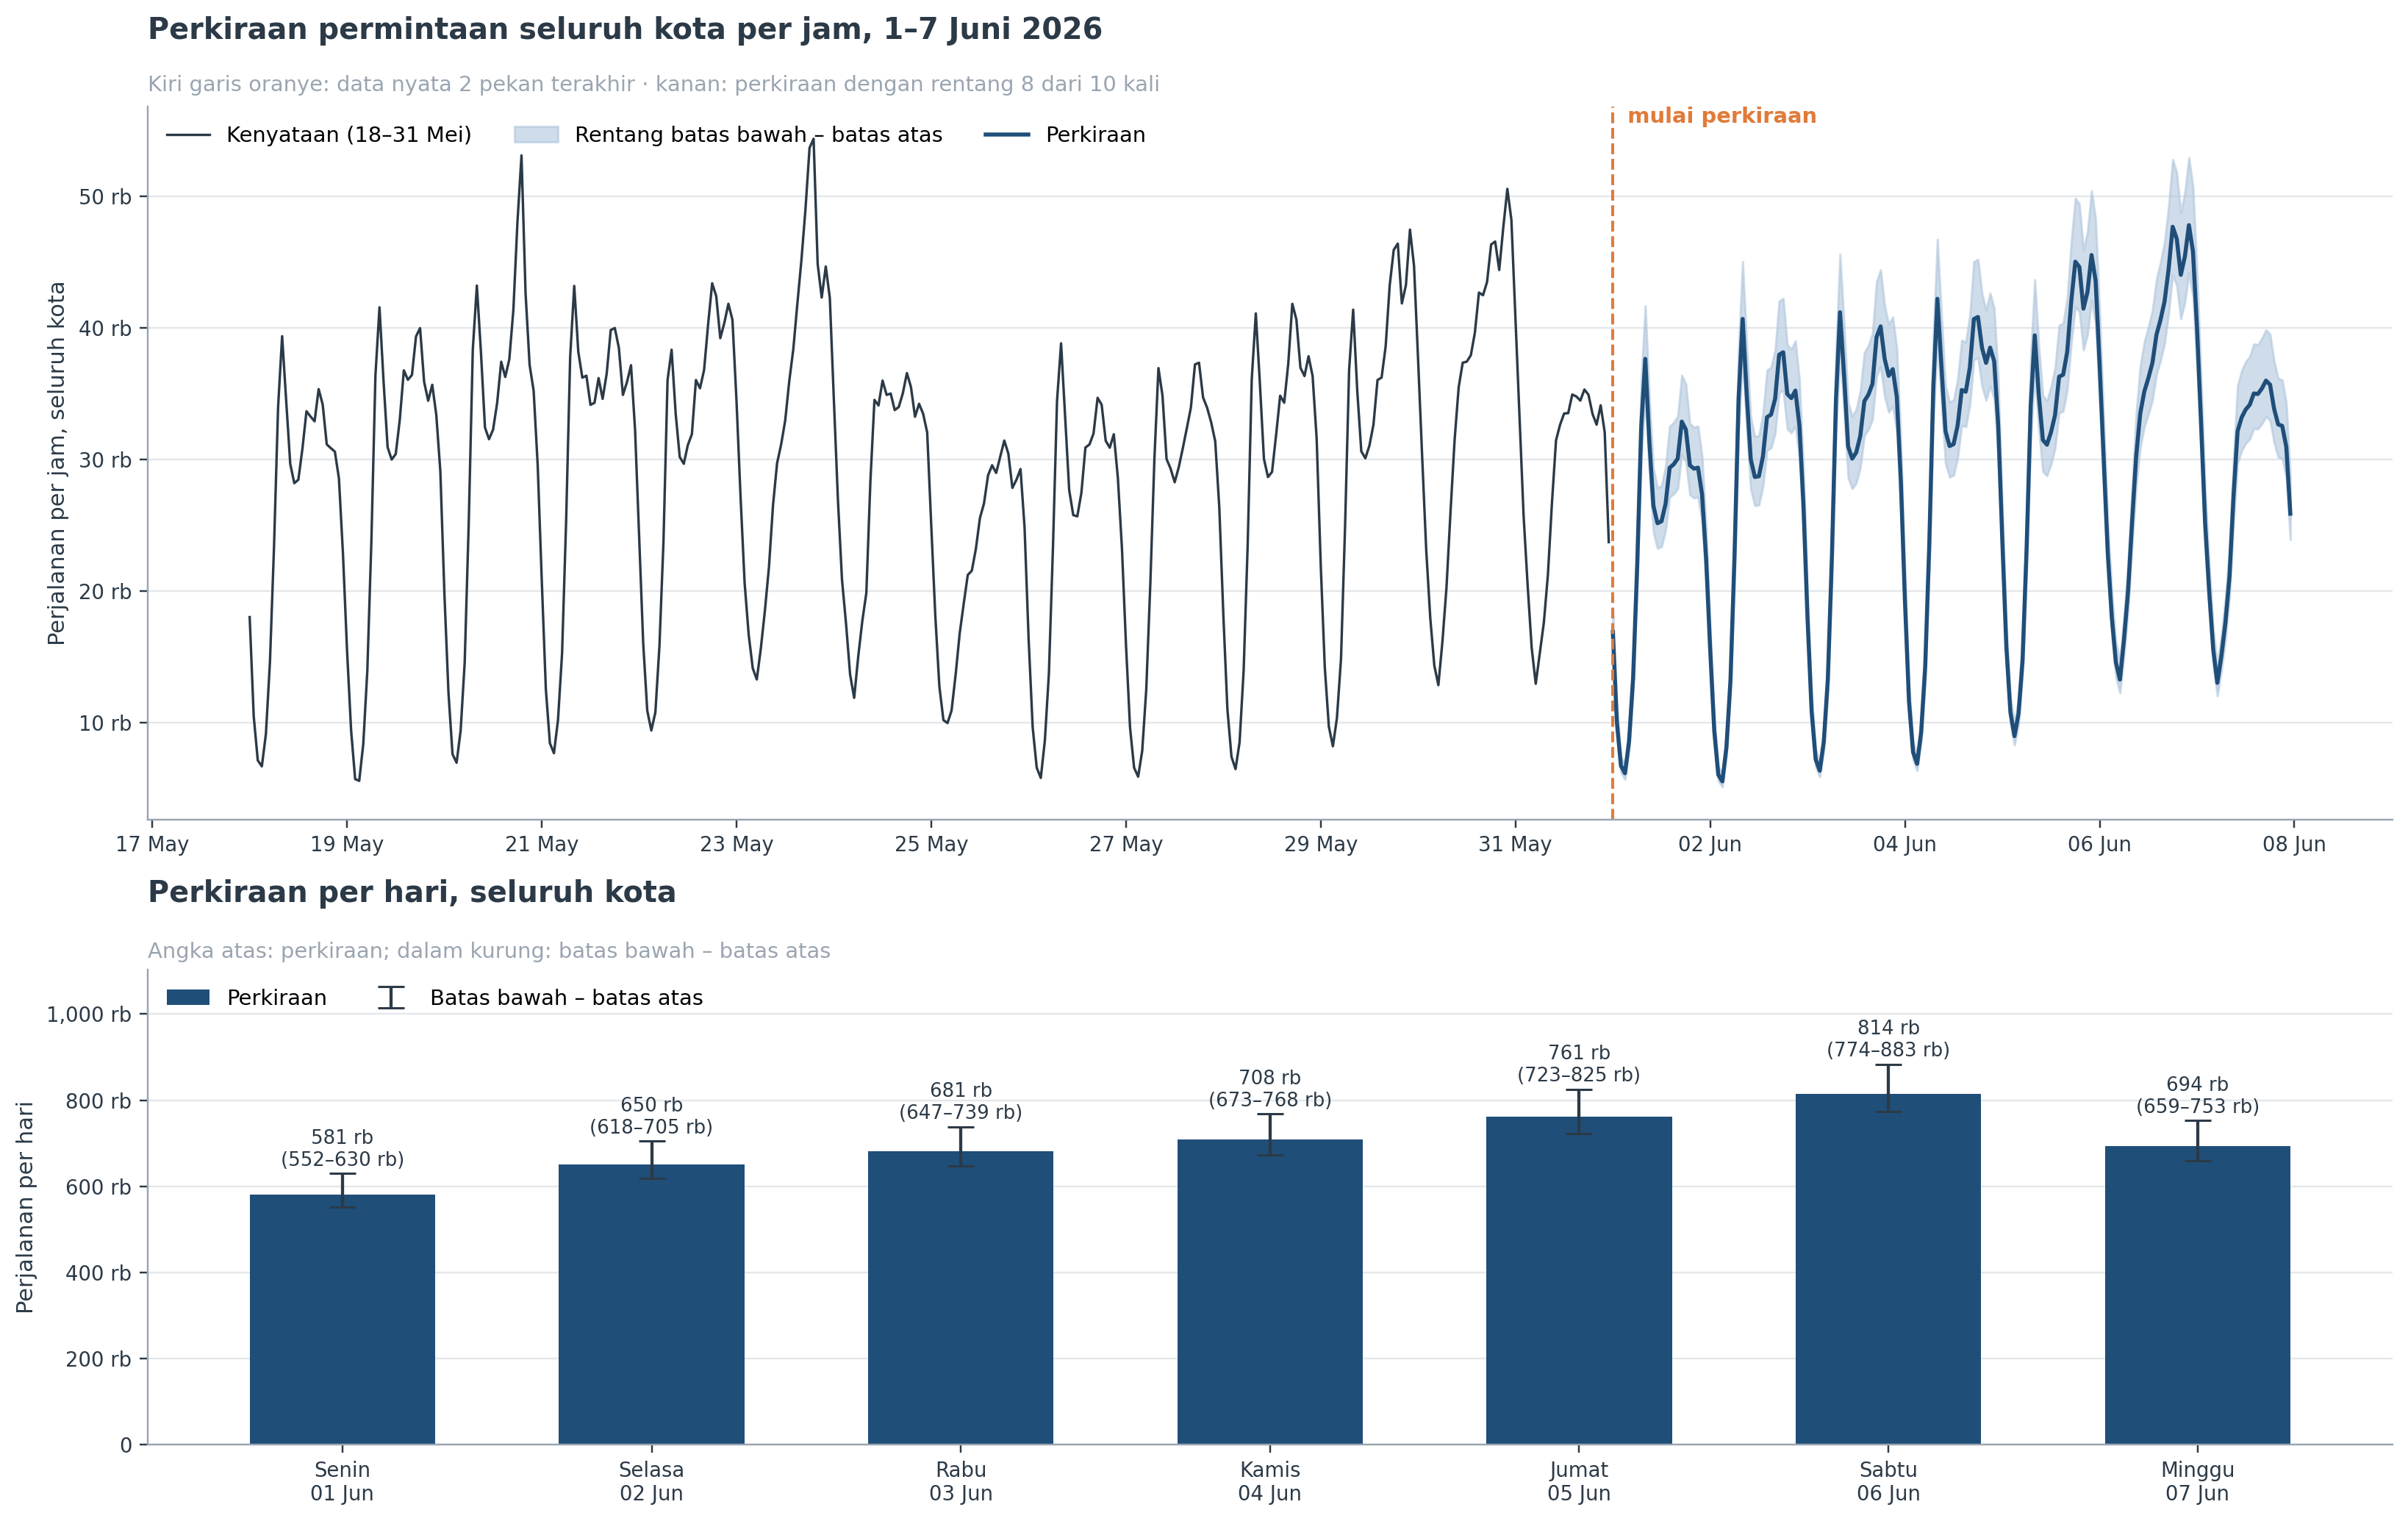

In [23]:
# ---------- Grafik: seluruh kota per jam ----------
kota_jam_depan = batas_agregat(agregat(gab_depan, ["jam"]), Q_AGR_AKHIR["Kota per jam"])
sejarah = agregat(gab_uji[gab_uji["jam"] >= pd.Timestamp(PERKIRAAN_MULAI) - pd.Timedelta(days=14)], ["jam"])

fig, axes = plt.subplots(2, 1, figsize=(15, 9.5), gridspec_kw={"height_ratios": [1.5, 1]})
ax = axes[0]
ax.plot(sejarah.index, sejarah["demand"], color=C["text"], linewidth=1.1, label="Kenyataan (18–31 Mei)")
ax.fill_between(kota_jam_depan.index, kota_jam_depan["batas_bawah"], kota_jam_depan["batas_atas"],
                color=C["band"], alpha=0.6, label="Rentang batas bawah – batas atas")
ax.plot(kota_jam_depan.index, kota_jam_depan["perkiraan"], color=C["primary"], linewidth=1.8, label="Perkiraan")
ax.axvline(pd.Timestamp(PERKIRAAN_MULAI), color=C["secondary"], linestyle="--", linewidth=1.3)
ax.text(pd.Timestamp(PERKIRAAN_MULAI), ax.get_ylim()[1], "  mulai perkiraan", color=C["secondary"],
        fontsize=9.5, va="top", fontweight="semibold")
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per jam, seluruh kota")
ax.legend(loc="upper left", ncol=3)
titled(ax, "Perkiraan permintaan seluruh kota per jam, 1–7 Juni 2026",
       "Kiri garis oranye: data nyata 2 pekan terakhir · kanan: perkiraan dengan rentang 8 dari 10 kali")
clean_axes(ax)

ax = axes[1]
xk = np.arange(len(kota_hari))
ax.bar(xk, kota_hari["perkiraan"], color=C["primary"], width=0.6, label="Perkiraan")
ax.errorbar(xk, kota_hari["perkiraan"],
            yerr=[kota_hari["perkiraan"] - kota_hari["batas_bawah"], kota_hari["batas_atas"] - kota_hari["perkiraan"]],
            fmt="none", ecolor=C["text"], elinewidth=1.4, capsize=6, label="Batas bawah – batas atas")
for i, r in kota_hari.iterrows():
    ax.text(i, r["batas_atas"] * 1.01, f"{r['perkiraan'] / 1000:,.0f} rb\n({r['batas_bawah'] / 1000:,.0f}–{r['batas_atas'] / 1000:,.0f} rb)",
            ha="center", va="bottom", fontsize=8.5, color=C["text"])
ax.set_xticks(xk)
ax.set_xticklabels([f"{h}\n{t:%d %b}" for h, t in zip(kota_hari["hari"], kota_hari["tanggal"])])
ax.set_ylim(0, kota_hari["batas_atas"].max() * 1.25)
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per hari")
ax.legend(loc="upper left", ncol=2)
titled(ax, "Perkiraan per hari, seluruh kota", "Angka atas: perkiraan; dalam kurung: batas bawah – batas atas")
clean_axes(ax)
plt.tight_layout()
plt.show()

15 ZONA DENGAN PERKIRAAN TERBESAR, TOTAL 1–7 JUNI 2026


,nama_zona,batas_bawah,perkiraan,batas_atas
zona,,,,
138,LaGuardia Airport,"90,359","101,392","116,093"
132,JFK Airport,"71,528","80,261","91,898"
61,Crown Heights North,"55,639","62,432","71,485"
230,Times Sq/Theatre District,"50,182","56,309","64,474"
76,East New York,"50,059","56,171","64,315"
161,Midtown Center,"49,762","55,837","63,933"
79,East Village,"48,483","54,402","62,290"
37,Bushwick South,"48,282","54,177","62,033"
246,West Chelsea/Hudson Yards,"47,286","53,060","60,753"


Perkiraan per hari untuk 15 zona tersebut:


,nama_zona,Sen 01/06,Sel 02/06,Rab 03/06,Kam 04/06,Jum 05/06,Sab 06/06,Min 07/06
zona,,,,,,,,
138,LaGuardia Airport,"16,677","14,883","14,651","15,982","14,731","9,075","15,393"
132,JFK Airport,"12,380","10,836","10,372","10,997","11,494","10,612","13,569"
61,Crown Heights North,"6,812","7,709","7,922","8,621","9,977","11,439","9,952"
230,Times Sq/Theatre District,"6,970","8,288","9,235","9,011","7,632","7,856","7,317"
76,East New York,"6,850","7,415","7,831","8,375","9,301","8,882","7,515"
161,Midtown Center,"7,732","9,269","10,424","10,216","7,519","6,013","4,666"
79,East Village,"4,799","5,726","6,408","6,792","8,632","12,351","9,693"
37,Bushwick South,"5,275","5,668","5,917","6,434","8,341","12,208","10,335"
246,West Chelsea/Hudson Yards,"5,935","8,095","8,632","8,849","7,388","8,013","6,149"


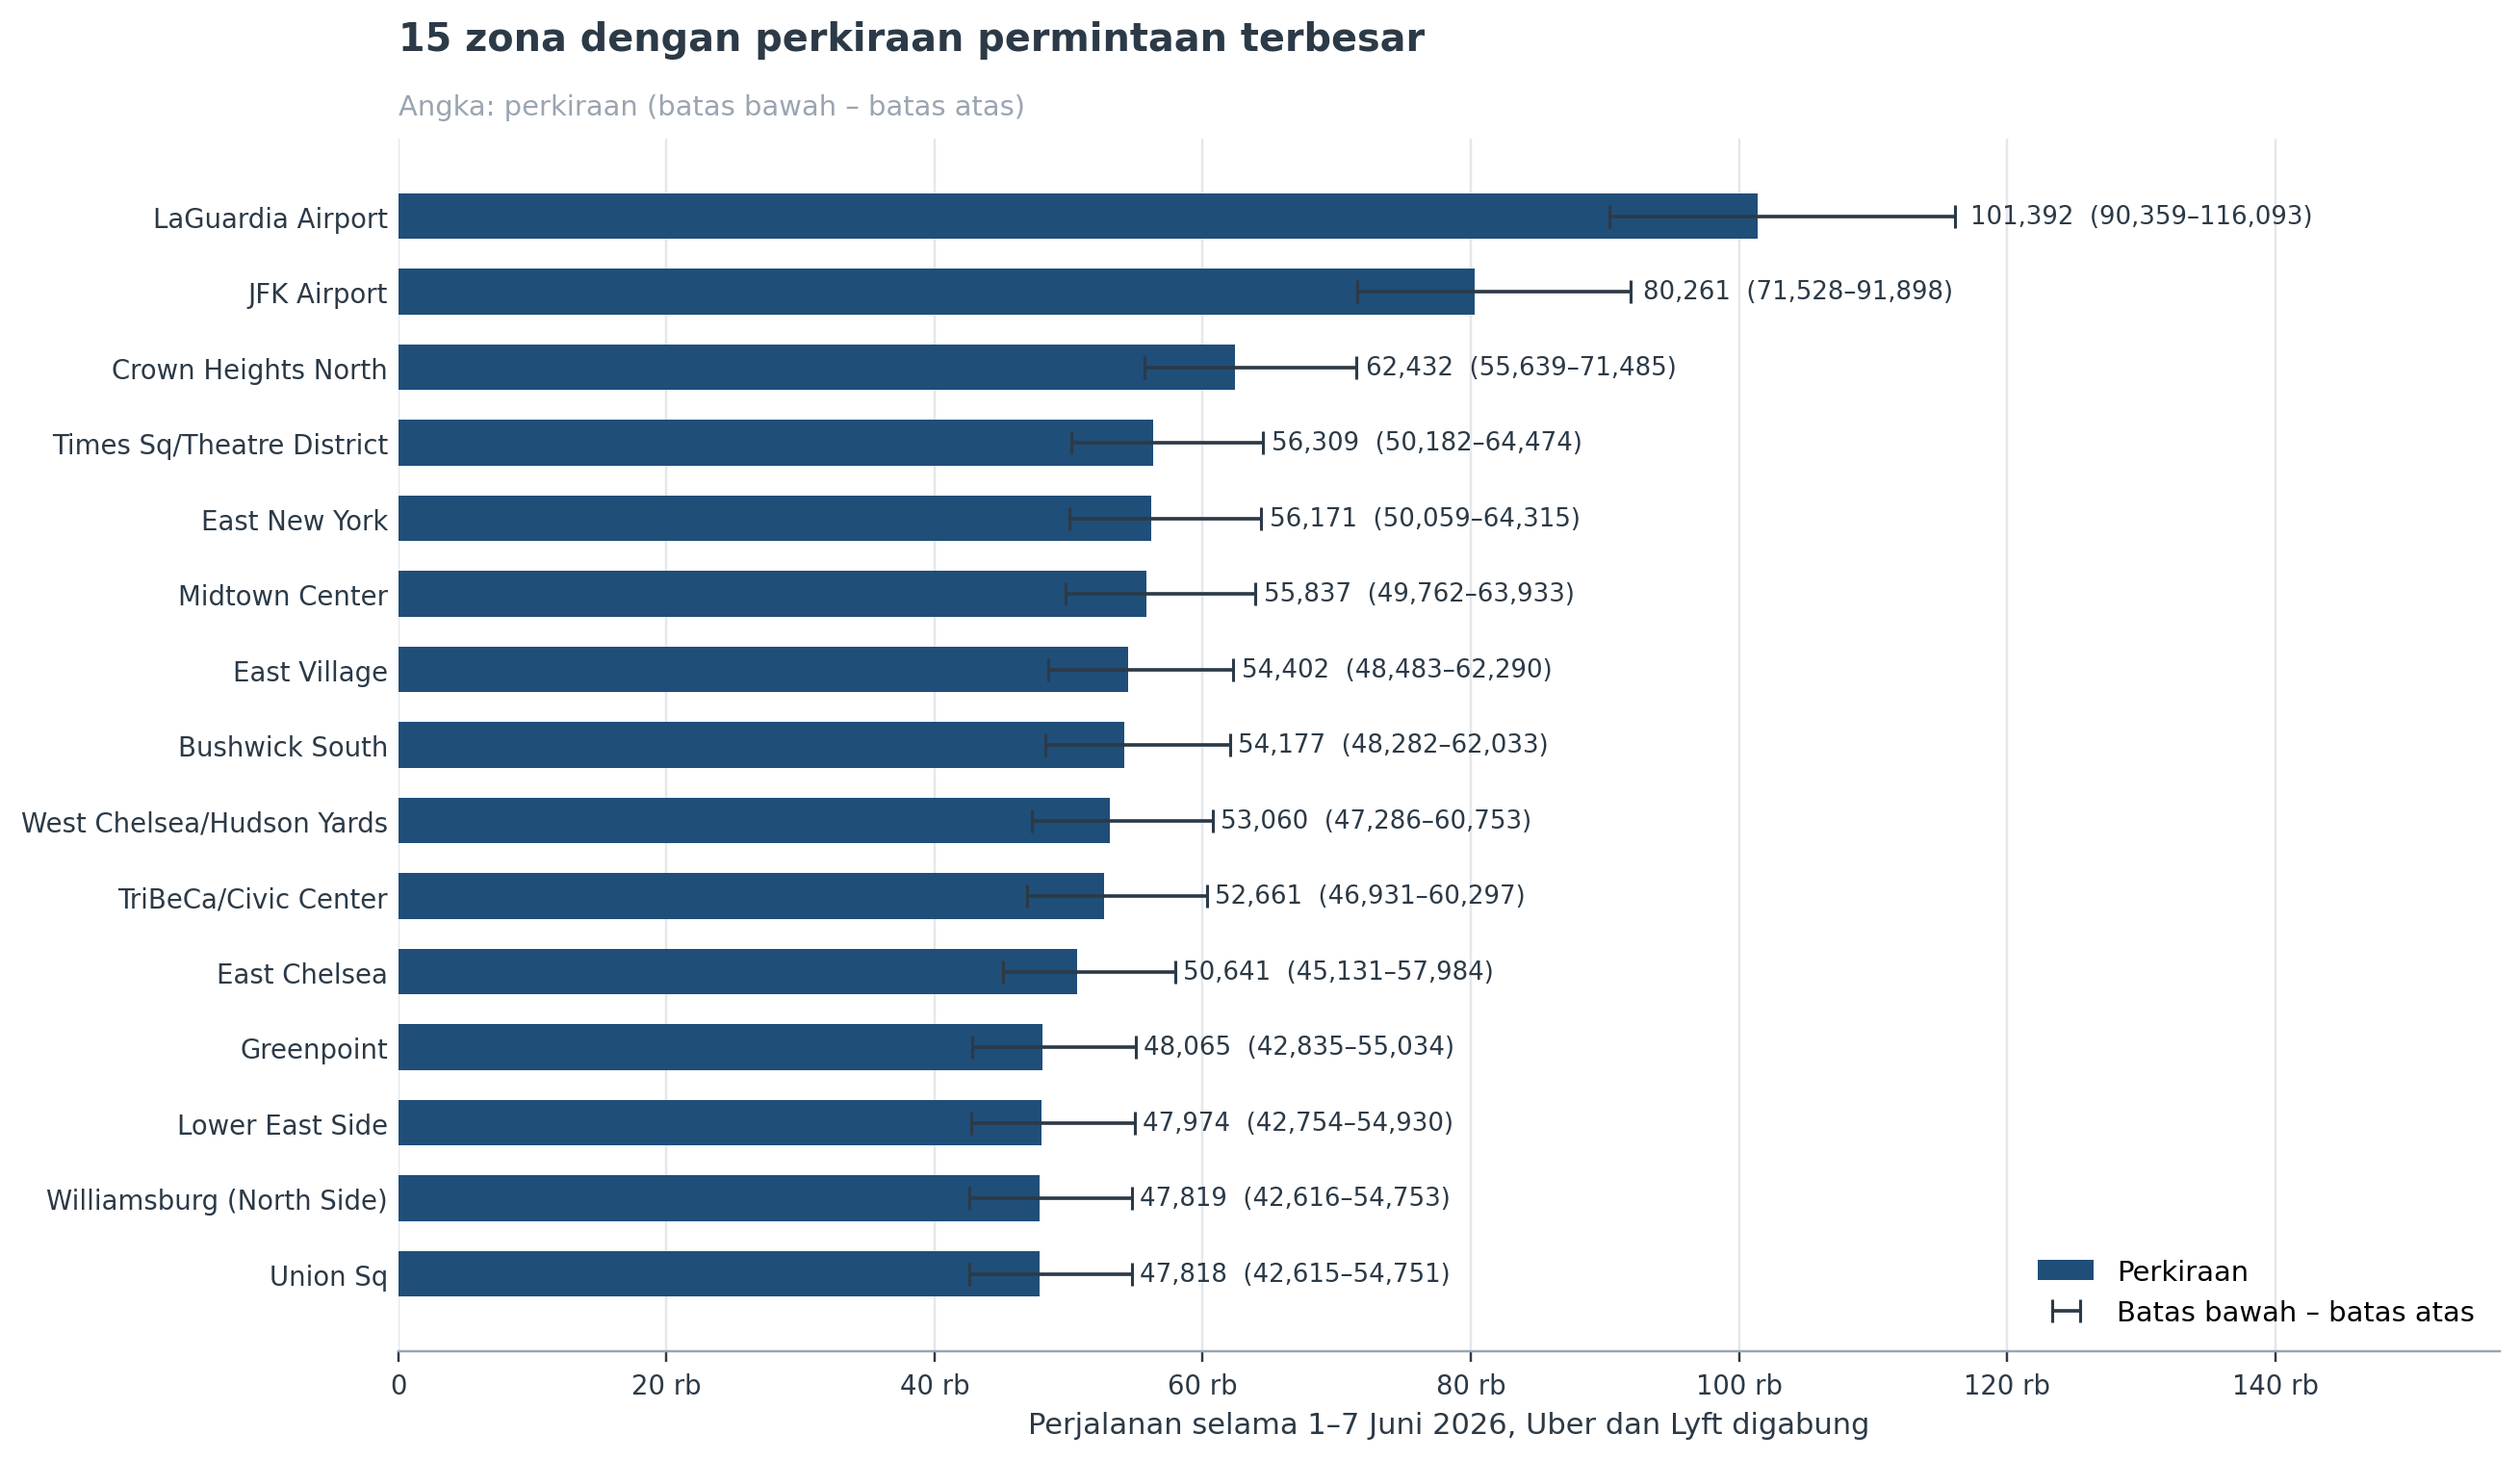

In [24]:
# ---------- Tabel dan grafik: 15 zona dengan perkiraan terbesar ----------
zona_hari = batas_agregat(agregat(gab_depan, ["zona", "tanggal"]), Q_AGR_AKHIR["Zona per hari"]).reset_index()
nama_zona = seri_info.drop_duplicates("zona").set_index("zona")["nama_zona"]
zona_pekan = zona_hari.groupby("zona")[["batas_bawah", "perkiraan", "batas_atas"]].sum() \
                      .sort_values("perkiraan", ascending=False)
atas15 = zona_pekan.head(15).copy()
atas15.insert(0, "nama_zona", atas15.index.map(nama_zona))

print("15 ZONA DENGAN PERKIRAAN TERBESAR, TOTAL 1–7 JUNI 2026")
display(atas15.style.format({"batas_bawah": "{:,.0f}", "perkiraan": "{:,.0f}", "batas_atas": "{:,.0f}"}))

rinci = zona_hari[zona_hari["zona"].isin(atas15.index)].pivot(index="zona", columns="tanggal", values="perkiraan") \
                  .loc[atas15.index]
rinci.columns = [f"{NAMA_HARI[t.dayofweek][:3]} {t:%d/%m}" for t in rinci.columns]
rinci.insert(0, "nama_zona", rinci.index.map(nama_zona))
print("Perkiraan per hari untuk 15 zona tersebut:")
display(rinci.style.format({c: "{:,.0f}" for c in rinci.columns if c != "nama_zona"}))

d = atas15.iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(d))
ax.barh(y, d["perkiraan"], color=C["primary"], height=0.6, label="Perkiraan")
ax.errorbar(d["perkiraan"], y, xerr=[d["perkiraan"] - d["batas_bawah"], d["batas_atas"] - d["perkiraan"]],
            fmt="none", ecolor=C["text"], elinewidth=1.2, capsize=4, label="Batas bawah – batas atas")
for i, (p, lo, hi) in enumerate(zip(d["perkiraan"], d["batas_bawah"], d["batas_atas"])):
    ax.text(hi * 1.01, i, f"{p:,.0f}  ({lo:,.0f}–{hi:,.0f})", va="center", fontsize=8.5, color=C["text"])
ax.set_yticks(y)
ax.set_yticklabels(d["nama_zona"])
ax.set_xlim(0, d["batas_atas"].max() * 1.35)
ax.xaxis.set_major_formatter(RIBU)
ax.set_xlabel("Perjalanan selama 1–7 Juni 2026, Uber dan Lyft digabung")
ax.legend(loc="lower right")
titled(ax, "15 zona dengan perkiraan permintaan terbesar", "Angka: perkiraan (batas bawah – batas atas)")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

In [25]:
# ---------- Tabel lengkap per seri per jam ----------
tabel_seri = gab_depan.merge(seri_info.assign(provider=seri_info["provider"].astype(str))[["provider", "zona", "nama_zona", "borough"]],
                             on=["provider", "zona"], how="left")
tabel_seri["cara"] = np.where(tabel_seri["kelompok_interval"] == "Di luar cakupan", "Rata-rata 4 pekan", "Model")
tabel_seri = tabel_seri[["jam", "zona", "nama_zona", "borough", "provider", "cara",
                         "batas_bawah", "perkiraan", "batas_atas"]].sort_values(["jam", "perkiraan"], ascending=[True, False])

print(f"Tabel perkiraan per seri per jam: {len(tabel_seri):,} baris "
      f"({tabel_seri[['zona', 'provider']].drop_duplicates().shape[0]} seri × {tabel_seri['jam'].nunique()} jam)")
print("Contoh: 10 seri terbesar pada Senin 1 Juni 2026 jam 18:00")
tabel_seri[tabel_seri["jam"] == pd.Timestamp("2026-06-01 18:00")].head(10) \
    .style.format({"batas_bawah": "{:,.1f}", "perkiraan": "{:,.1f}", "batas_atas": "{:,.1f}"}).hide(axis="index")

Tabel perkiraan per seri per jam: 88,032 baris (524 seri × 168 jam)
Contoh: 10 seri terbesar pada Senin 1 Juni 2026 jam 18:00


jam,zona,nama_zona,borough,provider,cara,batas_bawah,perkiraan,batas_atas
2026-06-01 18:00:00,138,LaGuardia Airport,Queens,Uber,Model,630.7,701.7,775.1
2026-06-01 18:00:00,161,Midtown Center,Manhattan,Uber,Model,404.3,462.0,521.6
2026-06-01 18:00:00,132,JFK Airport,Queens,Uber,Model,402.1,459.5,519.0
2026-06-01 18:00:00,246,West Chelsea/Hudson Yards,Manhattan,Uber,Model,311.3,362.3,415.1
2026-06-01 18:00:00,231,TriBeCa/Civic Center,Manhattan,Uber,Model,273.1,321.2,371.0
2026-06-01 18:00:00,230,Times Sq/Theatre District,Manhattan,Uber,Model,271.9,319.9,369.5
2026-06-01 18:00:00,234,Union Sq,Manhattan,Uber,Model,265.8,313.3,362.5
2026-06-01 18:00:00,68,East Chelsea,Manhattan,Uber,Model,256.0,302.7,351.0
2026-06-01 18:00:00,163,Midtown North,Manhattan,Uber,Model,249.1,295.2,342.9
2026-06-01 18:00:00,237,Upper East Side South,Manhattan,Uber,Model,239.2,284.4,331.2


> **Cara membaca Step 10**

**Yang diperkirakan adalah jumlah perjalanan**, untuk setiap zona × provider × jam selama 1–7 Juni 2026 — 524 seri × 168 jam. Grafik menjumlahkannya menjadi seluruh kota agar dapat dilihat dalam satu gambar; rincian per zona dan per seri ada di tabel.

**Tabel seluruh kota per hari** — untuk setiap tanggal: batas bawah, perkiraan, dan batas atas jumlah perjalanan seluruh kota. Perkiraan adalah angka untuk perencanaan. Batas bawah dan atas adalah skenario sepi dan ramai: 8 dari 10 hari, kenyataan diperkirakan berada di antaranya.

**Grafik per jam** — kiri garis oranye adalah data nyata dua pekan terakhir, kanan adalah perkiraan. Garis biru adalah perkiraan, area biru muda adalah rentangnya.

**Grafik per hari** — tinggi batang adalah perkiraan, garis tegak adalah rentang. Angka di atas batang: perkiraan, dan dalam kurung rentangnya.

**15 zona terbesar** — perkiraan total 1–7 Juni per zona, Uber dan Lyft digabung, lalu dirinci per hari.

**Tabel per seri per jam** — perkiraan paling rinci. Kolom `cara` menunjukkan apakah angkanya dari model atau dari rata-rata 4 pekan untuk seri di luar cakupan.

> **Hasil Step 10 — perkiraan 1–7 Juni 2026**

| Hari | Batas bawah | Perkiraan | Batas atas |
|---|---|---|---|
| Senin 1 Juni | 554.591 | 583.979 | 634.463 |
| Selasa 2 Juni | 617.848 | 650.588 | 706.829 |
| Rabu 3 Juni | 647.135 | 681.428 | 740.335 |
| Kamis 4 Juni | 671.790 | 707.389 | 768.541 |
| Jumat 5 Juni | 722.825 | 761.128 | 826.926 |
| Sabtu 6 Juni | 773.364 | 814.345 | 884.742 |
| Minggu 7 Juni | 659.378 | 694.319 | 754.341 |
| **Total** | **4.646.931** | **4.893.176** | **5.316.177** |

**Temuan 1 — Total pekan diperkirakan 4,89 juta perjalanan,** 2,8% di atas pekan sebelumnya (4,76 juta pada 25–31 Mei), sejalan dengan pertumbuhan yang berlangsung sejak akhir 2025.

**Temuan 2 — Pola harian mengikuti temuan Business Analytics.** Permintaan naik dari Senin (584 ribu) sampai puncak Sabtu (814 ribu), lalu turun di Minggu. Sabtu diperkirakan 39% lebih ramai dari Senin.

**Temuan 3 — Senin 1 Juni diperkirakan paling sepi,** dan pekan lalunya adalah Memorial Day (25 Mei). Fitur penanda libur pekan lalu mencegah angka hari libur itu terbawa mentah-mentah ke perkiraan.

**Temuan 4 — Zona terbesar tetap bandara.** LaGuardia Airport diperkirakan 100.855 perjalanan (89.807–115.364), JFK Airport 81.016, lalu Crown Heights North 62.486. LaGuardia diperkirakan jauh lebih sepi pada Sabtu (9.047) dibanding hari lain (14–17 ribu), sesuai pola yang terlihat di Business Analytics.

---

# STEP 11 — Menyimpan Hasil

In [26]:
# File dari versi notebook sebelumnya yang tidak dipakai lagi
USANG = ["model_akhir_semua.txt", "modelling.duckdb", "modelling.duckdb.wal", "model_lgbm.txt",
         "tebakan_uji.parquet", "fitur_penting.csv", "konsistensi_per_pekan.csv",
         "penilaian_keseluruhan.csv", "penilaian_per_kelompok.csv"]
for nama_f in USANG:
    if (FOLDER_MODEL / nama_f).exists():
        (FOLDER_MODEL / nama_f).unlink()
        print(f"Dihapus (versi lama): {nama_f}")

# Model akhir
if STATE_AKHIR["jenis"] == "linear":
    np.save(FOLDER_MODEL / "model_akhir_linear.npy", STATE_AKHIR["koef"])
else:
    for g, mdl in STATE_AKHIR["model"].items():
        mdl.save_model(str(FOLDER_MODEL / f"model_akhir_{STATE_AKHIR['jenis']}_{'semua' if g is None else g}"
                           f"{'.txt' if STATE_AKHIR['jenis'] == 'lgb' else '.json'}"))

# Perkiraan
tabel_seri.to_csv(FOLDER_MODEL / "perkiraan_seri_per_jam.csv", index=False)
tabel_kota.to_csv(FOLDER_MODEL / "perkiraan_kota_per_hari.csv", index=False)
zona_hari.assign(nama_zona=zona_hari["zona"].map(nama_zona)).to_csv(FOLDER_MODEL / "perkiraan_zona_per_hari.csv", index=False)
kota_jam_depan.reset_index().to_csv(FOLDER_MODEL / "perkiraan_kota_per_jam.csv", index=False)

# Penilaian
hasil_val.to_csv(FOLDER_MODEL / "penilaian_validasi_kandidat.csv")
per_periode.to_csv(FOLDER_MODEL / "penilaian_validasi_per_periode.csv")
syarat.to_csv(FOLDER_MODEL / "syarat_pemilihan.csv")
hasil_uji.to_csv(FOLDER_MODEL / "penilaian_uji.csv")
per_kelompok.to_csv(FOLDER_MODEL / "penilaian_uji_per_kelompok.csv")
pd.DataFrame(cek).T.to_csv(FOLDER_MODEL / "cakupan_batas_uji.csv")
per_waktu.to_csv(FOLDER_MODEL / "cakupan_batas_uji_per_waktu.csv")
banding.to_csv(FOLDER_MODEL / "cakupan_rentang_bergulir.csv")
if (FOLDER_MODEL / "cakupan_kalibrasi_apr_mei.csv").exists():
    (FOLDER_MODEL / "cakupan_kalibrasi_apr_mei.csv").unlink()
tabel_acf.to_csv(FOLDER_MODEL / "acf_lag_kunci.csv")
tabel_sisa.to_csv(FOLDER_MODEL / "acf_sisa_kesalahan.csv")

for f in sorted(FOLDER_MODEL.glob("*.*")):
    print(f"{f.name:44} {f.stat().st_size / 1e6:8.2f} MB")

acf_lag_kunci.csv                                0.00 MB
acf_sisa_kesalahan.csv                           0.00 MB
cakupan_batas_uji.csv                            0.00 MB
cakupan_batas_uji_per_waktu.csv                  0.00 MB
cakupan_rentang_bergulir.csv                     0.00 MB
fitur.parquet                                  217.11 MB
fitur_14hari.parquet                           223.12 MB
fitur_28hari.parquet                           221.45 MB
model_akhir_lgb_semua.txt                       38.32 MB
penilaian_per_jarak.csv                          0.00 MB
penilaian_uji.csv                                0.00 MB
penilaian_uji_per_kelompok.csv                   0.00 MB
penilaian_validasi_kandidat.csv                  0.00 MB
penilaian_validasi_per_periode.csv               0.00 MB
perkiraan_kota_juni_per_hari.csv                 0.00 MB
perkiraan_kota_juni_per_pekan.csv                0.00 MB
perkiraan_kota_per_hari.csv                      0.00 MB
perkiraan_kota_per_jam.csv     

---

# PENGEMBANGAN LANJUTAN — Perkiraan 14 dan 28 Hari

**Bukan bagian dari tujuan utama.** Rencana project menetapkan perkiraan 1–7 hari, dan ukuran keberhasilannya adalah mengalahkan angka pekan lalu. Bagian ini adalah pengembangan: perkiraan untuk **14 hari** (1–14 Juni) dan **28 hari** (1–28 Juni), untuk keputusan jangka lebih panjang seperti jadwal shift dan insentif.

**Kenapa perlu model tersendiri untuk setiap jarak:** model utama memakai data paling baru 7 hari sebelum jam yang diperkirakan. Untuk perkiraan 28 hari ke depan, data 7 hari sebelumnya belum ada. Maka untuk setiap jarak dibuat fitur baru yang hanya memakai data paling baru **14 atau 28 hari** sebelumnya.

| Jarak | Fitur memakai data minimal | Perkiraan | Pembanding |
|---|---|---|---|
| 7 hari (utama) | 7 hari sebelumnya | 1–7 Juni | Angka 7 hari lalu, rata-rata 4 pekan |
| 14 hari | 14 hari sebelumnya | 1–14 Juni | Angka 14 hari lalu, rata-rata 4 pekan yang berakhir 14 hari lalu |
| 28 hari | 28 hari sebelumnya | 1–28 Juni | Angka 28 hari lalu, rata-rata 4 pekan yang berakhir 28 hari lalu |

ACF di Step 5B menunjukkan hubungan dengan 14 dan 28 hari sebelumnya masih kuat, sehingga perkiraan pada jarak ini masih bermakna.

**Cara:**
1. Fitur dibangun ulang untuk jarak 14 dan 28 hari, dengan nama kolom yang sama
2. Jenis model dan jumlah iterasi sama dengan model terpilih
3. Dilatih sampai Desember 2025, dinilai pada Januari–Mei 2026 — dibandingkan dengan model 7 hari yang juga dilatih sekali, agar adil
4. Batas bawah dan atas dibuat dengan cara yang sama seperti jarak 7 hari: model juga dilatih pada tiga periode validasi, sehingga kalibrasi memakai 14 bulan kesalahan, lalu diuji bergulir per bulan
5. Dilatih ulang pada seluruh data sampai 31 Mei, lalu memperkirakan Juni

**Waktu:** sekitar 20–40 menit, karena setiap jarak melatih model lima kali: tiga periode validasi, satu untuk periode uji, dan satu untuk perkiraan Juni.

In [27]:
PERKIRAAN_JUNI_AKHIR = "2026-06-28 23:00:00"


def bangun_fitur_jarak(hari):
    # Fitur untuk jarak perkiraan tertentu. Nama kolom sama dengan fitur utama,
    # tetapi setiap fitur hanya memakai data paling baru `hari` hari sebelumnya.
    H = hari * 24
    path = FOLDER_MODEL / f"fitur_{hari}hari.parquet"
    con.execute(f"""
    CREATE OR REPLACE TABLE jam_grid_juni AS
    SELECT jam FROM (SELECT UNNEST(generate_series(TIMESTAMP '{AWAL_DATA}', TIMESTAMP '{PERKIRAAN_JUNI_AKHIR}',
                                                   INTERVAL 1 HOUR)) AS jam)
    WHERE NOT (hour(jam) = 2 AND CAST(jam AS DATE) IN ({semi}))
    """)
    con.execute(f"""
    CREATE OR REPLACE TABLE grid_h AS
    SELECT s.provider, s.zona, g.jam,
           CASE WHEN g.jam <= TIMESTAMP '{AKHIR_DATA}' THEN COALESCE(d.demand, 0) END AS demand
    FROM seri s CROSS JOIN jam_grid_juni g
    LEFT JOIN demand d ON d.provider = s.provider AND d.zona = s.zona AND d.jam = g.jam
    """)
    def lag(k):
        return f"MAX(g.demand) OVER (w RANGE BETWEEN INTERVAL {k} HOUR PRECEDING AND INTERVAL {k} HOUR PRECEDING)"
    def rata(a, b):
        return f"AVG(g.demand) OVER (w RANGE BETWEEN INTERVAL {a} HOUR PRECEDING AND INTERVAL {b} HOUR PRECEDING)"
    con.execute(f"""
    CREATE OR REPLACE TABLE fitur_h AS
    SELECT g.provider, g.zona, g.jam, g.demand,
        {lag(H)} AS lag_1pekan, {lag(H + 168)} AS lag_2pekan, {lag(H + 336)} AS lag_3pekan, {lag(H + 504)} AS lag_4pekan,
        {lag(8736)} AS lag_52pekan,
        {rata(H + 23, H)} AS rata_1hari, {rata(H + 167, H)} AS rata_1pekan, {rata(H + 671, H)} AS rata_4pekan,
        {rata(8736 + H + 671, 8736 + H)} AS rata_4pekan_tahun_lalu,
        hour(g.jam) AS jam_hari, isodow(g.jam) AS hari, month(g.jam) AS bulan,
        CAST(l.tanggal IS NOT NULL AS INT) AS libur,
        CAST((isodow(g.jam) = 5 AND hour(g.jam) >= 17)
          OR (isodow(g.jam) = 6 AND (hour(g.jam) >= 17 OR hour(g.jam) < 5))
          OR (isodow(g.jam) = 7 AND hour(g.jam) < 5) AS INT) AS malam_akhir_pekan
    FROM grid_h g
    LEFT JOIN libur l ON l.tanggal = CAST(g.jam AS DATE)
    WINDOW w AS (PARTITION BY g.provider, g.zona ORDER BY g.jam)
    """)
    angka = ", ".join(f"CAST(f.{k} AS FLOAT) AS {k}" for k in ANGKA)
    con.execute(f"""
    COPY (
        SELECT f.provider, f.zona, f.jam, s.kelompok_seri, s.dimodelkan, s.kelompok_jam, s.borough, {angka}
        FROM fitur_h f JOIN seri_info_tbl s USING (provider, zona)
        WHERE f.jam >= TIMESTAMP '{LATIH_MULAI}'
    ) TO '{path}' (FORMAT PARQUET)
    """)
    for t in ["grid_h", "fitur_h", "jam_grid_juni"]:
        con.execute(f"DROP TABLE {t}")
    return path


HASIL_JARAK = {}
for hari in [14, 28]:
    t0 = time.time()
    print(f"\n======== Jarak {hari} hari ========")
    path = bangun_fitur_jarak(hari)
    akhir_perkiraan = pd.Timestamp(PERKIRAAN_MULAI) + pd.Timedelta(days=hari)
    b = dict(path=path, jarak_hari=hari)
    sej_h = baca(True, sampai=TEST_MULAI, **b)
    uji_h = baca(True, TEST_MULAI, PERKIRAAN_MULAI, **b)
    dep_h = baca(True, PERKIRAAN_MULAI, str(akhir_perkiraan), **b)
    luar_uji_h = baca(False, TEST_MULAI, PERKIRAAN_MULAI, **b)
    luar_hist_h = baca(False, LIPATAN[0][1], TEST_MULAI, **b)
    luar_dep_h = baca(False, PERKIRAAN_MULAI, str(akhir_perkiraan), **b)
    print(f"Fitur dibangun dan dibaca dalam {time.time() - t0:.0f} detik")

    # Penilaian pada periode uji: dilatih sekali sampai Desember 2025
    st = latih_ulang(STATE_TERPILIH, sej_h)
    uji_h["perkiraan"] = tebak(st, uji_h)
    del st; gc.collect()
    nama_pb = {"tebak_pekan_lalu": f"Angka {hari} hari lalu",
               "tebak_rata_4pekan": f"Rata-rata 4 pekan, berakhir {hari} hari lalu"}
    nilai = tabel_ukur(uji_h, {"perkiraan": f"Model jarak {hari} hari", **nama_pb})

    # Tebakan tiga periode validasi, untuk kalibrasi rentang dari 14 bulan
    oof_h = []
    for nama_lip, mulai_l, akhir_l in LIPATAN:
        tr = sej_h[sej_h["jam"] < pd.Timestamp(mulai_l)]
        va = sej_h[(sej_h["jam"] >= pd.Timestamp(mulai_l)) & (sej_h["jam"] < pd.Timestamp(akhir_l))].copy()
        st = latih_ulang(STATE_TERPILIH, tr)
        va["perkiraan"] = tebak(st, va)
        oof_h.append(va)
        del tr, st; gc.collect()
    oof_h = pd.concat(oof_h, ignore_index=True)
    print(f"Periode validasi: meleset {ukur(oof_h['demand'], oof_h['perkiraan'])['WMAPE']:.2f} dari 100")

    # Batas bawah dan atas: uji bergulir per bulan, lalu kalibrasi akhir dari 14 bulan
    gab_hist_h, gab_u = gabung(oof_h, luar_hist_h), gabung(uji_h, luar_uji_h)
    tabel_cak, cak, _ = cek_bulanan(gab_hist_h, gab_u)
    kal = pd.concat([gab_hist_h, gab_u], ignore_index=True)
    q_s = kalibrasi_seri(kal)
    q_a = {n: kalibrasi_agregat(kal, k) for n, k in TINGKAT.items()}
    del kal, oof_h; gc.collect()

    # Perkiraan Juni: dilatih ulang pada seluruh data sampai 31 Mei
    semua_h = pd.concat([sej_h, uji_h[KOLOM_DATA]], ignore_index=True)
    st = latih_ulang(STATE_TERPILIH, semua_h)
    del semua_h; gc.collect()
    dep_h["perkiraan"] = tebak(st, dep_h)
    del st; gc.collect()
    gab_d = batas_seri(gabung(dep_h, luar_dep_h), q_s)
    kota_h = batas_agregat(agregat(gab_d, ["tanggal"]), q_a["Kota per hari"]).reset_index()

    HASIL_JARAK[hari] = {"nilai": nilai, "cakupan": cak, "tabel_cakupan": tabel_cak, "kota_hari": kota_h, "seri": gab_d}
    print(f"Selesai dalam {(time.time() - t0) / 60:.1f} menit")
    display(nilai.style.format(FORMAT_UKUR))
    print("Uji bergulir per bulan: cakupan rentang (target 80%)")
    display(tabel_cak.style.format("{:.1f}"))
    del sej_h, uji_h, dep_h, luar_uji_h, luar_dep_h, luar_hist_h, gab_u, gab_hist_h
    gc.collect()


======== Jarak 14 hari ========
Fitur dibangun dan dibaca dalam 27 detik
Periode validasi: meleset 15.00 dari 100
Selesai dalam 13.4 menit


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE
Model jarak 14 hari,16.62,16.44,9.37,7.25,-2.1%,23.17,12.80
Angka 14 hari lalu,23.34,22.79,11.96,11.38,-0.6%,34.00,17.97
"Rata-rata 4 pekan, berakhir 14 hari lalu",19.23,18.79,9.63,9.60,-0.0%,26.85,14.81


Uji bergulir per bulan: cakupan rentang (target 80%)


,Seri per jam,Kota per jam,Kota per hari,Zona per hari
Bulan,,,,
Jan 2026,70.0,40.7,19.4,53.4
Feb 2026,73.9,68.8,53.6,61.6
Mar 2026,80.4,77.7,74.2,80.8
Apr 2026,79.9,82.8,90.0,83.7
May 2026,80.1,86.7,93.5,85.7
Gabungan Jan–Mei,76.9,71.3,66.2,73.2
Batas wajar ±,nan,nan,6.4,nan



======== Jarak 28 hari ========
Fitur dibangun dan dibaca dalam 26 detik
Periode validasi: meleset 15.20 dari 100
Selesai dalam 12.3 menit


,WMAPE,WMAPE jam sibuk,Kurang tebak,Lebih tebak,Bias %,RMSE,MAE
Model jarak 28 hari,16.59,16.37,9.37,7.23,-2.1%,22.85,12.78
Angka 28 hari lalu,23.98,23.48,11.81,12.17,+0.4%,34.37,18.47
"Rata-rata 4 pekan, berakhir 28 hari lalu",19.77,19.28,9.86,9.90,+0.0%,27.38,15.22


Uji bergulir per bulan: cakupan rentang (target 80%)


,Seri per jam,Kota per jam,Kota per hari,Zona per hari
Bulan,,,,
Jan 2026,73.3,55.1,38.7,61.6
Feb 2026,73.9,62.1,64.3,64.5
Mar 2026,79.2,76.6,74.2,80.6
Apr 2026,80.1,83.1,90.0,82.8
May 2026,77.5,84.1,90.3,85.3
Gabungan Jan–Mei,76.8,72.3,71.5,75.1
Batas wajar ±,nan,nan,6.4,nan


In [28]:
# ---------- Ringkasan kesalahan per jarak ----------
baris = [{"Jarak": "7 hari (utama)",
          "Model": hasil_uji.iloc[1]["WMAPE"],
          "Angka k hari lalu": hasil_uji.loc["Angka pekan lalu", "WMAPE"],
          "Rata-rata 4 pekan": hasil_uji.loc["Rata-rata 4 pekan", "WMAPE"],
          "Bias model %": hasil_uji.iloc[1]["Bias %"],
          "WMAPE jam sibuk": hasil_uji.iloc[1]["WMAPE jam sibuk"],
          "Cakupan seri per jam": CAKUPAN_7["Seri per jam"],
          "Cakupan kota per hari": CAKUPAN_7["Kota per hari"]}]
for hari, h in HASIL_JARAK.items():
    n = h["nilai"]
    baris.append({"Jarak": f"{hari} hari",
                  "Model": n.iloc[0]["WMAPE"], "Angka k hari lalu": n.iloc[1]["WMAPE"],
                  "Rata-rata 4 pekan": n.iloc[2]["WMAPE"], "Bias model %": n.iloc[0]["Bias %"],
                  "WMAPE jam sibuk": n.iloc[0]["WMAPE jam sibuk"],
                  "Cakupan seri per jam": h["cakupan"]["Seri per jam"],
                  "Cakupan kota per hari": h["cakupan"]["Kota per hari"]})
per_jarak = pd.DataFrame(baris).set_index("Jarak")
per_jarak["Model lebih baik dari rata-rata 4 pekan?"] = np.where(
    per_jarak["Rata-rata 4 pekan"] - per_jarak["Model"] >= BATAS_POIN, "Ya",
    np.where((per_jarak["Rata-rata 4 pekan"] - per_jarak["Model"]).abs() < BATAS_POIN, "Setara", "Tidak"))
print("Periode uji, Januari–Mei 2026. Semua model dilatih sekali sampai Desember 2025.")
print("WMAPE = perjalanan yang meleset dari setiap 100.")
display(per_jarak.style.format({"Model": "{:.2f}", "Angka k hari lalu": "{:.2f}", "Rata-rata 4 pekan": "{:.2f}",
                                "Bias model %": "{:+.1f}%", "WMAPE jam sibuk": "{:.2f}",
                                "Cakupan seri per jam": "{:.1f}%", "Cakupan kota per hari": "{:.1f}%"}))
print("Cakupan: uji bergulir per bulan, Januari–Mei 2026, target 80%.")

# ---------- Perkiraan Juni per pekan: pakai model dengan jarak terpendek yang sah ----------
pekan_juni = [("1–7 Juni", 0, 7, "7 hari", kota_hari),
              ("8–14 Juni", 7, 14, "14 hari", HASIL_JARAK[14]["kota_hari"]),
              ("15–21 Juni", 14, 21, "28 hari", HASIL_JARAK[28]["kota_hari"]),
              ("22–28 Juni", 21, 28, "28 hari", HASIL_JARAK[28]["kota_hari"])]
mulai = pd.Timestamp(PERKIRAAN_MULAI)
baris, harian = [], []
for label, a, b, model, kh in pekan_juni:
    d = kh[(kh["tanggal"] >= mulai + pd.Timedelta(days=a)) & (kh["tanggal"] < mulai + pd.Timedelta(days=b))]
    baris.append({"Pekan": label, "Model": f"jarak {model}", "Batas bawah": d["batas_bawah"].sum(),
                  "Perkiraan": d["perkiraan"].sum(), "Batas atas": d["batas_atas"].sum()})
    harian.append(d.assign(model=model)[["tanggal", "batas_bawah", "perkiraan", "batas_atas", "model"]])
juni = pd.DataFrame(baris)
juni["Lebar rentang"] = (juni["Batas atas"] - juni["Batas bawah"]) / juni["Perkiraan"] * 100
juni_harian = pd.concat(harian, ignore_index=True)
print("\nPERKIRAAN SELURUH KOTA, JUNI 2026 PER PEKAN")
print("Setiap pekan memakai model dengan jarak terpendek yang masih sah untuk tanggal itu.")
display(juni.style.format({"Batas bawah": "{:,.0f}", "Perkiraan": "{:,.0f}", "Batas atas": "{:,.0f}",
                           "Lebar rentang": "{:.0f}%"}).hide(axis="index"))

Periode uji, Januari–Mei 2026. Semua model dilatih sekali sampai Desember 2025.
WMAPE = perjalanan yang meleset dari setiap 100.


,Model,Angka k hari lalu,Rata-rata 4 pekan,Bias model %,WMAPE jam sibuk,Cakupan seri per jam,Cakupan kota per hari,Model lebih baik dari rata-rata 4 pekan?
Jarak,,,,,,,,
7 hari (utama),16.01,21.34,18.49,-1.8%,15.77,77.6%,72.2%,Ya
14 hari,16.62,23.34,19.23,-2.1%,16.44,76.9%,66.2%,Ya
28 hari,16.59,23.98,19.77,-2.1%,16.37,76.8%,71.5%,Ya


Cakupan: uji bergulir per bulan, Januari–Mei 2026, target 80%.

PERKIRAAN SELURUH KOTA, JUNI 2026 PER PEKAN
Setiap pekan memakai model dengan jarak terpendek yang masih sah untuk tanggal itu.


Pekan,Model,Batas bawah,Perkiraan,Batas atas,Lebar rentang
1–7 Juni,jarak 7 hari,"4,645,346","4,890,798","5,302,539",13%
8–14 Juni,jarak 14 hari,"4,637,017","4,899,131","5,362,976",15%
15–21 Juni,jarak 28 hari,"4,586,239","4,832,294","5,256,899",14%
22–28 Juni,jarak 28 hari,"4,653,461","4,903,123","5,333,951",14%


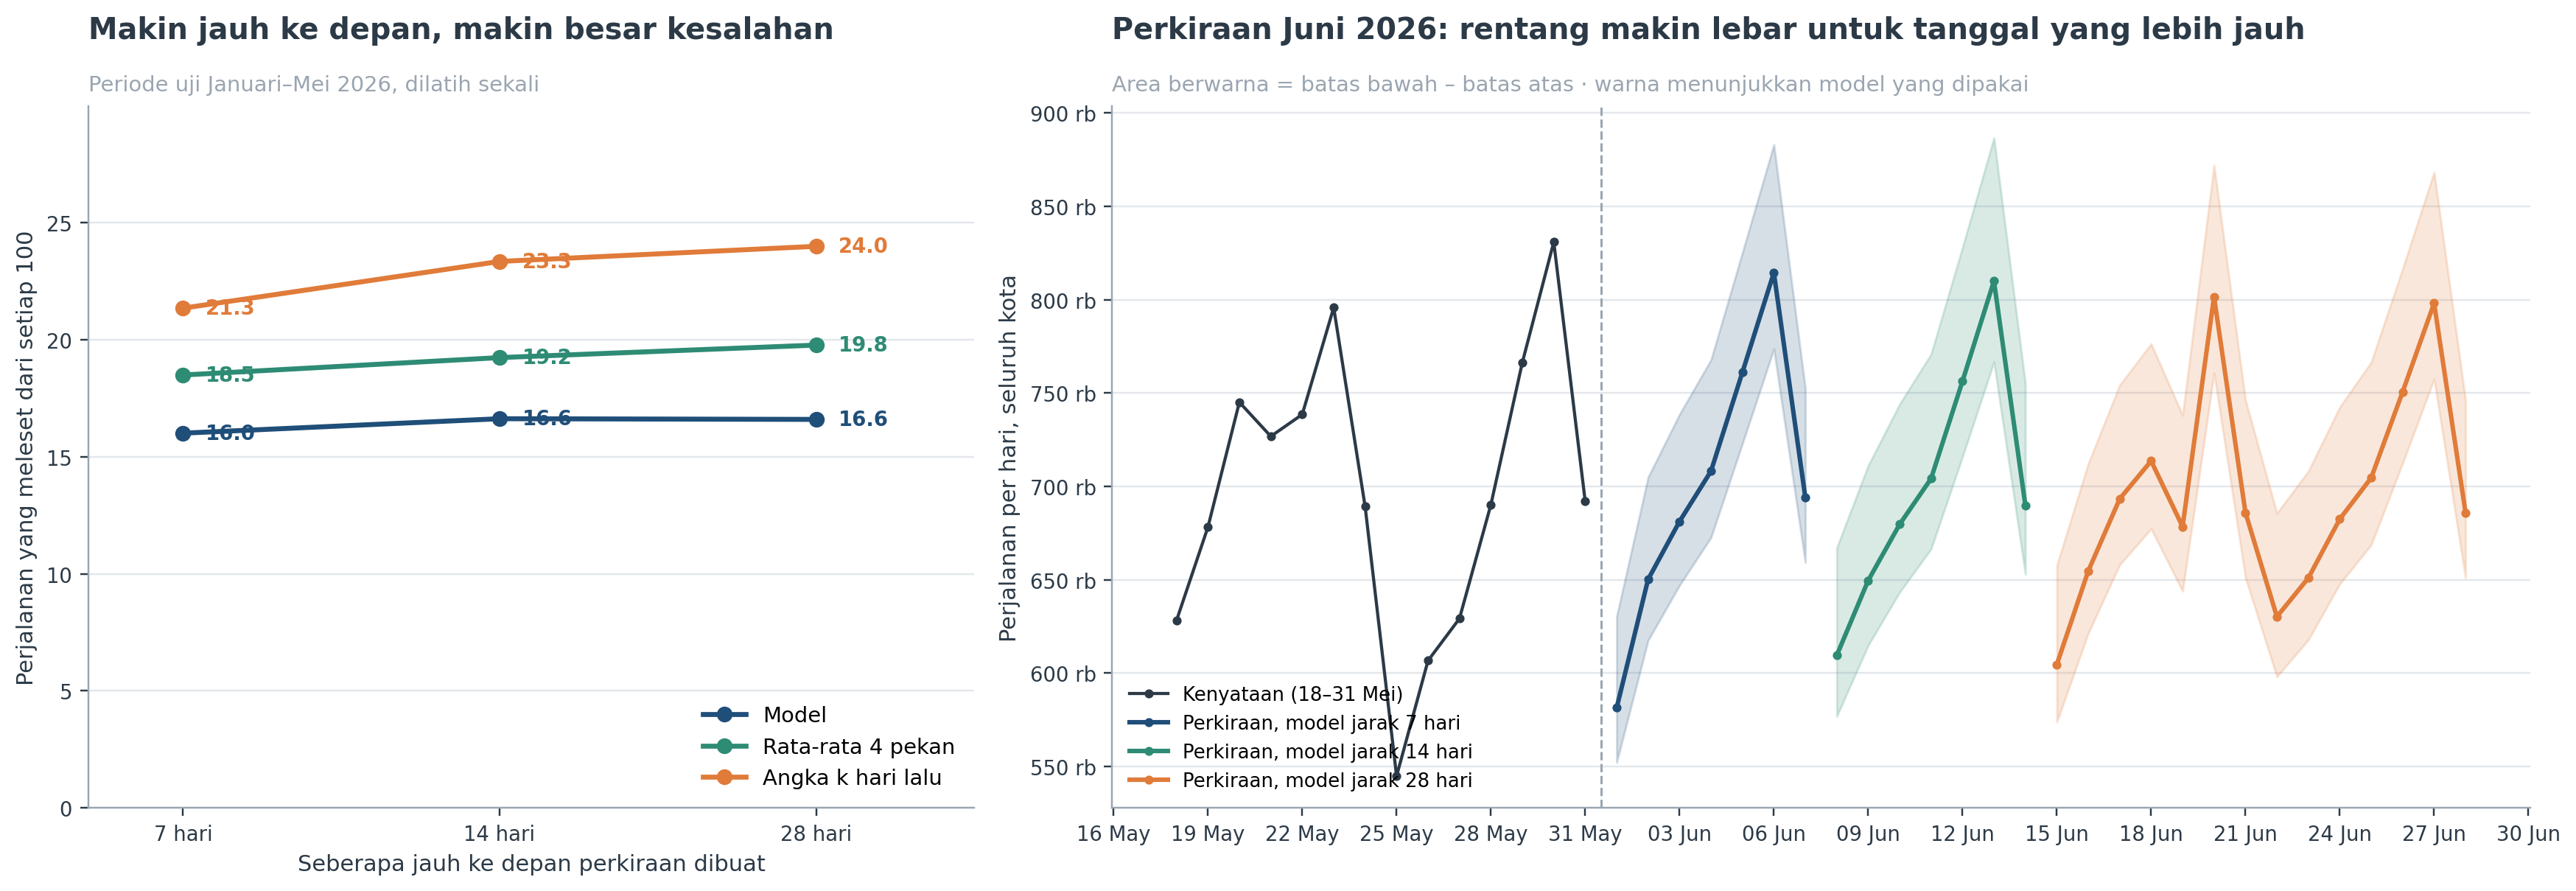

Disimpan: penilaian_per_jarak.csv, perkiraan_kota_juni_per_pekan.csv, perkiraan_kota_juni_per_hari.csv,
          perkiraan_seri_per_jam_14hari.csv, perkiraan_seri_per_jam_28hari.csv


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1, 1.6]})

# ---------- Kiri: kesalahan makin besar seiring jarak ----------
ax = axes[0]
xk = np.arange(len(per_jarak))
for kol, w, lbl in [("Model", C["primary"], "Model"), ("Rata-rata 4 pekan", C["accent"], "Rata-rata 4 pekan"),
                    ("Angka k hari lalu", C["secondary"], "Angka k hari lalu")]:
    ax.plot(xk, per_jarak[kol], color=w, marker="o", linewidth=2.2, label=lbl)
    for i, v in enumerate(per_jarak[kol]):
        ax.annotate(f"{v:.1f}", xy=(i, v), xytext=(10, 0), textcoords="offset points",
                    fontsize=9, color=w, fontweight="semibold", va="center")
ax.set_xticks(xk)
ax.set_xticklabels(["7 hari", "14 hari", "28 hari"])
ax.set_xlim(-0.3, len(xk) - 0.5)
ax.set_ylim(0, per_jarak[["Model", "Rata-rata 4 pekan", "Angka k hari lalu"]].values.max() * 1.25)
ax.set_xlabel("Seberapa jauh ke depan perkiraan dibuat")
ax.set_ylabel("Perjalanan yang meleset dari setiap 100")
ax.legend(loc="lower right")
titled(ax, "Makin jauh ke depan, makin besar kesalahan", "Periode uji Januari–Mei 2026, dilatih sekali")
clean_axes(ax)

# ---------- Kanan: perkiraan Juni per hari, rentang melebar ----------
ax = axes[1]
riwayat = agregat(gab_uji[gab_uji["jam"] >= mulai - pd.Timedelta(days=14)], ["tanggal"])
ax.plot(riwayat.index, riwayat["demand"], color=C["text"], linewidth=1.4, marker="o", markersize=3,
        label="Kenyataan (18–31 Mei)")
warna_model = {"7 hari": C["primary"], "14 hari": C["accent"], "28 hari": C["secondary"]}
for model, d in juni_harian.groupby("model", sort=False):
    ax.fill_between(d["tanggal"], d["batas_bawah"], d["batas_atas"], color=warna_model[model], alpha=0.18)
    ax.plot(d["tanggal"], d["perkiraan"], color=warna_model[model], linewidth=2, marker="o", markersize=3,
            label=f"Perkiraan, model jarak {model}")
ax.axvline(mulai - pd.Timedelta(hours=12), color=C["muted"], linestyle="--", linewidth=1)
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.yaxis.set_major_formatter(RIBU)
ax.set_ylabel("Perjalanan per hari, seluruh kota")
ax.legend(loc="lower left", fontsize=8.5)
titled(ax, "Perkiraan Juni 2026: rentang makin lebar untuk tanggal yang lebih jauh",
       "Area berwarna = batas bawah – batas atas · warna menunjukkan model yang dipakai")
clean_axes(ax)
plt.tight_layout()
plt.show()

# ---------- Simpan ----------
per_jarak.to_csv(FOLDER_MODEL / "penilaian_per_jarak.csv")
juni.to_csv(FOLDER_MODEL / "perkiraan_kota_juni_per_pekan.csv", index=False)
juni_harian.to_csv(FOLDER_MODEL / "perkiraan_kota_juni_per_hari.csv", index=False)
for hari, h in HASIL_JARAK.items():
    h["seri"][["jam", "zona", "provider", "batas_bawah", "perkiraan", "batas_atas"]] \
        .to_csv(FOLDER_MODEL / f"perkiraan_seri_per_jam_{hari}hari.csv", index=False)
print("Disimpan: penilaian_per_jarak.csv, perkiraan_kota_juni_per_pekan.csv, perkiraan_kota_juni_per_hari.csv,")
print("          perkiraan_seri_per_jam_14hari.csv, perkiraan_seri_per_jam_28hari.csv")

> **Cara membaca Pengembangan Lanjutan**

**Tabel per jarak** — kesalahan model dan dua pembanding untuk setiap jarak perkiraan, pada Januari–Mei 2026. Semua model di tabel ini dilatih sekali sampai Desember 2025, sehingga jaraknya dapat dibandingkan secara adil. Kolom cakupan menunjukkan hasil uji bergulir rentang, dengan target 80%.

**Grafik kiri** — bagaimana kesalahan bertambah bila perkiraan dibuat lebih jauh ke depan.

**Tabel dan grafik Juni** — perkiraan seluruh kota untuk empat pekan Juni. Setiap pekan memakai model dengan jarak terpendek yang masih sah. Area berwarna adalah rentang batas bawah sampai batas atas.

> **Hasil Pengembangan Lanjutan**

| Jarak | Model | Rata-rata 4 pekan | Angka k hari lalu | Bias model | Cakupan seri per jam | Cakupan kota per hari |
|---|---|---|---|---|---|---|
| 7 hari | 16,01 | 18,49 | 21,34 | −1,8% | 77,6% | 72,2% |
| 14 hari | 16,62 | 19,23 | 23,34 | −2,1% | 76,9% | 66,2% |
| 28 hari | 16,59 | 19,77 | 23,98 | −2,1% | 76,8% | 71,5% |

**Temuan 1 — Kesalahan hampir tidak bertambah dari 7 ke 28 hari.** Model hanya meleset 0,6 poin lebih banyak pada jarak 28 hari. Pembanding sederhana memburuk lebih cepat: angka k hari lalu naik 2,6 poin. Keunggulan model justru melebar — dari 2,5 poin di 7 hari menjadi 3,2 poin di 28 hari dibanding rata-rata 4 pekan.

**Temuan 2 — Sejalan dengan ACF.** Hubungan dengan 28 hari sebelumnya (0,879) hampir sekuat dengan 7 hari sebelumnya (0,930), sehingga informasi sebulan lalu masih hampir sama bergunanya.

**Temuan 3 — Rentang pada jarak 14 dan 28 hari berperilaku sama dengan jarak 7 hari.** Terlalu sempit di Januari–Februari (kota per hari jarak 14 hari hanya 19,4% di Januari) dan terlalu lebar di April–Mei. Penyebabnya sama: hari-hari anjlok ekstrem yang tidak dapat diperkirakan.

**Temuan 4 — Perkiraan Juni 2026 per pekan stabil di sekitar 4,83–4,90 juta perjalanan.**

| Pekan | Model | Batas bawah | Perkiraan | Batas atas |
|---|---|---|---|---|
| 1–7 Juni | jarak 7 hari | 4.645.346 | 4.890.798 | 5.302.539 |
| 8–14 Juni | jarak 14 hari | 4.637.017 | 4.899.131 | 5.362.976 |
| 15–21 Juni | jarak 28 hari | 4.586.239 | 4.832.294 | 5.256.899 |
| 22–28 Juni | jarak 28 hari | 4.653.461 | 4.903.123 | 5.333.951 |

**Implikasi:** perkiraan per jam untuk empat pekan ke depan layak dipakai untuk jadwal shift dan insentif, bukan hanya untuk penempatan armada pekan depan. Model 14 dan 28 hari memakai iterasi dari model 7 hari; pemilihan tersendiri untuk tiap jarak dapat meningkatkan akurasinya lagi.

> **Rencana pengembangan**

| Pengembangan | Isi | Keputusan yang didukung |
|---|---|---|
| Perkiraan harian per zona | Perkiraan per zona per hari, bukan per jam, untuk jarak 1–3 bulan | Rekrutmen pengemudi dan anggaran |
| Model jarak pendek | Untuk perkiraan besok, fitur boleh memakai data kemarin, sehingga lebih akurat untuk hari-hari awal | Penyesuaian armada harian |
| Data cuaca dan acara | Menambah informasi yang menjelaskan hari anjlok ekstrem | Mengurangi kesalahan terbesar |

Jarak 14 dan 28 hari di atas memakai jenis model dan jumlah iterasi yang sama dengan model 7 hari. Langkah berikutnya adalah memilih model dan iterasi tersendiri untuk setiap jarak, dengan tiga periode validasi seperti Step 7.

---

# STEP 12 — Ringkasan

| Pertanyaan | Jawaban |
|---|---|
| Lag mana yang paling berguna menurut ACF dan PACF? | Lag 7 hari (ACF 0,930), lebih kuat dari 1 jam sebelumnya. Lag 14–28 hari turun sangat pelan (0,906–0,879) |
| Model mana yang terpilih, dan apakah stabil? | LightGBM satu model. Menang di dua dari tiga periode validasi, dan setara dengan "+ tren" secara gabungan sehingga yang lebih sederhana dipilih. Terbukti terbaik juga di periode uji |
| Apakah XGBoost berbeda dari LightGBM? | Tidak berarti: 14,99 vs 14,87 di validasi, 16,11 vs 16,02 di uji, dengan waktu latih hampir dua kali lipat |
| Apakah memisah model membantu? | Tidak. Per provider dan per kelompok seri sedikit lebih buruk dari satu model |
| Apakah model lebih akurat dari pembanding terbaik? | Ya. 15,98 vs 18,49 (−14%), di ketiga kelompok seri, kedua provider, keempat kelompok jam zona, dan di jam sibuk. Tidak pernah kalah di kelompok 1 dan 2; kalah 2 dari 22 pekan di kelompok 3 |
| Berapa manfaat melatih ulang tiap bulan? | Hanya 0,04 poin. Pelatihan ulang per kuartal kemungkinan sudah cukup |
| Apakah sisa kesalahan masih berpola mingguan? | Tidak. Autokorelasi di lag 168 jam turun dari 0,79 menjadi −0,02 |
| Apakah rentang mengapit sekitar 80% kenyataan? | Belum secara gabungan: seri per jam 77,6%, kota per hari 72,2%. Rentang terlalu sempit di bulan berkejadian ekstrem (Januari–Februari) dan terlalu lebar di bulan normal (April–Mei). Seri per jam stabil 80,1–80,6% sejak Maret. Rentang dibaca sebagai kisaran kondisi normal |
| Berapa perkiraan total 1–7 Juni 2026? | 4,89 juta perjalanan (4,65–5,32 juta), 2,8% di atas pekan sebelumnya |
| Seberapa besar kesalahan pada jarak 14 dan 28 hari? | 16,62 dan 16,59 — hanya 0,6 poin lebih besar dari 7 hari, dan tetap mengalahkan pembanding. Perkiraan Juni per pekan 4,83–4,90 juta |

**Kesimpulan terhadap rencana awal project:** tujuan model tercapai. Perkiraan per jam × provider × zona pickup mengalahkan Seasonal Naive dengan selisih 25%, dan mengalahkan pembanding yang lebih ketat (rata-rata 4 pekan) dengan selisih 14%.

**Batas kesimpulan**

| Batas | Konsekuensi |
|---|---|
| Hanya perjalanan yang terlaksana yang tercatat | Perkiraan adalah permintaan terlayani, bukan permintaan sebenarnya |
| Satu periode uji, Januari–Mei 2026 | Kinerja pada musim sepi Juli–Agustus belum teruji |
| Tidak ada data cuaca dan acara | Hari anjlok ekstrem tidak dapat diperkirakan, dan rentang tidak dapat sekaligus tepat untuk bulan normal dan bulan berkejadian ekstrem |
| Parameter model tidak di-tuning | Hasil adalah batas bawah dari yang mungkin dicapai |
| Model 14 dan 28 hari memakai iterasi model 7 hari | Pemilihan tersendiri per jarak dapat meningkatkan akurasi |

---

# CATATAN EKSEKUSI

**Paket:** `pip install duckdb lightgbm xgboost`. Bila XGBoost tidak terpasang, kandidat itu dilewati dan sisanya tetap berjalan.

**Urutan:** jalankan dari atas ke bawah. Bila kernel di-restart setelah Step 4, cukup jalankan setup lalu mulai dari Step 5 — fitur sudah tersimpan di `fitur.parquet`.

**Waktu:** Pengembangan Lanjutan menambah 20–40 menit. Step 7 paling lama karena melatih enam kandidat pada tiga periode validasi, umumnya 30–60 menit. Step 8 melatih ulang model terpilih lima kali (sekali per bulan uji) ditambah setiap kandidat sekali.

**Memori:** data dibaca sebagai angka 4 byte. Bila memori tidak cukup, ubah `LATIH_MULAI` menjadi `"2024-06-01 00:00:00"` lalu jalankan ulang dari Step 4.